In [2]:
import torch
import pandas as pd
import numpy as np
#import random
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import KFold,StratifiedKFold 
import gc
import os
from os import path
from sys import path as systemPath
systemPath.append(path.join('..', '..'))
from scipy.spatial import distance_matrix
#import argparse
import random
import matplotlib.pyplot as plt
import networkx as nx
import MDAnalysis as mda
from matplotlib.ticker import MaxNLocator,MultipleLocator
from MDAnalysis.core.groups import AtomGroup
import seaborn as sns
import statistics as st
from scipy.stats import gaussian_kde

## dataset

In [3]:
# real position index
mutation_pos = [29, 29, 35, 35, 35, 41, 41, 50, 59, 62, 77, 86, 89, 92, 92, 95, 101, 101, 104, 107, 107, 110, 113, 113, 119, 119, 122, 122, 137, 137, 143, 143, 149, 149, 152, 161, 164, 164, 170, 170, 176, 176, 188, 191, 191, 194, 203, 203, 206, 209, 215, 218, 218, 221, 221, 227, 227, 227, 230, 233, 236, 236, 236, 239, 239, 242, 242, 245, 245, 248, 251, 260, 260, 263, 266, 269, 272, 293, 299, 302, 302, 314, 320, 329, 341, 365, 365, 368, 368, 371, 371, 392, 398, 398, 398, 404, 407, 425, 425, 431, 431, 431, 455, 464, 464, 467, 473, 476, 488, 494, 497, 524, 527, 539, 539, 542, 542, 557, 557, 566, 575, 575, 581, 581, 593, 596, 602, 605, 608, 611, 614, 617, 626, 626, 647, 653, 653, 659, 659, 662, 671, 674, 677, 680, 680, 683, 689, 692, 695, 698, 704, 704, 707, 713, 716, 725, 734, 755, 764, 782, 785, 788, 800, 812, 818, 839, 848, 860, 860, 860, 863, 866, 878, 884, 884, 887, 890, 896, 899, 899, 902, 914, 914, 917, 920, 923, 926, 929, 938, 944, 962, 980, 983, 983, 989, 989, 992, 1004, 1007, 1007, 1010, 1013, 1013, 1016, 1019, 1022, 1025, 116, 1028, 125, 131, 158, 164, 32, 32, 32, 179, 182, 191, 200, 35, 206, 206, 212, 218, 227, 38, 242, 41, 275, 275, 293, 308, 308, 329, 347, 50, 365, 374, 53, 386, 407, 410, 56, 416, 419, 431, 440, 443, 59, 59, 59, 452, 470, 473, 485, 506, 521, 524, 551, 560, 569, 572, 578, 581, 587, 596, 599, 602, 608, 662, 662, 665, 671, 671, 677, 686, 689, 692, 692, 701, 704, 86, 716, 719, 722, 734, 770, 812, 812, 815, 854, 101, 878, 893, 917, 932, 947, 971, 113, 995, 1091, 1097, 1103, 1106, 1139, 1163, 1166, 1166, 1175, 1175, 1184, 1190, 1220, 1226, 1229, 1229, 1238, 1247, 1247, 1253, 1259, 1259, 1262, 1262, 1268, 1271, 1280, 1283, 1289, 1295, 1298, 1301, 1301, 1301, 1304, 1304, 1307, 1310, 1310, 1310, 1310, 1313, 1313, 1319, 1319, 1322, 1322, 1331, 1331, 1337, 1340, 1343, 1343, 1349, 1349, 1358, 1361, 1364, 1364, 1379, 1382, 1391, 1391, 1397, 1400, 1406, 1418, 1421, 1427, 1433, 1442, 1451, 1451, 1457, 1457, 1463, 1466, 1472, 1481, 1484, 1484, 1484, 1490, 1493, 1499, 1499, 1502, 1505, 1514, 1517, 1517, 1520, 1526, 1535, 1559, 1565, 1568, 1568, 1571, 1574, 1574, 1589, 1601, 1607, 1610, 1613, 1619, 1634, 1634, 1637, 1643, 1649, 1649, 1649, 1655, 1673, 1673, 1685, 1685, 1688, 1691, 1694, 1703, 1709, 1712, 1718, 1724, 1730, 1736, 1739, 1739, 1742, 1745, 1751, 1757, 1757, 1760, 1763, 1766, 1769, 1769, 1778, 1802, 1808, 1820, 1826, 1832, 1850, 1853, 1865, 1868, 1874, 1877, 1889, 1910, 1919, 1922, 1928, 1928, 1943, 1946, 1946, 1955, 1961, 1970, 1979, 1985, 1988, 2000, 2000, 2009, 2012, 2015, 2024, 2030, 2039, 2051, 2054, 2057, 2063, 2069, 2072, 2075, 2075, 2075, 2075, 1163, 2063, 2063, 2066, 1166, 1169, 1172, 1172, 1172, 1184, 1190, 1220, 1232, 1238, 1241, 1241, 1244, 1250, 1256, 1262, 1262, 1277, 1277, 1085, 1286, 1289, 1292, 1310, 1088, 1313, 1325, 1328, 1358, 1370, 1094, 1373, 1415, 1424, 1427, 1100, 1454, 1490, 1523, 1535, 1538, 1541, 1544, 1112, 1598, 1607, 1619, 1634, 1634, 1646, 1673, 1682, 1688, 1706, 1712, 1718, 1721, 1727, 1733, 1736, 1742, 1745, 1760, 1763, 1769, 1775, 1775, 1778, 1784, 1787, 1790, 1793, 1796, 1814, 1820, 1826, 1829, 1847, 1142, 1853, 1907, 1916, 1916, 1928, 1934, 1955, 1955, 1958, 1958, 1964, 1967, 1976, 1997, 2003, 2018, 2057]
# mutation type
mutation_name = ["ALA" , "ASP", "CYS", "SER", "ASP", "ARG", "VAL", "ARG", "CYS", "CYS", "ASP", "ARG", "CYS", "ARG", "GLU", "ARG", "ARG", "VAL", "GLU", "SER", "VAL", "CYS", "ARG", "ASP", "SER", "ASP", "SER", "ALA", "ARG", "ASP", "SER", "ARG", "ARG", "ASP", "ARG", "GLU", "ARG", "ASP", "ARG", "ALA", "CYS", "SER", "ARG", "CYS", "SER", "CYS", "VAL", "ALA", "SER", "SER", "ALA", "CYS", "VAL", "CYS", "SER", "ARG", "CYS", "SER", "GLU", "SER", "CYS", "ALA", "ASP", "CYS", "ASP", "CYS", "SER", "SER", "CYS", "SER", "ALA", "CYS", "ALA", "SER", "CYS", "VAL", "VAL", "CYS", "SER", "ARG", "GLU", "ARG", "ALA", "CYS", "CYS", "CYS", "ALA", "CYS", "SER", "CYS", "ASP", "ALA", "ARG", "SER", "CYS", "ARG", "ARG", "SER", "ALA", "CYS", "SER", "ASP", "ARG", "CYS", "SER", "SER", "ARG", "VAL", "ARG", "SER", "ALA", "VAL", "SER", "CYS", "SER", "CYS", "SER", "SER", "ASP", "ARG", "CYS", "ASP", "SER", "VAL", "SER", "CYS", "VAL", "SER", "CYS", "SER", "SER", "SER", "CYS", "SER", "SER", "VAL", "ALA", "SER", "ARG", "CYS", "ALA", "ALA", "SER", "ARG", "ASP", "ARG", "ASP", "SER", "CYS", "ALA", "CYS", "SER", "CYS", "SER", "SER", "SER", "CYS", "GLU", "CYS", "CYS", "CYS", "ARG", "ASP", "ARG", "VAL", "CYS", "SER", "SER", "ALA", "VAL", "ARG", "SER", "SER", "SER", "CYS", "SER", "SER", "SER", "SER", "ASP", "ALA", "SER", "CYS", "SER", "CYS", "SER", "ALA", "SER", "ASP", "ALA", "CYS", "SER", "CYS", "ASP", "SER", "VAL", "ARG", "CYS", "SER", "CYS", "ASP", "CYS", "SER", "VAL", "SER", "VAL", "VAL", "GLU", "ASP", "SER", "VAL", "VAL", "SER", "ARG", "SER", "ALA", "CYS", "ASP", "ASP", "SER", "ARG", "VAL", "ASP", "ALA", "SER", "ALA", "VAL", "ALA", "SER", "CYS", "ASP", "ASP", "VAL", "ALA", "SER", "VAL", "GLU", "ASP", "ARG", "ARG", "ALA", "ASP", "ARG", "ASP", "SER", "ARG", "VAL", "ARG", "ASP", "ARG", "ASP", "SER", "ARG", "SER", "SER", "SER", "SER", "SER", "ALA", "SER", "SER", "VAL", "VAL", "ARG", "ASP", "SER", "SER", "ASP", "SER", "SER", "ARG", "ALA", "ASP", "ASP", "VAL", "ASP", "ARG", "VAL", "ARG", "VAL", "VAL", "ALA", "GLU", "ASP", "VAL", "SER", "ASP", "ASP", "ASP", "ALA", "ASP", "ARG", "GLU", "ARG", "ASP", "ARG", "SER", "SER", "ALA", "SER", "ASP", "ASP", "ASP", "ASP", "SER", "VAL", "VAL", "SER", "ASP", "ARG", "ASP", "ASP", "VAL", "ASP", "ASP", "ASP", "VAL", "ASP", "ASP", "VAL", "SER", "ALA", "VAL", "ALA", "VAL", "VAL", "ARG", "ASP", "ARG", "ARG", "SER", "GLU", "SER", "CYS", "ASP", "ASP", "VAL", "SER", "CYS", "SER", "ARG", "PRO", "ARG", "SER", "CYS", "SER", "SER", "CYS", "CYS", "SER", "SER", "TRP", "SER", "ALA", "ASP", "VAL", "GLU", "VAL", "CYS", "SER", "SER", "VAL", "SER", "ASP", "SER", "SER", "GLU", "ARG", "GLU", "CYS", "SER", "ALA", "ASP", "VAL", "VAL", "GLU", "GLU", "GLU", "VAL", "ASP", "SER", "ASP", "VAL", "ARG", "SER", "ARG", "GLU", "CYS", "GLU", "CYS", "SER", "VAL", "ARG", "ASP", "CYS", "ARG", "SER", "CYS", "SER", "VAL", "SER", "ASP", "SER", "ARG", "VAL", "ASP", "GLU", "VAL", "SER", "VAL", "ASP", "ASP", "ARG", "VAL", "ASP", "ASP", "CYS", "ASP", "SER", "ASP", "ASP", "SER", "SER", "CYS", "CYS", "ARG", "GLU", "SER", "VAL", "VAL", "SER", "VAL", "VAL", "SER", "SER", "ARG", "SER", "CYS", "ASP", "ARG", "SER", "ALA", "CYS", "SER", "SER", "ARG", "VAL", "SER", "CYS", "SER", "ASP", "ASP", "SER", "ARG", "ARG", "CYS", "ARG", "SER", "SER", "CYS", "ASP", "VAL", "ASP", "VAL", "VAL", "ASP", "SER", "SER", "ARG", "ARG", "GLU", "ARG", "ASP", "SER", "SER", "CYS", "ASP", "ASP", "VAL", "VAL", "CYS", "ALA", "ARG", "ARG", "SER", "ASP", "VAL", "GLU", "ASP", "VAL", "ASP", "ARG", "ASP", "ASP", "VAL", "CYS", "VAL", "GLU", "ARG", "SER", "ARG", "ARG", "GLU", "ARG", "ARG", "ARG", "ASP", "SER", "CYS", "SER", "VAL", "CYS", "SER", "ARG", "ASP", "ARG", "ASP", "ASP", "GLU", "ARG", "GLU", "ASP", "ARG", "ARG", "SER", "ALA", "ASP", "SER", "ASP", "SER", "VAL", "SER", "ASP", "ARG", "VAL", "ASP", "ASP", "CYS", "ASP", "CYS", "ASP", "ARG", "VAL", "SER", "CYS", "GLU", "ARG", "VAL", "CYS", "GLU", "ASP", "CYS", "VAL", "ASP", "ALA", "CYS", "SER", "VAL", "ARG", "ALA", "GLU", "VAL", "SER", "CYS", "SER", "SER", "ASP", "VAL", "ASP", "GLU", "ASP", "ASP", "GLU", "ARG", "ASP", "ASP", "ASP", "SER", "ARG", "SER", "VAL", "ASP", "ASP", "ARG", "ASP", "ASP", "CYS"]
# lethal:0, non-lethal:1 
lethal = [ 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1]  
# triple number 
triplet_number = [5, 5, 7, 7, 7, 9, 9, 12, 15, 16, 21, 24, 25, 26, 26, 27, 29, 29, 30, 31, 31, 32, 33, 33, 35, 35, 36, 36, 41, 41, 43, 43, 45, 45, 46, 49, 50, 50, 52, 52, 54, 54, 58, 59, 59, 60, 63, 63, 64, 65, 67, 68, 68, 69, 69, 71, 71, 71, 72, 73, 74, 74, 74, 75, 75, 76, 76, 77, 77, 78, 79, 82, 82, 83, 84, 85, 86, 93, 95, 96, 96, 100, 102, 105, 109, 117, 117, 118, 118, 119, 119, 126, 128, 128, 128, 130, 131, 137, 137, 139, 139, 139, 147, 150, 150, 151, 153, 154, 158, 160, 161, 170, 171, 175, 175, 176, 176, 181, 181, 184, 187, 187, 189, 189, 193, 194, 196, 197, 198, 199, 200, 201, 204, 204, 211, 213, 213, 215, 215, 216, 219, 220, 221, 222, 222, 223, 225, 226, 227, 228, 230, 230, 231, 233, 234, 237, 240, 247, 250, 256, 257, 258, 262, 266, 268, 275, 278, 282, 282, 282, 283, 284, 288, 290, 290, 291, 292, 294, 295, 295, 296, 300, 300, 301, 302, 303, 304, 305, 308, 310, 316, 322, 323, 323, 325, 325, 326, 330, 331, 331, 332, 333, 333, 334, 335, 336, 337, 34, 338, 37, 39, 48, 50, 6, 6, 6, 55, 56, 59, 62, 7, 64, 64, 66, 68, 71, 8, 76, 9, 87, 87, 93, 98, 98, 105, 111, 12, 117, 120, 13, 124, 131, 132, 14, 134, 135, 139, 142, 143, 15, 15, 15, 146, 152, 153, 157, 164, 169, 170, 179, 182, 185, 186, 188, 189, 191, 194, 195, 196, 198, 216, 216, 217, 219, 219, 221, 224, 225, 226, 226, 229, 230, 24, 234, 235, 236, 240, 252, 266, 266, 267, 280, 29, 288, 293, 301, 306, 311, 319, 33, 327, 10, 12, 14, 15, 26, 34, 35, 35, 38, 38, 41, 43, 53, 55, 56, 56, 59, 62, 62, 64, 66, 66, 67, 67, 69, 70, 73, 74, 76, 78, 79, 80, 80, 80, 81, 81, 82, 83, 83, 83, 83, 84, 84, 86, 86, 87, 87, 90, 90, 92, 93, 94, 94, 96, 96, 99, 100, 101, 101, 106, 107, 110, 110, 112, 113, 115, 119, 120, 122, 124, 127, 130, 130, 132, 132, 134, 135, 137, 140, 141, 141, 141, 143, 144, 146, 146, 147, 148, 151, 152, 152, 153, 155, 158, 166, 168, 169, 169, 170, 171, 171, 176, 180, 182, 183, 184, 186, 191, 191, 192, 194, 196, 196, 196, 198, 204, 204, 208, 208, 209, 210, 211, 214, 216, 217, 219, 221, 223, 225, 226, 226, 227, 228, 230, 232, 232, 233, 234, 235, 236, 236, 239, 247, 249, 253, 255, 257, 263, 264, 268, 269, 271, 272, 276, 283, 286, 287, 289, 289, 294, 295, 295, 298, 300, 303, 306, 308, 309, 313, 313, 316, 317, 318, 321, 323, 326, 330, 331, 332, 334, 336, 337, 338, 338, 338, 338, 34, 334, 334, 335, 35, 36, 37, 37, 37, 41, 43, 53, 57, 59, 60, 60, 61, 63, 65, 67, 67, 72, 72, 8, 75, 76, 77, 83, 9, 84, 88, 89, 99, 103, 11, 104, 118, 121, 122, 13, 131, 143, 154, 158, 159, 160, 161, 17, 179, 182, 186, 191, 191, 195, 204, 207, 209, 215, 217, 219, 220, 222, 224, 225, 227, 228, 233, 234, 236, 238, 238, 239, 241, 242, 243, 244, 245, 251, 253, 255, 256, 262, 27, 264, 282, 285, 285, 289, 291, 298, 298, 299, 299, 301, 302, 305, 312, 314, 319, 332]
# chain 
alpha12 = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

In [4]:
"amino acids clusters"
PRO = ["PRO","HYP"]
Small = ["GLY","ALA","CYS","SER","THR"]
Charged = ["HIS","HSE", "LYS", "ARG", "GLU","ASP"]
Hydrophobic = ["VAL", "ILE", "LEU", "MET", "PHE", "TYR" , "TRP"]
Polar = ["ASN" , "GLN"]
# severe = ["VAL","AS"]
# moderate = ["GLU","CYS","ARG"]
# mild = ["PRO","TRP","ALA","SER"]

In [2]:
##不用跑
np.save(f'D:/collagen/data/mutation_name.npy', np.array(mutation_name, dtype='U10'))
np.save(f'D:/collagen/data/lethal.npy',        np.array(lethal,        dtype=int))
np.save(f'D:/collagen/data/triplet_number.npy',np.array(triplet_number,dtype=int))
np.save(f'D:/collagen/data/alpha12.npy',       np.array(alpha12,       dtype=int))
np.save(f'D:/collagen/data/mutation_pos.npy',  np.array(mutation_pos,  dtype=int))

NameError: name 'np' is not defined

### load

In [5]:
##儲存資料
radius_all=np.load(f'D:/collagen/new_uh_rad/traj_radius_all.npy', allow_pickle = True)
radius_wt=np.load(f'D:/collagen/new_uh_rad/traj_radius_wt.npy', allow_pickle = True)
unit_hei_all=np.load(f'D:/collagen/new_uh_rad/traj_unit_hei.npy', allow_pickle = True)
unit_hei_wt=np.load(f'D:/collagen/new_uh_rad/traj_unit_hei_wt.npy', allow_pickle = True)

gpo_radius_traj = np.load(f'D:/collagen/gpo30/ana/gpo_traj_radius.npy', allow_pickle = True)
gpo_unit_hei_traj = np.load(f'D:/collagen/gpo30/ana/gpo_traj_unhei.npy', allow_pickle = True)

mutation_name_arr = np.load(f'D:/collagen/data/mutation_name.npy')  # (587,)
lethal_arr = np.load(f'D:/collagen/data/lethal.npy')  # (587,)
alpha12_arr = np.load(f'D:/collagen/data/alpha12.npy')  # (587,)
triplet_number_arr = np.load(f'D:/collagen/data/triplet_number.npy')  # (587,)

In [6]:
print(radius_all.shape)
print(radius_wt.shape)
print(unit_hei_all.shape)
print(unit_hei_wt.shape)

(587, 100, 9)
(587, 100, 9)
(587, 100, 9)
(587, 100, 9)


## average

In [7]:
##平均與標準差
def calc_avg_std(arr):
    """
    對 3-D 陣列 arr 取 avg、std。
    回傳 shape = (arr.shape[0], arr.shape[2]) 的兩個 np.array
    """
    avg_out, std_out = [], []

    for i in range(arr.shape[0]):          # 對「第一軸」逐 slice
        avg_row, std_row = [], []
        for j in range(arr.shape[2]):      # 對「第三軸」逐 column
            vals = arr[i, :, j]            # 相當於原本的 arr[i,:,j]
            avg_row.append(st.mean(vals))
            std_row.append(st.stdev(vals)) # sample σ（與 st.dev 同義）
        avg_out.append(avg_row)
        std_out.append(std_row)

    return np.array(avg_out), np.array(std_out)
radius_avg,     radius_std     = calc_avg_std(radius_all)
radius_wt_avg,  radius_wt_std  = calc_avg_std(radius_wt)
unit_hei_avg,   unit_hei_std   = calc_avg_std(unit_hei_all)
unit_wt_avg,    unit_wt_std    = calc_avg_std(unit_hei_wt)


In [62]:
radius_diff = radius_avg - radius_wt_avg       # shape = (587, 9)
unit_hei_diff = unit_hei_avg - unit_wt_avg     # shape = (587, 9)
print("第 0 筆半徑差值:", radius_diff[0])
print("第 0 筆單位長差值:", unit_hei_diff[0])

第 0 筆半徑差值: [ 0.94760077 -0.8927775  -0.89834449  1.55449188  0.54795596 -0.33011917
 -0.32846944 -1.10051379  0.46569882]
第 0 筆單位長差值: [ 0.1765086  -0.4058806  -0.37280148 -0.7357561   0.11788543 -0.05440131
 -0.11239653 -0.20651063  0.26751177]


## check

In [63]:
import numpy as np
import pandas as pd

# ── 1️⃣  找到那筆突變的索引 idx  ──────────────────────────────
# 範例：triplet=35、mutation='CYS'、α1
mask = (
    (triplet_number_arr == 5) &
    (mutation_name_arr.astype(str) == "ALA") &
    (alpha12_arr == 1)
)
idx = np.where(mask)[0][0]         # <<--- 想看哪筆就改條件；若已知編號直接 idx = 123

# ── 2️⃣  取出該突變 100×9 的資料塊 (Mut 及 WT) ────────────────
uh_mut = unit_hei_all[idx]         # (100, 9)  mutant
uh_wt  = unit_hei_wt[idx]          # (100, 9)  wild-type (同 triplet)

rad_mut = radius_all[idx]          # (100, 9)
rad_wt  = radius_wt[idx]           # (100, 9)


# ── 3️⃣  各位置取 100 frame 平均 ────────────────────────────
uhM_avg = uh_mut.mean(axis=0);   uhW_avg = uh_wt.mean(axis=0)
radM_avg = rad_mut.mean(axis=0); radW_avg = rad_wt.mean(axis=0)

# ── 4️⃣  組成 DataFrame → 漂亮輸出 / 可存 CSV ───────────────
pos_labels = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]

df = pd.DataFrame({
    "Position"      : pos_labels,
    "UH_WT_avg  (Å)"    : np.round(uhW_avg, 3),
    "UH_WT_std  (Å)"    : np.round(unit_wt_std[idx], 3),
    "UH_Mut_avg (Å)"    : np.round(uhM_avg, 3),
    "UH_Mut_std (Å)"    : np.round(unit_hei_std[idx], 3),

    # "ΔUH (Mut-WT)"  : np.round(uhM_avg - uhW_avg, 3),
    # "Rad_Mut (Å)"   : np.round(radM_avg, 3),
    # "Rad_WT  (Å)"   : np.round(radW_avg, 3),
    # "ΔRad (Mut-WT)" : np.round(radM_avg - radW_avg, 3),
})

print(f"\nTriplet {triplet_number_arr[idx]}, "
      f"{mutation_name_arr[idx]} (α{alpha12_arr[idx]})  "
      f"{'Lethal' if lethal_arr[idx]==0 else 'Non-lethal'}")
print(df.to_string(index=False))

# 若要輸出成 CSV 檔：
# df.to_csv(f"{triplet_number_arr[idx]}_{mutation_name_arr[idx]}_compare.csv",
#           index=False)



Triplet 5, ALA (α1)  Non-lethal
Position  UH_WT_avg  (Å)  UH_WT_std  (Å)  UH_Mut_avg (Å)  UH_Mut_std (Å)
     P12           8.488           0.161           8.664           0.257
      P9           8.202           0.228           7.796           0.284
      P6           8.031           0.272           7.658           0.268
      P3           9.327           0.149           8.592           0.252
      M0           9.061           0.310           9.179           0.234
     P3′           9.376           0.258           9.322           0.214
     P6′           9.184           0.211           9.072           0.163
     P9′           9.271           0.227           9.065           0.181
    P12′           8.486           0.376           8.754           0.273


## rad_CYS ana

### L/N -MUT/WT

In [8]:
%matplotlib inline

#### KDE

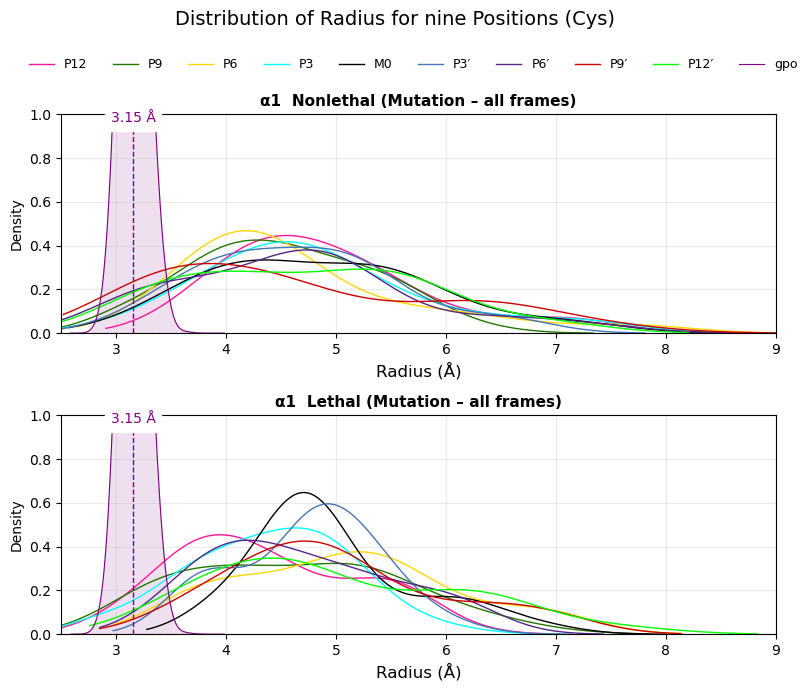

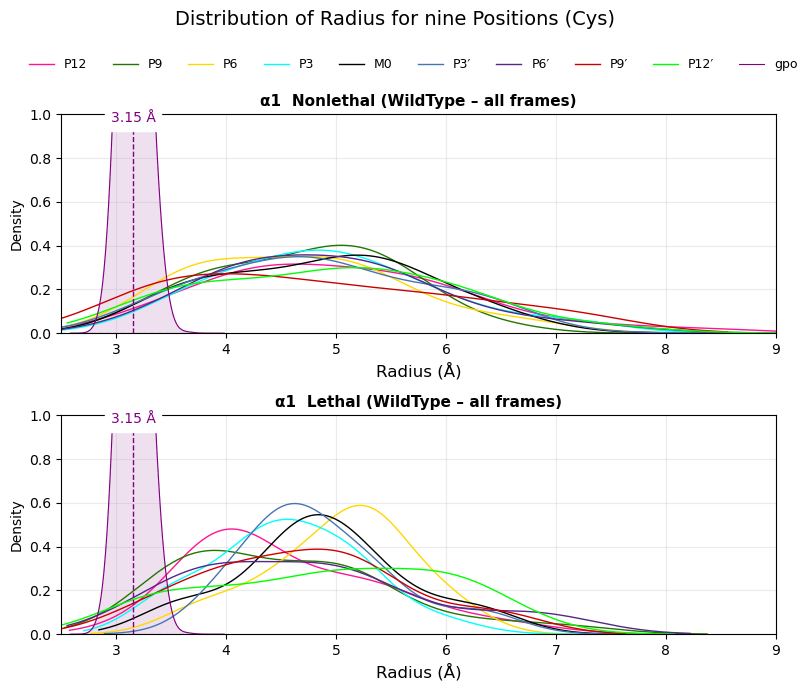

In [10]:
# 你原本的全域參考：triplet 2–9 的 gpo KDE 來源
combined_vals = gpo_radius_traj[:, 1:].ravel()

def plot_kde_4groups(data_all, meta, title_prefix, t_tittle,
                     pos_labels=None, colors=None, bw_pos=0.45, bw_gpo=0.7):
    """
    data_all:
        - (N, 9)  例如 radius_avg
        - 或 (587, 100, 9) 例如 radius_all，會自動攤平成 (587*100, 9)
    meta: dict，且長度需與 data_all 第一維對齊（若輸入 3D，內部會自動 repeat）
        keys: 'mutation_name_arr', 'lethal_arr', 'alpha12_arr'
    title_prefix: e.g. "Unit Height" 或 "Radius"
    t_tittle: 子標題右半邊（例如 "Mutation" 或 "WildType"）
    只畫 Cys，並拆 α1/α2 × lethal/non-lethal 四組 KDE（這裡示範只畫 α1 的兩組）。
    """

    if pos_labels is None:
        pos_labels = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]
    if colors is None:
        colors = ["#ff1493", "#227700", "#ffd700", "#00ffff",
                  "#000000", "#4575b4", "#542788", "#cc0000", "#00ff00"]

    # ------ 0) 形狀處理：支援 (N,9) 與 (587,100,9) ------
    # 同步擴增 meta（repeat 每個突變 100 次，與攤平後資料對齊）
    if data_all.ndim == 3:
        n_mut, n_frames, n_pos = data_all.shape
        assert n_pos == 9, f"預期最後一維是 9，拿到 {n_pos}"
        data_2d = data_all.reshape(n_mut * n_frames, n_pos)

        mut  = np.repeat(meta["mutation_name_arr"].astype(str), n_frames)
        leth = np.repeat(meta["lethal_arr"], n_frames)
        a12  = np.repeat(meta["alpha12_arr"], n_frames)
    else:
        data_2d = data_all
        mut  = meta["mutation_name_arr"].astype(str)
        leth = meta["lethal_arr"]
        a12  = meta["alpha12_arr"]

    # ------ 1) 只取 Cys ------
    is_cys   = (mut == "CYS")
    data_cys = data_2d[is_cys]
    a12_cys  = a12[is_cys]
    leth_cys = leth[is_cys]

    # ------ 2) 四組遮罩（這裡只開 α1 的 lethal / nonlethal）------
    mask = {
        "a1_nonlethal":  (a12_cys == 1) & (leth_cys == 1),
        "a1_lethal":     (a12_cys == 1) & (leth_cys == 0),
        # 若要畫 α2，取消下面兩行註解，並把後面 titles / datasets 一起補齊
        # "a2_nonlethal":  (a12_cys == 2) & (leth_cys == 1),
        # "a2_lethal":     (a12_cys == 2) & (leth_cys == 0),
    }
    titles = [
        f"α1  Nonlethal ({t_tittle})",
        f"α1  Lethal ({t_tittle})",
    ]

    # ------ 3) 整理 datasets → list(子圖) × list(9個位置的樣本一維陣列) ------
    datasets = []
    for key in ["a1_nonlethal", "a1_lethal"]:
        sel = data_cys[mask[key]]               # (n_samples, 9)
        per_pos = [sel[:, i] for i in range(9)] # 長度 9 的 list，每個元素是一個一維樣本陣列
        datasets.append(per_pos)

    # ------ 4) 畫圖 ------
    fig, axes = plt.subplots(2, 1, figsize=(8, 7))
    axes = axes.ravel()

    for ax, data9, sub_title in zip(axes, datasets, titles):
        # 逐個位置畫 KDE
        for i, samples in enumerate(data9):
            if samples.size == 0:
                continue
            kde = gaussian_kde(samples, bw_pos)
            xs  = np.linspace(samples.min()*0.9, samples.max()*1.1, 300)
            ys  = kde(xs)
            ax.plot(xs, ys, color=colors[i], linewidth=1.0, label=pos_labels[i])

        # 疊上 gpo 的 combined KDE（triplet 2–9）
        if 'combined_vals' in globals() and combined_vals.size > 0:
            kde_c = gaussian_kde(combined_vals, bw_method=bw_gpo)
            xs_c  = np.linspace(combined_vals.min()*0.9,
                                combined_vals.max()*1.1, 300)
            ys_c  = kde_c(xs_c)
            ax.plot(xs_c, ys_c, color="purple", lw=0.8, label="gpo")
            ax.fill_between(xs_c, ys_c, linestyle='--', color="purple", alpha=0.12)

            # 標記峰值位置
            peak_x = xs_c[np.argmax(ys_c)]
            ax.axvline(peak_x, color="purple", linestyle="--", linewidth=1)
            ax.text(peak_x, 0.95,
                    f"{peak_x:.2f} Å",
                    color="purple", ha="center", va="bottom",
                    fontsize=10, backgroundcolor="white")

        ax.set_title(sub_title, fontsize=11, fontweight='bold')
        ax.set_xlabel(f"{title_prefix} (Å)", fontsize=12)
        ax.set_ylabel("Density")
        ax.grid(True, alpha=.25)
        ax.set_ylim(0, 1)
        ax.set_xlim(2.5, 9)

    # 圖例與總標題
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, ncol=10, loc=(0.03, 0.89),
                   frameon=False, fontsize=9)

    fig.suptitle(f"Distribution of {title_prefix} for nine Positions (Cys)",
                 fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

meta = {
    "mutation_name_arr": mutation_name_arr,  # 長度 587
    "lethal_arr":        lethal_arr,         # 長度 587
    "alpha12_arr":       alpha12_arr,        # 長度 587
}

# 原本的平均圖
# plot_kde_4groups(radius_avg, meta, "Radius", "Mutation")
# plot_kde_4groups(radius_wt_avg, meta, "Radius", "Mutation")
# 使用所有時間步（(587,100,9) → (58700,9)）
plot_kde_4groups(radius_all, meta, "Radius", "Mutation – all frames")
plot_kde_4groups(radius_wt, meta, "Radius", "WildType – all frames")



#### CDF

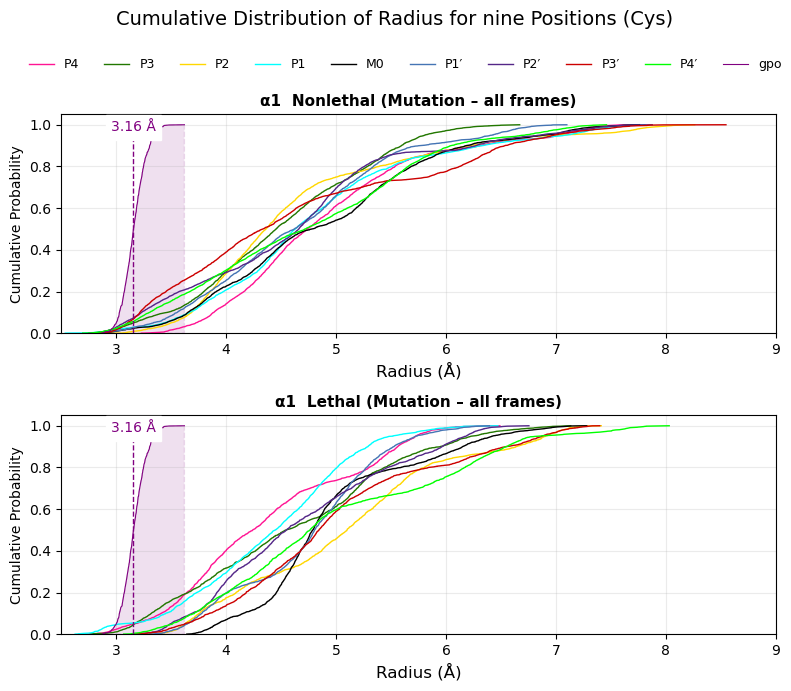

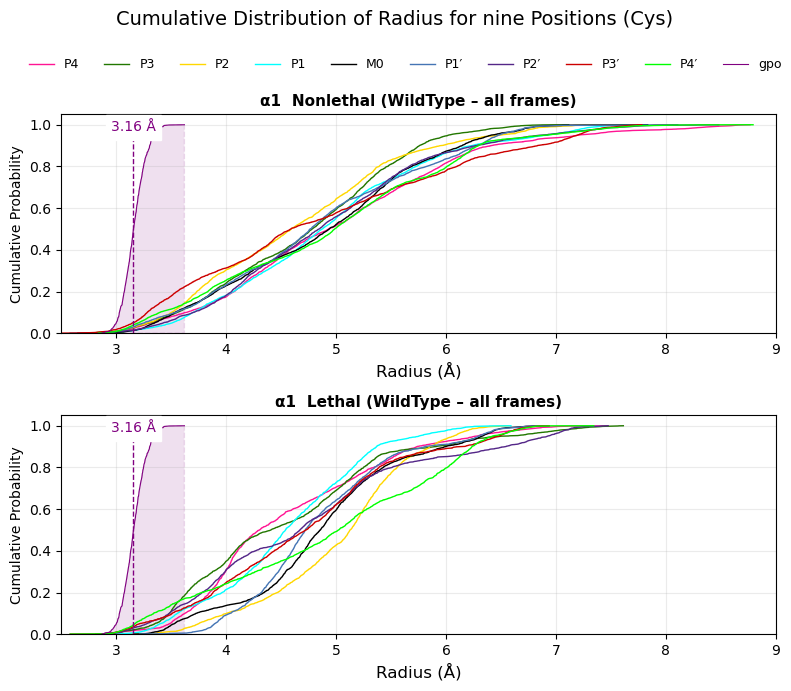

In [47]:
# 你原本的全域參考：triplet 2–9 的 gpo KDE 來源
combined_vals = gpo_radius_traj[:, 1:].ravel()

def plot_kde_4groups(data_all, meta, title_prefix, t_tittle,
                     pos_labels=None, colors=None, bw_pos=0.45, bw_gpo=0.7):
    """
    data_all:
        - (N, 9)  例如 radius_avg
        - 或 (587, 100, 9) 例如 radius_all，會自動攤平成 (587*100, 9)
    meta: dict，且長度需與 data_all 第一維對齊（若輸入 3D，內部會自動 repeat）
        keys: 'mutation_name_arr', 'lethal_arr', 'alpha12_arr'
    title_prefix: e.g. "Unit Height" 或 "Radius"
    t_tittle: 子標題右半邊（例如 "Mutation" 或 "WildType"）
    只畫 Cys，並拆 α1/α2 × lethal/non-lethal 四組 KDE（這裡示範只畫 α1 的兩組）。
    """

    if pos_labels is None:
        pos_labels = ["P4","P3","P2","P1","M0","P1′","P2′","P3′","P4′"]
    if colors is None:
        colors = ["#ff1493", "#227700", "#ffd700", "#00ffff",
                  "#000000", "#4575b4", "#542788", "#cc0000", "#00ff00"]

    # ------ 0) 形狀處理：支援 (N,9) 與 (587,100,9) ------
    # 同步擴增 meta（repeat 每個突變 100 次，與攤平後資料對齊）
    if data_all.ndim == 3:
        n_mut, n_frames, n_pos = data_all.shape
        assert n_pos == 9, f"預期最後一維是 9，拿到 {n_pos}"
        data_2d = data_all.reshape(n_mut * n_frames, n_pos)

        mut  = np.repeat(meta["mutation_name_arr"].astype(str), n_frames)
        leth = np.repeat(meta["lethal_arr"], n_frames)
        a12  = np.repeat(meta["alpha12_arr"], n_frames)
    else:
        data_2d = data_all
        mut  = meta["mutation_name_arr"].astype(str)
        leth = meta["lethal_arr"]
        a12  = meta["alpha12_arr"]

    # ------ 1) 只取 Cys ------
    is_cys   = (mut == "CYS")
    data_cys = data_2d[is_cys]
    a12_cys  = a12[is_cys]
    leth_cys = leth[is_cys]

    # ------ 2) 四組遮罩（這裡只開 α1 的 lethal / nonlethal）------
    mask = {
        "a1_nonlethal":  (a12_cys == 1) & (leth_cys == 1),
        "a1_lethal":     (a12_cys == 1) & (leth_cys == 0),
        # 若要畫 α2，取消下面兩行註解，並把後面 titles / datasets 一起補齊
        # "a2_nonlethal":  (a12_cys == 2) & (leth_cys == 1),
        # "a2_lethal":     (a12_cys == 2) & (leth_cys == 0),
    }
    titles = [
        f"α1  Nonlethal ({t_tittle})",
        f"α1  Lethal ({t_tittle})",
    ]

    # ------ 3) 整理 datasets → list(子圖) × list(9個位置的樣本一維陣列) ------
    datasets = []
    for key in ["a1_nonlethal", "a1_lethal"]:
        sel = data_cys[mask[key]]               # (n_samples, 9)
        per_pos = [sel[:, i] for i in range(9)] # 長度 9 的 list，每個元素是一個一維樣本陣列
        datasets.append(per_pos)

    # ------ 4) 畫圖 (改成累積分布圖) ------
    fig, axes = plt.subplots(2, 1, figsize=(8, 7))
    axes = axes.ravel()

    for ax, data9, sub_title in zip(axes, datasets, titles):
        # 逐個位置畫 ECDF
        for i, samples in enumerate(data9):
            if samples.size == 0:
                continue
            xs = np.sort(samples)
            ys = np.arange(1, len(xs)+1) / len(xs)
            ax.plot(xs, ys, color=colors[i], linewidth=1.0, label=pos_labels[i])

        # 疊上 gpo 的 ECDF（triplet 2–9）
        if 'combined_vals' in globals() and combined_vals.size > 0:
            xs_c = np.sort(combined_vals)
            ys_c = np.arange(1, len(xs_c)+1) / len(xs_c)
            ax.plot(xs_c, ys_c, color="purple", lw=0.8, label="gpo")
            ax.fill_between(xs_c, ys_c, linestyle='--', color="purple", alpha=0.12)

            # 標記中位數 (CDF=0.5)
            median_x = np.median(combined_vals)
            ax.axvline(median_x, color="purple", linestyle="--", linewidth=1)
            ax.text(median_x, 0.955,
                    f"{median_x:.2f} Å",
                    color="purple", ha="center", va="bottom",
                    fontsize=10, backgroundcolor="white")

        ax.set_title(sub_title, fontsize=11, fontweight='bold')
        ax.set_xlabel(f"{title_prefix} (Å)", fontsize=12)
        ax.set_ylabel("Cumulative Probability")
        ax.grid(True, alpha=.25)
        ax.set_ylim(0, 1.05)
        ax.set_xlim(2.5, 9)

    # 圖例與總標題
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, ncol=10, loc=(0.03, 0.89),
                   frameon=False, fontsize=9)

    fig.suptitle(f"Cumulative Distribution of {title_prefix} for nine Positions (Cys)",
                 fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

meta = {
    "mutation_name_arr": mutation_name_arr,  # 長度 587
    "lethal_arr":        lethal_arr,         # 長度 587
    "alpha12_arr":       alpha12_arr,        # 長度 587
}

# 原本的平均圖
# plot_kde_4groups(radius_avg, meta, "Radius", "Mutation")
# plot_kde_4groups(radius_wt_avg, meta, "Radius", "Mutation")
# 使用所有時間步（(587,100,9) → (58700,9)）
plot_kde_4groups(radius_all, meta, "Radius", "Mutation – all frames")
plot_kde_4groups(radius_wt, meta, "Radius", "WildType – all frames")



### rad_CYS_pos

In [63]:
def plot_kde_onepos_wt_vs_mut(data_mut, data_wt, meta,
                              pos_label="M0",
                              t_title="Radius",
                              bw_pos=0.45, bw_gpo=0.7,
                              xlim=(2.5, 9), ylim=(0, 1)):
    """
    data_mut : (N, 9) 或 (N, T, 9)  ← mutant（每條 9 位置；或含 T 個時間步）
    data_wt  : (N, 9) 或 (N, T, 9)  ← WT
    meta     : dict，至少含 mutation_name / lethal_arr / alpha12_arr（長度 N）
               若 data_* 是 3D，會自動 repeat 以對齊攤平後的樣本數
    只看 Cys，且僅 α1 鏈，拆成 lethal / non-lethal，WT 用相同遮罩。
    """

    # --- 位置索引 ---------------------------------------------------
    pos_labels_all = ["P4","P3","P2","P1","M0","P1′","P2′","P3′","P4′"]
    try:
        idx = pos_labels_all.index(pos_label)      # 0–8
    except ValueError:
        raise ValueError(f"pos_label 必須是 {pos_labels_all} 其中之一")

    # --- 允許 meta key 名稱有 _arr 或無 _arr -------------------------
    def _get(meta, base):
        if base in meta:
            return np.asarray(meta[base])
        if f"{base}_arr" in meta:
            return np.asarray(meta[f"{base}_arr"])
        raise KeyError(f"meta 缺少欄位：{base} 或 {base}_arr")

    mut_name = _get(meta, "mutation_name").astype(str)
    lethal   = _get(meta, "lethal")
    alpha12  = _get(meta, "alpha12")

    # --- 攤平資料 & 同步 repeat meta --------------------------------
    def _flatten_and_repeat(data, mut_name, lethal, alpha12):
        if data.ndim == 3:
            N, T, P = data.shape
            assert P == 9, f"最後一維應為 9，取得 {P}"
            data2d  = data.reshape(N*T, P)
            # 將 meta 複製 T 次以對齊
            return (data2d,
                    np.repeat(mut_name, T),
                    np.repeat(lethal,   T),
                    np.repeat(alpha12,  T))
        elif data.ndim == 2:
            return data, mut_name, lethal, alpha12
        else:
            raise ValueError("data_* 形狀需為 (N,9) 或 (N,T,9)")

    mut2d, mut_name_r, leth_r, a12_r = _flatten_and_repeat(data_mut, mut_name, lethal, alpha12)
    wt2d,  _,          _,     _      = _flatten_and_repeat(data_wt,  mut_name, lethal, alpha12)

    # --- 只取 Cys，僅 α1，拆 lethal / non-lethal ---------------------
    is_cys   = (mut_name_r == "CYS")
    mut_cys  = mut2d[is_cys]
    wt_cys   = wt2d[is_cys]
    leth_cys = leth_r[is_cys]
    a12_cys  = a12_r[is_cys]

    mask_lethal    = (a12_cys == 1) & (leth_cys == 0)
    mask_nonlethal = (a12_cys == 1) & (leth_cys == 1)

    # --- 收集樣本 ---------------------------------------------------
    samples = dict(
        WT_L   = wt_cys[mask_lethal,    idx],
        WT_N   = wt_cys[mask_nonlethal, idx],
        MUT_L  = mut_cys[mask_lethal,   idx],
        MUT_N  = mut_cys[mask_nonlethal,idx],
    )

    # 若全空，直接回報
    if not any(v.size for v in samples.values()):
        print(f"[警告] {pos_label} 在目前遮罩下沒有任何樣本可畫。")
        return

    # --- KDE & 繪圖 -------------------------------------------------
    # 共同 x 範圍
    all_vals = np.concatenate([v for v in samples.values() if v.size])
    xs = np.linspace(all_vals.min()*0.9, all_vals.max()*1.1, 400)

    plt.figure(figsize=(8, 3))

    style = dict(
        WT_L  = dict(color='tomato',     ls='--', lw=1, label='WT–Lethal'),
        WT_N  = dict(color='deepskyblue',ls='--', lw=1, label='WT–Nonlethal'),
        MUT_L = dict(color='#d62728',    lw=1,    label='Mut–Lethal'),
        MUT_N = dict(color='royalblue',  lw=1,    label='Mut–Nonlethal'),
    )

    for key, vals in samples.items():
        if vals.size == 0:
            continue
        kde = gaussian_kde(vals, bw_pos)
        plt.plot(xs, kde(xs), **style[key])

    # 疊上 gpo（triplet 2–9）的 KDE（使用全域 gpo_radius_traj）
    if 'gpo_radius_traj' in globals():
        combined_vals = gpo_radius_traj[:, 1:].ravel()
        if combined_vals.size:
            kde_c = gaussian_kde(combined_vals, bw_method=bw_gpo)
            xs_c  = np.linspace(combined_vals.min()*0.9,
                                combined_vals.max()*1.1, 300)
            ys_c  = kde_c(xs_c)
            plt.plot(xs_c, ys_c, color="purple", lw=0.5, label="gpo")
            plt.fill_between(xs_c, ys_c, linestyle='--', color="purple", alpha=0.1)
            # 標峰
            peak_x = xs_c[np.argmax(ys_c)]
            plt.axvline(peak_x, color="purple", linestyle="--", linewidth=1)
            plt.text(peak_x, ylim[1]*0.9,
                     f"{peak_x:.2f} Å",
                     color="purple", ha="center", va="bottom",
                     fontsize=10, backgroundcolor="white")

    # 軸與標題
    plt.xlabel(f"{t_title} (Å)", fontsize=13)
    plt.ylabel("Density",        fontsize=13)
    plt.xlim(2.5,9)
    plt.ylim(0,1)
    plt.title(f"Distribution of {t_title} – {pos_label} position (Cys)", fontsize=14)
    plt.legend(fontsize=9)
    plt.grid(True, alpha=.25)
    plt.tight_layout()
    plt.show()


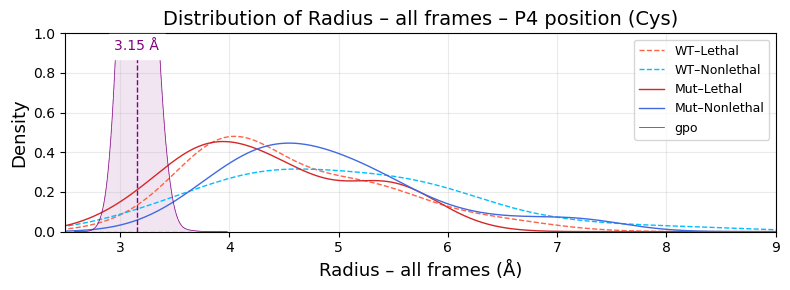

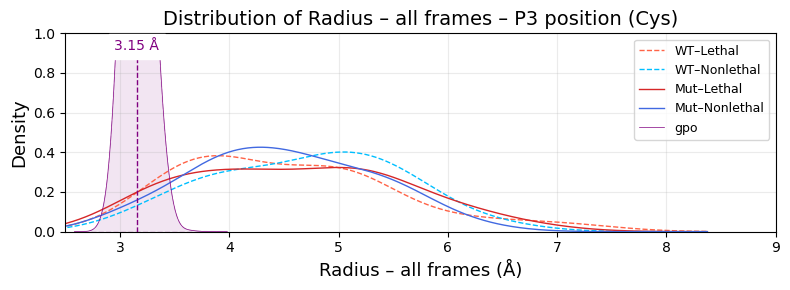

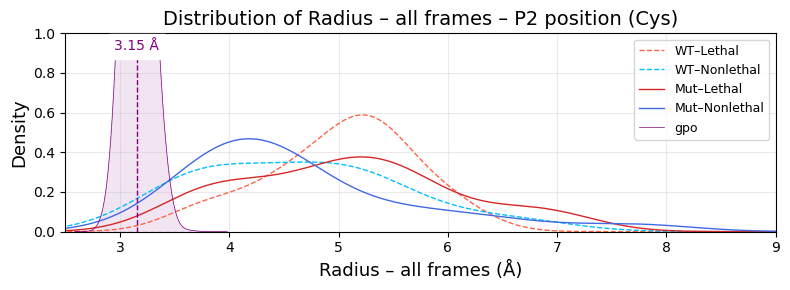

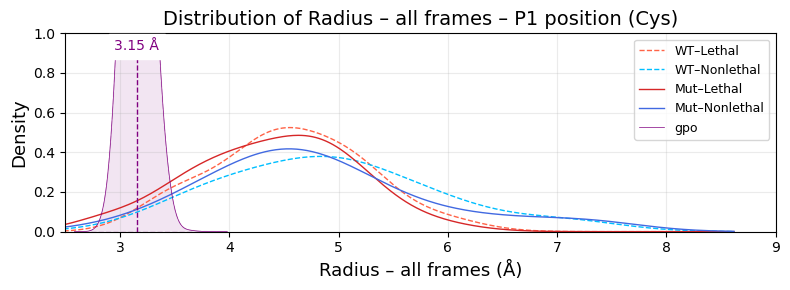

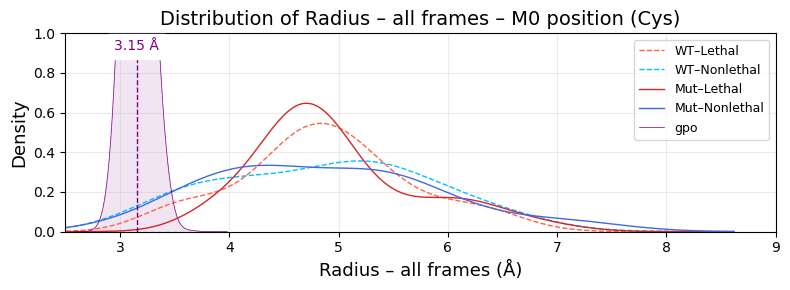

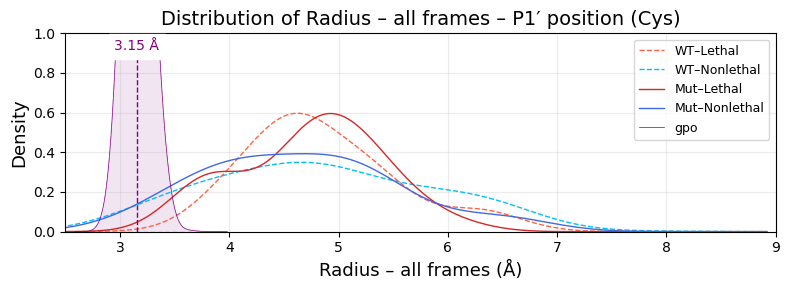

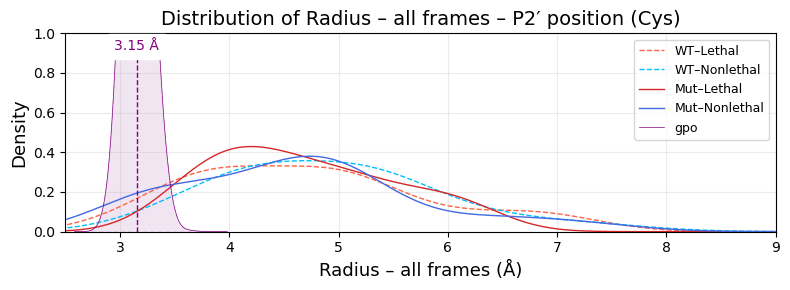

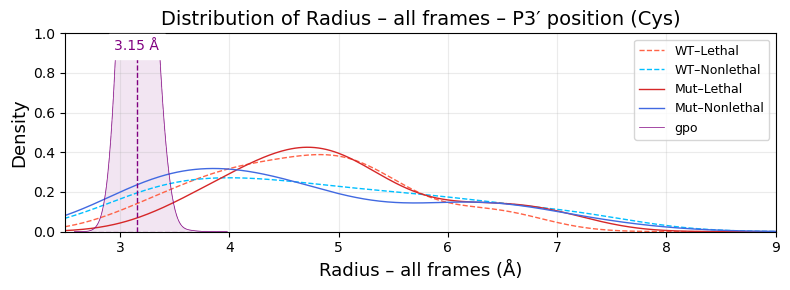

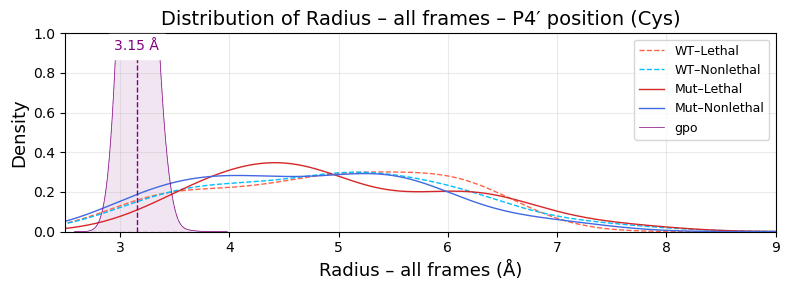

In [64]:
# 用平均的版本（(587,9)）
# for lbl in pos_labels_all:
    # plot_kde_onepos_wt_vs_mut(radius_avg, radius_wt_avg, meta,
    #                           pos_label=lbl, t_title="Radius")

# 用全時間步版本（(587,100,9) → 自動攤平）
for lbl in pos_labels_all:
    plot_kde_onepos_wt_vs_mut(radius_all, radius_wt, meta,
                              pos_label=lbl, t_title="Radius – all frames")


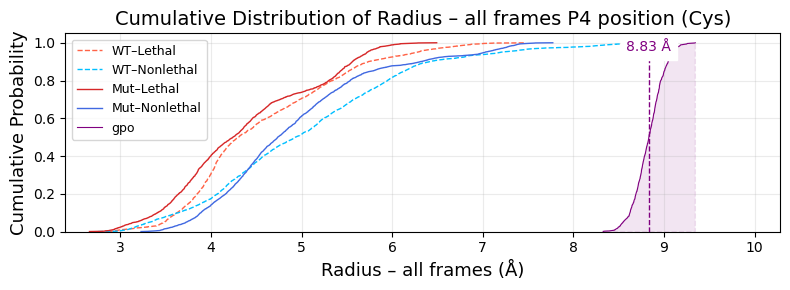

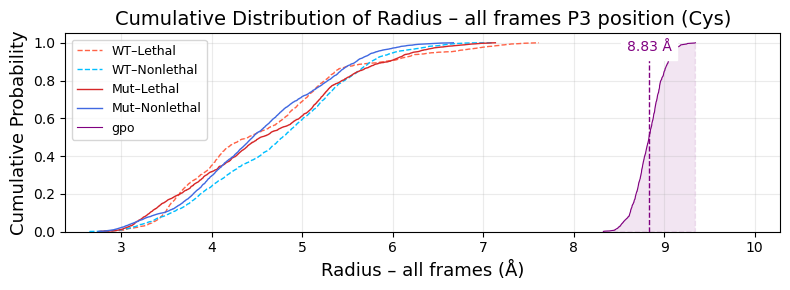

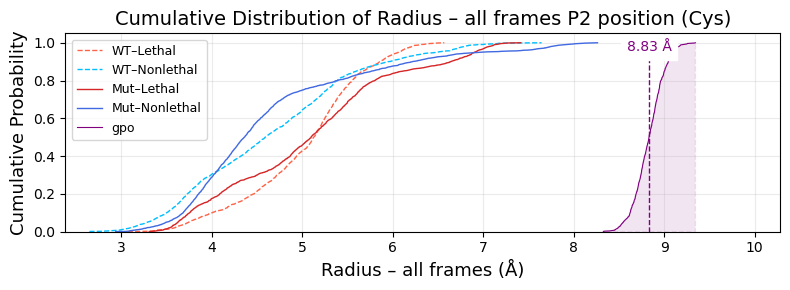

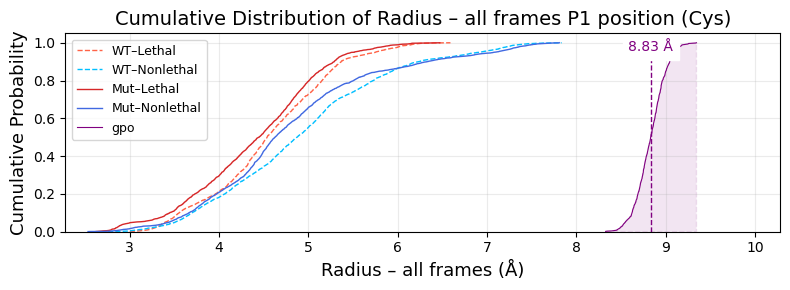

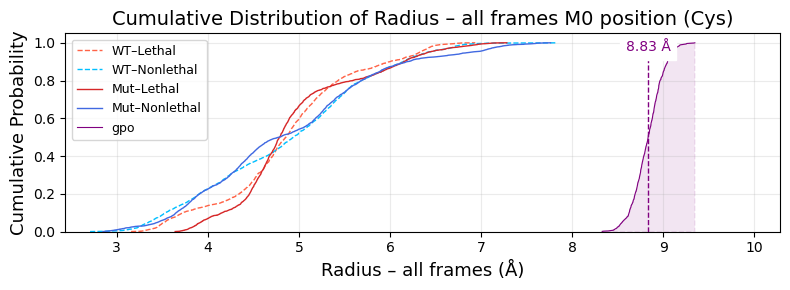

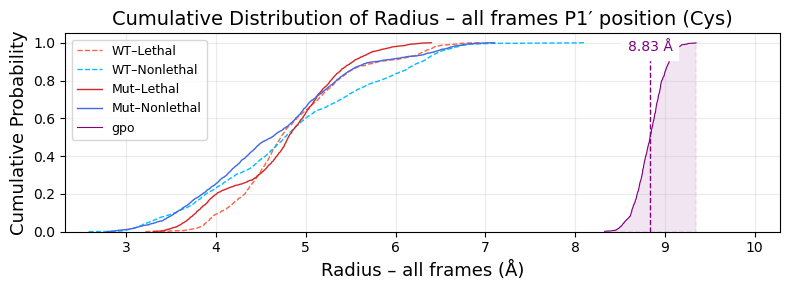

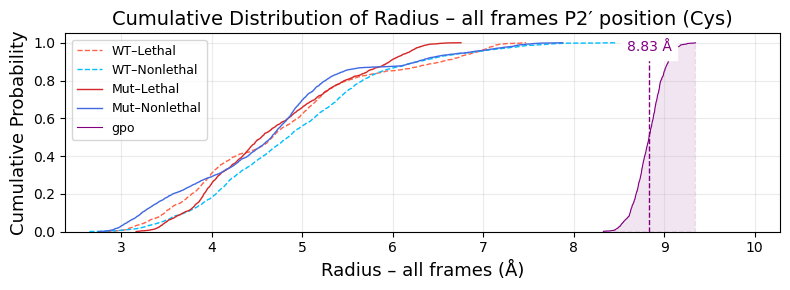

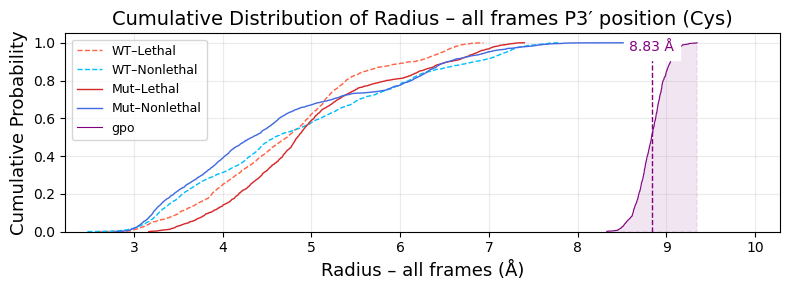

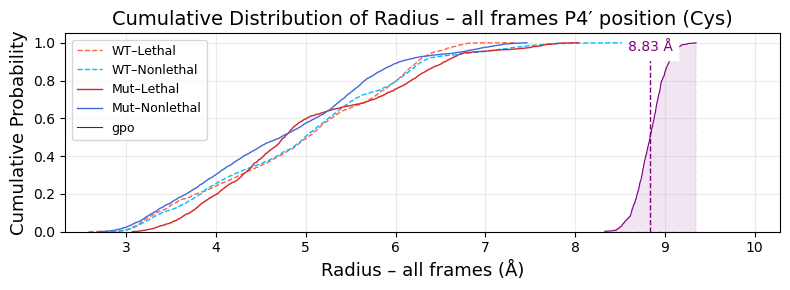

In [65]:
for lbl in pos_labels_all:
    plot_cdf_onepos_wt_vs_mut(radius_all, radius_wt, meta,
                              pos_label=lbl, t_title="Radius – all frames")


## uh_CYS ana

### L/N -MUT/WT

#### KDE

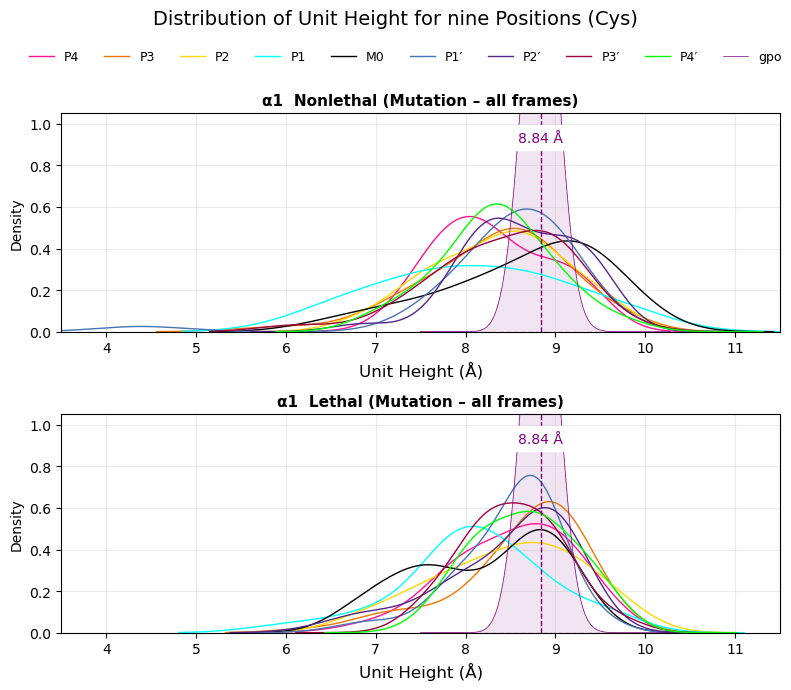

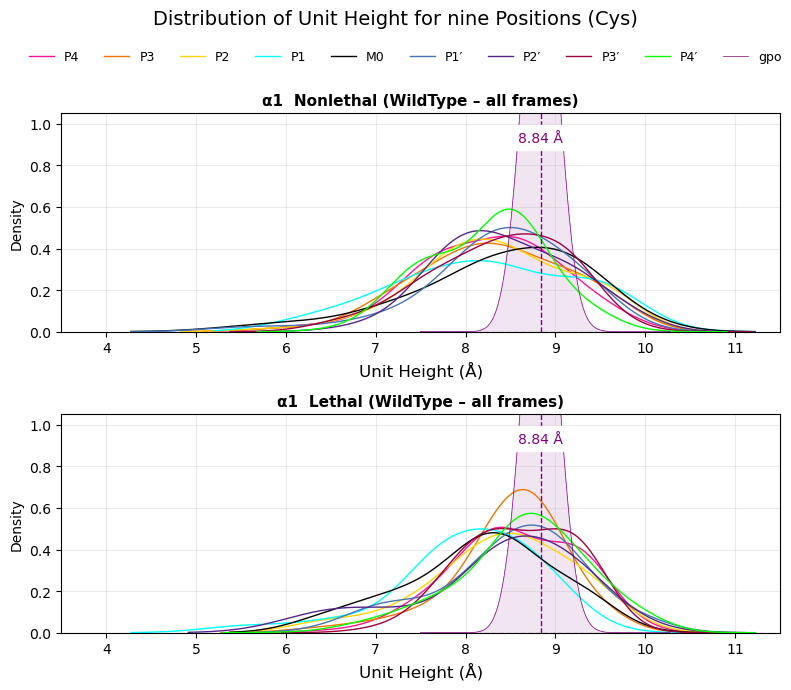

In [67]:
def plot_kde_4groups(data_all, meta, title_prefix, t_tittle,
                     pos_labels=None, colors=None,
                     bw_pos=0.45, bw_gpo=0.7):
    """
    data_all : (N, 9) 或 (N, T, 9) ← 每條突變的 9 個位置；或含 T 個時間步
    meta     : dict 必含 mutation_name_arr, lethal_arr, alpha12_arr（長度 N）
               若 data_all 是 3D，內部會自動 repeat 以對齊攤平後樣本數
    只畫 Cys，並拆 α1×(lethal / non-lethal) 四組中的兩組（目前只畫 α1 的兩組）。
    """
    if pos_labels is None:
        pos_labels = ["P4","P3","P2","P1","M0","P1′","P2′","P3′","P4′"]
    if colors is None:
        colors = ["#ff1493", "#ee7600", "#ffd700", "#00ffff",
                  "#000000", "#4575b4", "#542788", "#9e0142", "#00ff00"]

    # 0) 先把 meta 取出（原始長度 N）
    mut  = meta["mutation_name_arr"].astype(str)
    leth = meta["lethal_arr"]
    a12  = meta["alpha12_arr"]

    # —— 形狀處理：支援 2D 與 3D，並同步 repeat meta ——
    if data_all.ndim == 3:
        N, T, P = data_all.shape
        assert P == 9, f"最後一維應為 9，取得 {P}"
        data_flat = data_all.reshape(N*T, P)
        mut  = np.repeat(mut,  T)
        leth = np.repeat(leth, T)
        a12  = np.repeat(a12,  T)
    elif data_all.ndim == 2:
        data_flat = data_all
    else:
        raise ValueError("data_all 形狀需為 (N,9) 或 (N,T,9)")

    # 1) 篩 Cys
    is_cys   = (mut == "CYS")
    data_cys = data_flat[is_cys]
    a12_cys  = a12[is_cys]
    leth_cys = leth[is_cys]

    # 2) 四個遮罩（目前啟用 α1 的兩組）
    mask = {
        "a1_lethal":     (a12_cys == 1) & (leth_cys == 0),
        "a1_nonlethal":  (a12_cys == 1) & (leth_cys == 1),
        # 若要加 α2，只需解開下面兩行，並在 titles/datasets 中補上
        # "a2_lethal":     (a12_cys == 2) & (leth_cys == 0),
        # "a2_nonlethal":  (a12_cys == 2) & (leth_cys == 1),
    }
    titles = [
        f"α1  Nonlethal ({t_tittle})",
        f"α1  Lethal ({t_tittle})",
    ]

    # 3) 整理 datasets → list(子圖) × list(9 個位置的一維樣本)
    datasets = []
    for key in ["a1_nonlethal", "a1_lethal"]:
        sel = data_cys[mask[key]]                 # (n_samples, 9)
        per_pos = [sel[:, i] for i in range(9)]   # 9 個位置各自一維樣本
        datasets.append(per_pos)

    # 4) 畫圖
    fig, axes = plt.subplots(2, 1, figsize=(8, 7))
    axes = axes.ravel()

    for ax, data9, sub_title in zip(axes, datasets, titles):
        y_max = 0.0
        for i, samples in enumerate(data9):
            if samples.size == 0:
                continue
            kde = gaussian_kde(samples, bw_pos)
            xs  = np.linspace(samples.min()*0.9, samples.max()*1.1, 300)
            ys  = kde(xs)
            ax.plot(xs, ys, color=colors[i], linewidth=1.0, label=pos_labels[i])
            y_max = max(y_max, ys.max())

        # 疊上 combined（gpo：triplet 2–9）的 KDE（使用 gpo_radius_traj）
        if 'gpo_unit_hei_traj' in globals():
            combined_vals = gpo_unit_hei_traj[:, 1:].ravel()
            if combined_vals.size:
                kde_c = gaussian_kde(combined_vals, bw_method=bw_gpo)
                xs_c  = np.linspace(combined_vals.min()*0.9,
                                    combined_vals.max()*1.1, 300)
                ys_c  = kde_c(xs_c)
                ax.plot(xs_c, ys_c, color="purple", lw=0.5, label="gpo")
                ax.fill_between(xs_c, ys_c, linestyle='--', color="purple", alpha=0.1)

                # 標記峰值位置
                peak_x = xs_c[np.argmax(ys_c)]
                ax.axvline(peak_x, color="purple", linestyle="--", linewidth=1)
                # 標籤放相對位置，避免覆蓋
                y_for_text = max(0.9, min(0.95, (ax.get_ylim()[1] if y_max == 0 else y_max*0.95)))
                ax.text(peak_x, y_for_text, f"{peak_x:.2f} Å",
                        color="purple", ha="center", va="bottom",
                        fontsize=10, backgroundcolor="white")

        ax.set_title(sub_title, fontsize=11, fontweight='bold')
        ax.set_xlabel(f"{title_prefix} (Å)", fontsize=12)
        ax.grid(True, alpha=.25)

    # 左側 y label
    for ax in axes:
        ax.set_ylabel("Density")
        ax.set_ylim(0, 1.05)
        ax.set_xlim(3.5, 11.5)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, ncol=10, loc=(0.03, 0.9),
                   frameon=False, fontsize=9)

    fig.suptitle(f"Distribution of {title_prefix} for nine Positions (Cys)",
                 fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()
meta = {
    "mutation_name_arr": mutation_name_arr,  # 長度 587
    "lethal_arr":        lethal_arr,         # 長度 587
    "alpha12_arr":       alpha12_arr,        # 長度 587
}

# 3D → 自動攤平 (587*T, 9) 並 repeat meta
plot_kde_4groups(unit_hei_all,   meta, "Unit Height", "Mutation – all frames")
plot_kde_4groups(unit_hei_wt, meta, "Unit Height", "WildType – all frames")


#### CDF

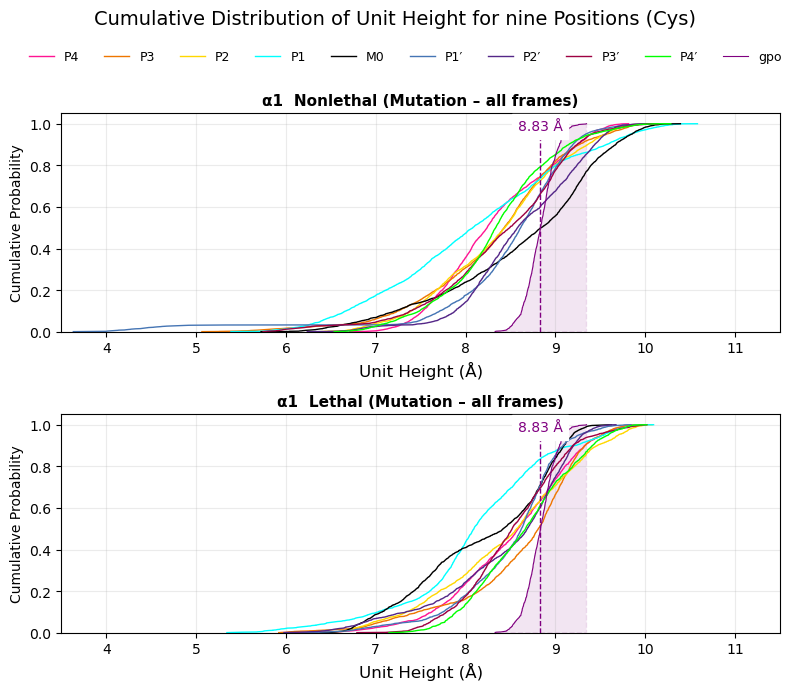

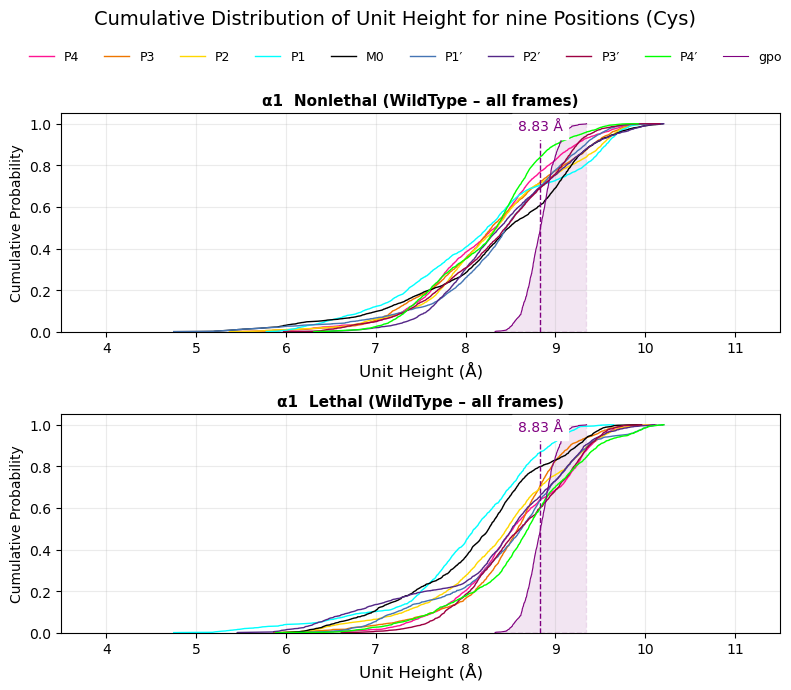

In [46]:
def plot_cdf_4groups(data_all, meta, title_prefix, t_tittle,
                     pos_labels=None, colors=None):
    """
    data_all : (N, 9) 或 (N, T, 9) ← 每條突變的 9 個位置；或含 T 個時間步
    meta     : dict 必含 mutation_name_arr, lethal_arr, alpha12_arr（長度 N）
               若 data_all 是 3D，內部會自動 repeat 以對齊攤平後樣本數
    只畫 Cys，並拆 α1×(lethal / non-lethal) 四組中的兩組（目前只畫 α1 的兩組）。
    """
    if pos_labels is None:
        pos_labels = ["P4","P3","P2","P1","M0","P1′","P2′","P3′","P4′"]
    if colors is None:
        colors = ["#ff1493", "#ee7600", "#ffd700", "#00ffff",
                  "#000000", "#4575b4", "#542788", "#9e0142", "#00ff00"]

    # 0) 先把 meta 取出（原始長度 N）
    mut  = meta["mutation_name_arr"].astype(str)
    leth = meta["lethal_arr"]
    a12  = meta["alpha12_arr"]

    # —— 形狀處理：支援 2D 與 3D，並同步 repeat meta ——
    if data_all.ndim == 3:
        N, T, P = data_all.shape
        assert P == 9, f"最後一維應為 9，取得 {P}"
        data_flat = data_all.reshape(N*T, P)
        mut  = np.repeat(mut,  T)
        leth = np.repeat(leth, T)
        a12  = np.repeat(a12,  T)
    elif data_all.ndim == 2:
        data_flat = data_all
    else:
        raise ValueError("data_all 形狀需為 (N,9) 或 (N,T,9)")

    # 1) 篩 Cys
    is_cys   = (mut == "CYS")
    data_cys = data_flat[is_cys]
    a12_cys  = a12[is_cys]
    leth_cys = leth[is_cys]

    # 2) 四個遮罩（目前啟用 α1 的兩組）
    mask = {
        "a1_lethal":     (a12_cys == 1) & (leth_cys == 0),
        "a1_nonlethal":  (a12_cys == 1) & (leth_cys == 1),
        # 若要加 α2，只需解開下面兩行，並在 titles/datasets 中補上
        # "a2_lethal":     (a12_cys == 2) & (leth_cys == 0),
        # "a2_nonlethal":  (a12_cys == 2) & (leth_cys == 1),
    }
    titles = [
        f"α1  Nonlethal ({t_tittle})",
        f"α1  Lethal ({t_tittle})",
    ]

    # 3) 整理 datasets → list(子圖) × list(9 個位置的一維樣本)
    datasets = []
    for key in ["a1_nonlethal", "a1_lethal"]:
        sel = data_cys[mask[key]]                 # (n_samples, 9)
        per_pos = [sel[:, i] for i in range(9)]   # 9 個位置各自一維樣本
        datasets.append(per_pos)

    # 4) 畫 CDF
    fig, axes = plt.subplots(2, 1, figsize=(8, 7))
    axes = axes.ravel()

    for ax, data9, sub_title in zip(axes, datasets, titles):
        for i, samples in enumerate(data9):
            if samples.size == 0:
                continue
            xs = np.sort(samples)
            ys = np.arange(1, len(xs)+1) / len(xs)
            ax.plot(xs, ys, color=colors[i], linewidth=1.0, label=pos_labels[i])

        # 疊上 combined（gpo：triplet 2–9）的 ECDF（使用 gpo_unit_hei_traj）
        if 'gpo_unit_hei_traj' in globals():
            combined_vals = gpo_unit_hei_traj[:, 1:].ravel()
            if combined_vals.size:
                xs_c = np.sort(combined_vals)
                ys_c = np.arange(1, len(xs_c)+1) / len(xs_c)
                ax.plot(xs_c, ys_c, color="purple", lw=0.8, label="gpo")
                ax.fill_between(xs_c, ys_c, linestyle='--', color="purple", alpha=0.1)

                # 標記中位數
                median_x = np.median(combined_vals)
                ax.axvline(median_x, color="purple", linestyle="--", linewidth=1)
                ax.text(median_x, 0.955, f"{median_x:.2f} Å",
                        color="purple", ha="center", va="bottom",
                        fontsize=10, backgroundcolor="white")

        ax.set_title(sub_title, fontsize=11, fontweight='bold')
        ax.set_xlabel(f"{title_prefix} (Å)", fontsize=12)
        ax.set_ylabel("Cumulative Probability")
        ax.grid(True, alpha=.25)
        ax.set_ylim(0, 1.05)
        ax.set_xlim(3.5, 11.5)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, ncol=10, loc=(0.03, 0.9),
                   frameon=False, fontsize=9)

    fig.suptitle(f"Cumulative Distribution of {title_prefix} for nine Positions (Cys)",
                 fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

meta = {
    "mutation_name_arr": mutation_name_arr,  # 長度 587
    "lethal_arr":        lethal_arr,         # 長度 587
    "alpha12_arr":       alpha12_arr,        # 長度 587
}

plot_cdf_4groups(unit_hei_all, meta, "Unit Height", "Mutation – all frames")
plot_cdf_4groups(unit_hei_wt,  meta, "Unit Height", "WildType – all frames")


### uh_CYS_pos

#### KDE-all

WT_L → number of peaks: 2
  Peak 1: 8.3872 Å, density=0.5220
  Peak 2: 9.1203 Å, density=0.4409
WT_N → number of peaks: 1
  Peak 1: 8.4812 Å, density=0.4683
MUT_L → number of peaks: 1
  Peak 1: 8.8008 Å, density=0.5350
MUT_N → number of peaks: 1
  Peak 1: 8.0301 Å, density=0.5677

Position P12 (Unit Height – all frames) Standard Deviations:
Standard deviation for WT_L: 0.6817 Å
Standard deviation for WT_N: 0.7710 Å
Standard deviation for MUT_L: 0.6766 Å
Standard deviation for MUT_N: 0.6382 Å
(sd_MUT_L - sd_WT_L): -0.0050
(sd_MUT_N - sd_WT_N): -0.1328
(WT_L-WT_N)std (Normalized SD difference): -0.0893


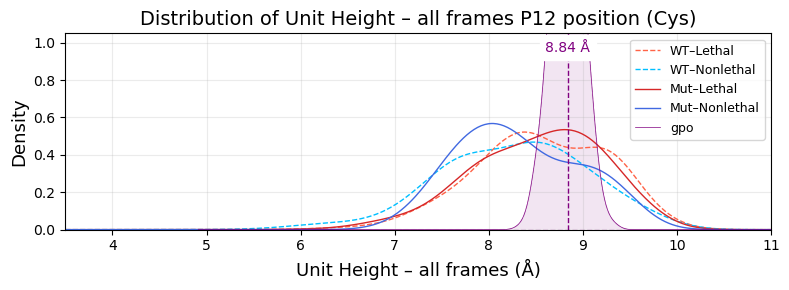

JSD (WT-L vs WT-N): 0.2454
JSD (MUT-L vs WT-L): 0.1126
JSD (MUT-N vs WT-N): 0.2918
WT_L → number of peaks: 1
  Peak 1: 8.6504 Å, density=0.7130
WT_N → number of peaks: 1
  Peak 1: 8.2368 Å, density=0.4354
MUT_L → number of peaks: 1
  Peak 1: 8.9511 Å, density=0.6586
MUT_N → number of peaks: 1
  Peak 1: 8.5564 Å, density=0.5146

Position P9 (Unit Height – all frames) Standard Deviations:
Standard deviation for WT_L: 0.6405 Å
Standard deviation for WT_N: 0.8312 Å
Standard deviation for MUT_L: 0.7263 Å
Standard deviation for MUT_N: 0.8168 Å
(sd_MUT_L - sd_WT_L): 0.0858
(sd_MUT_N - sd_WT_N): -0.0144
(WT_L-WT_N)std (Normalized SD difference): -0.1907


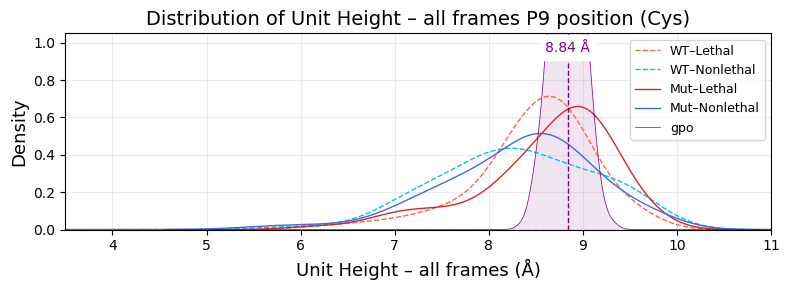

JSD (WT-L vs WT-N): 0.3350
JSD (MUT-L vs WT-L): 0.1797
JSD (MUT-N vs WT-N): 0.2702
WT_L → number of peaks: 1
  Peak 1: 8.4624 Å, density=0.4921
WT_N → number of peaks: 1
  Peak 1: 8.1805 Å, density=0.4565
MUT_L → number of peaks: 1
  Peak 1: 8.7632 Å, density=0.4424
MUT_N → number of peaks: 1
  Peak 1: 8.5564 Å, density=0.4976

Position P6 (Unit Height – all frames) Standard Deviations:
Standard deviation for WT_L: 0.8011 Å
Standard deviation for WT_N: 0.8351 Å
Standard deviation for MUT_L: 0.8057 Å
Standard deviation for MUT_N: 0.7341 Å
(sd_MUT_L - sd_WT_L): 0.0046
(sd_MUT_N - sd_WT_N): -0.1010
(WT_L-WT_N)std (Normalized SD difference): -0.0340


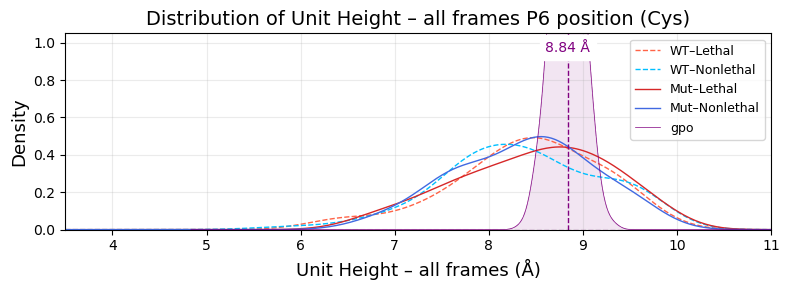

JSD (WT-L vs WT-N): 0.2123
JSD (MUT-L vs WT-L): 0.2603
JSD (MUT-N vs WT-N): 0.2000
WT_L → number of peaks: 1
  Peak 1: 8.1805 Å, density=0.5078
WT_N → number of peaks: 2
  Peak 1: 8.1617 Å, density=0.3503
  Peak 2: 9.3083 Å, density=0.2664
MUT_L → number of peaks: 1
  Peak 1: 8.0489 Å, density=0.5311
MUT_N → number of peaks: 1
  Peak 1: 8.0301 Å, density=0.3213

Position P3 (Unit Height – all frames) Standard Deviations:
Standard deviation for WT_L: 0.8214 Å
Standard deviation for WT_N: 0.9938 Å
Standard deviation for MUT_L: 0.8268 Å
Standard deviation for MUT_N: 1.0487 Å
(sd_MUT_L - sd_WT_L): 0.0054
(sd_MUT_N - sd_WT_N): 0.0549
(WT_L-WT_N)std (Normalized SD difference): -0.1725


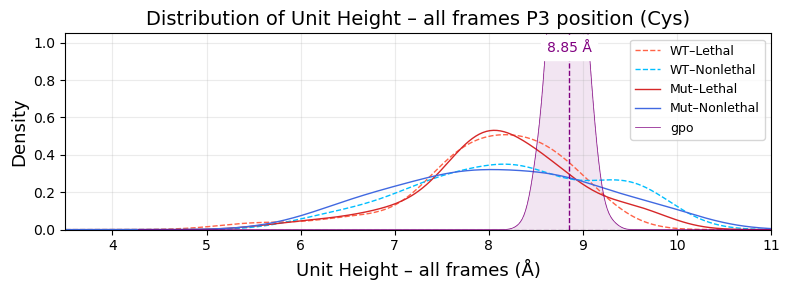

JSD (WT-L vs WT-N): 0.4298
JSD (MUT-L vs WT-L): 0.1503
JSD (MUT-N vs WT-N): 0.2661
WT_L → number of peaks: 1
  Peak 1: 8.3120 Å, density=0.5008
WT_N → number of peaks: 1
  Peak 1: 8.8571 Å, density=0.4148
MUT_L → number of peaks: 2
  Peak 1: 7.5789 Å, density=0.3368
  Peak 2: 8.8383 Å, density=0.5256
MUT_N → number of peaks: 1
  Peak 1: 9.1579 Å, density=0.4537

Position M0 (Unit Height – all frames) Standard Deviations:
Standard deviation for WT_L: 0.8169 Å
Standard deviation for WT_N: 0.9797 Å
Standard deviation for MUT_L: 0.7750 Å
Standard deviation for MUT_N: 0.9176 Å
(sd_MUT_L - sd_WT_L): -0.0418
(sd_MUT_N - sd_WT_N): -0.0621
(WT_L-WT_N)std (Normalized SD difference): -0.1628


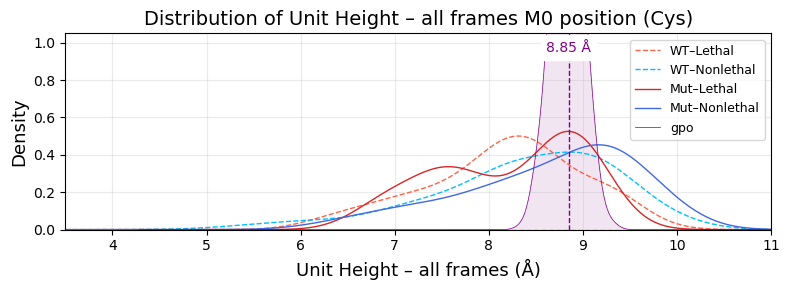

JSD (WT-L vs WT-N): 0.2989
JSD (MUT-L vs WT-L): 0.2196
JSD (MUT-N vs WT-N): 0.2301
WT_L → number of peaks: 1
  Peak 1: 8.7444 Å, density=0.5339
WT_N → number of peaks: 1
  Peak 1: 8.4812 Å, density=0.5155
MUT_L → number of peaks: 1
  Peak 1: 8.7256 Å, density=0.7911
MUT_N → number of peaks: 2
  Peak 1: 4.3835 Å, density=0.0271
  Peak 2: 8.6880 Å, density=0.6174

Position P3′ (Unit Height – all frames) Standard Deviations:
Standard deviation for WT_L: 0.7913 Å
Standard deviation for WT_N: 0.8363 Å
Standard deviation for MUT_L: 0.5805 Å
Standard deviation for MUT_N: 0.9000 Å
(sd_MUT_L - sd_WT_L): -0.2108
(sd_MUT_N - sd_WT_N): 0.0637
(WT_L-WT_N)std (Normalized SD difference): -0.0450


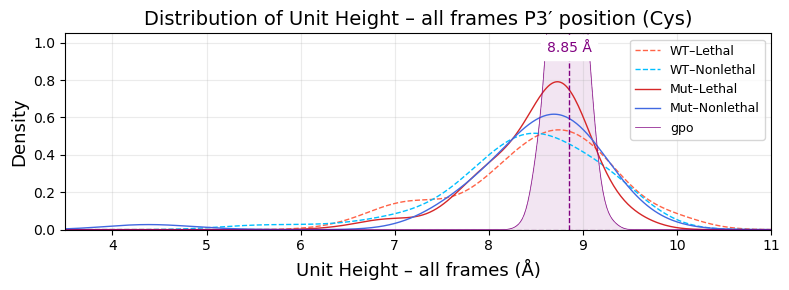

JSD (WT-L vs WT-N): 0.1897
JSD (MUT-L vs WT-L): 0.3043
JSD (MUT-N vs WT-N): 0.2693
WT_L → number of peaks: 2
  Peak 1: 6.7895 Å, density=0.1247
  Peak 2: 8.6504 Å, density=0.4809
WT_N → number of peaks: 1
  Peak 1: 8.1429 Å, density=0.4963
MUT_L → number of peaks: 1
  Peak 1: 8.8947 Å, density=0.6323
MUT_N → number of peaks: 3
  Peak 1: 6.9023 Å, density=0.0417
  Peak 2: 8.3496 Å, density=0.5618
  Peak 3: 9.0639 Å, density=0.4669

Position P6′ (Unit Height – all frames) Standard Deviations:
Standard deviation for WT_L: 0.9437 Å
Standard deviation for WT_N: 0.7218 Å
Standard deviation for MUT_L: 0.7339 Å
Standard deviation for MUT_N: 0.6405 Å
(sd_MUT_L - sd_WT_L): -0.2098
(sd_MUT_N - sd_WT_N): -0.0812
(WT_L-WT_N)std (Normalized SD difference): 0.2220


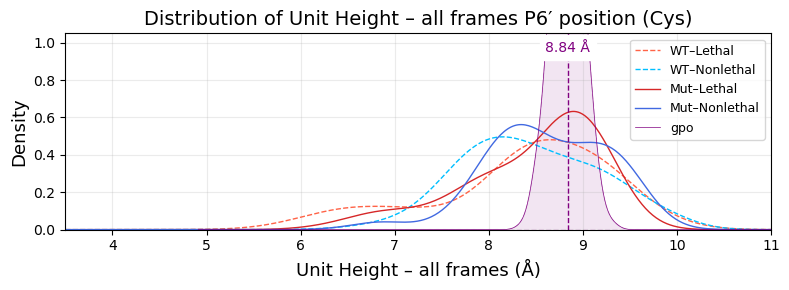

JSD (WT-L vs WT-N): 0.2231
JSD (MUT-L vs WT-L): 0.2753
JSD (MUT-N vs WT-N): 0.2659
WT_L → number of peaks: 2
  Peak 1: 8.3496 Å, density=0.5077
  Peak 2: 9.0639 Å, density=0.5076
WT_N → number of peaks: 1
  Peak 1: 8.6692 Å, density=0.4756
MUT_L → number of peaks: 1
  Peak 1: 8.5188 Å, density=0.6290
MUT_N → number of peaks: 2
  Peak 1: 6.1880 Å, density=0.0353
  Peak 2: 8.8195 Å, density=0.5013

Position P9′ (Unit Height – all frames) Standard Deviations:
Standard deviation for WT_L: 0.6187 Å
Standard deviation for WT_N: 0.7453 Å
Standard deviation for MUT_L: 0.5526 Å
Standard deviation for MUT_N: 0.7770 Å
(sd_MUT_L - sd_WT_L): -0.0661
(sd_MUT_N - sd_WT_N): 0.0317
(WT_L-WT_N)std (Normalized SD difference): -0.1266


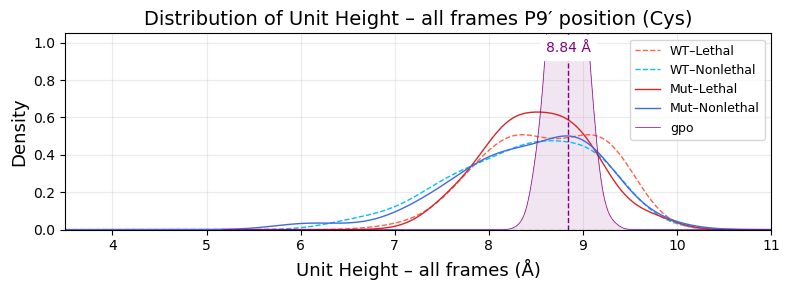

JSD (WT-L vs WT-N): 0.3262
JSD (MUT-L vs WT-L): 0.3090
JSD (MUT-N vs WT-N): 0.2371
WT_L → number of peaks: 1
  Peak 1: 8.7256 Å, density=0.5959
WT_N → number of peaks: 1
  Peak 1: 8.4812 Å, density=0.6149
MUT_L → number of peaks: 1
  Peak 1: 8.7256 Å, density=0.5924
MUT_N → number of peaks: 1
  Peak 1: 8.3496 Å, density=0.6346

Position P12′ (Unit Height – all frames) Standard Deviations:
Standard deviation for WT_L: 0.7153 Å
Standard deviation for WT_N: 0.6439 Å
Standard deviation for MUT_L: 0.5643 Å
Standard deviation for MUT_N: 0.6430 Å
(sd_MUT_L - sd_WT_L): -0.1510
(sd_MUT_N - sd_WT_N): -0.0009
(WT_L-WT_N)std (Normalized SD difference): 0.0714


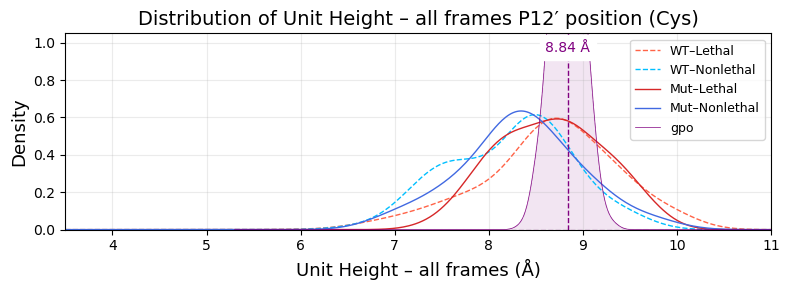

JSD (WT-L vs WT-N): 0.1471
JSD (MUT-L vs WT-L): 0.1733
JSD (MUT-N vs WT-N): 0.1177


In [61]:
# 改------------------------------------------------------------
# 單一位置 WT vs Mut 分布圖 (KDE / PDF)
from scipy import integrate
from scipy.spatial import distance
from scipy.signal import find_peaks


def jsd_from_samples(p_samples, q_samples, bins=20, range_=None, base=2, eps=1e-12):
    """
    計算 Jensen-Shannon Divergence (JSD)
    """
    p_samples = np.asarray(p_samples, dtype=float)
    q_samples = np.asarray(q_samples, dtype=float)

    if range_ is None:
        min_val = min(p_samples.min(), q_samples.min())
        max_val = max(p_samples.max(), q_samples.max())
        range_ = (min_val, max_val)

    p_hist, _ = np.histogram(p_samples, bins=bins, range=range_, density=False)
    q_hist, _ = np.histogram(q_samples, bins=bins, range=range_, density=False)
    p = p_hist / p_hist.sum()
    q = q_hist / q_hist.sum()
    p = np.where(p == 0, eps, p)
    q = np.where(q == 0, eps, q)
    m = 0.5 * (p + q)
    m = np.where(m == 0, eps, m)

    jsd = 0.5 * distance.rel_entr(p, m).sum() + 0.5 * distance.rel_entr(q, m).sum()
    jsd /= np.log(base)
    return np.sqrt(jsd)

def calculate_jsd_for_wt_samples(samples):
    """
    計算 WT-L vs WT-N`，MUT-L vs WT-L`，`MUT-N vs WT-N` 的 JSD
    """
    # 計算需要的 JSD
    jsd_wt_l_vs_wt_n = jsd_from_samples(samples[:,0], samples[:,1])
    jsd_mut_l_vs_wt_l = jsd_from_samples(samples[:,2], samples[:,0])
    jsd_mut_n_vs_wt_n = jsd_from_samples(samples[:,3], samples[:,1])

    print(f"JSD (WT-L vs WT-N): {jsd_wt_l_vs_wt_n:.4f}")
    print(f"JSD (MUT-L vs WT-L): {jsd_mut_l_vs_wt_l:.4f}")
    print(f"JSD (MUT-N vs WT-N): {jsd_mut_n_vs_wt_n:.4f}")
    
    return {
        "JSD_WT_L_vs_WT_N": jsd_wt_l_vs_wt_n,
        "JSD_MUT_L_vs_WT_L": jsd_mut_l_vs_wt_l,
        "JSD_MUT_N_vs_WT_N": jsd_mut_n_vs_wt_n
    }

# --- 計算標準差的函數 -------------------------------------------
def calculate_standard_deviation(samples):
    """
    計算每條線段的標準差並返回
    """
    std_devs = {key: np.std(vals) for key, vals in samples.items()}
    
    # 顯示每條線段的標準差
    for key, std_dev in std_devs.items():
        print(f"Standard deviation for {key}: {std_dev:.4f} Å")
    
    return std_devs

# 計算標準化差異指標
def normalized_sd_difference(samples):
    """
    計算 WT_L-MUT_L 和 WT_N-MUT_N 的標準化差異指標：
    (SD(WT) - SD(MUT)) / (max(WT) - min(WT))
    
    samples: dict，包含 'WT_L', 'MUT_L', 'WT_N', 'MUT_N'
    return: dict，包含 L_std 和 N_std 的差異，若 N 不存在則顯示 None
    """
    results = {}

    # L 組
    if samples["WT_L"].size > 0 and samples["MUT_L"].size > 0:
        WT_L = samples["WT_L"]
        MUT_L = samples["MUT_L"]
        sd_WT_L = np.std(WT_L)
        sd_MUT_L = np.std(MUT_L)
        results["L_std"] = (sd_MUT_L - sd_WT_L)
        print(f"(sd_MUT_L - sd_WT_L): {results['L_std']:.4f}")
    else:
        results["L_std"] = None
        print("No L (lethal) samples, cannot calculate normalized SD difference")

    # N 組
    if "WT_N" in samples and "MUT_N" in samples and samples["WT_N"].size > 0 and samples["MUT_N"].size > 0:
        WT_N = samples["WT_N"]
        MUT_N = samples["MUT_N"]
        sd_WT_N = np.std(WT_N)
        sd_MUT_N = np.std(MUT_N)
        results["N_std"] = (sd_MUT_N - sd_WT_N)
        print(f"(sd_MUT_N - sd_WT_N): {results['N_std']:.4f}")
    else:
        results["N_std"] = None
        print("No N (non-lethal) samples, cannot calculate normalized SD difference")

    if samples["WT_L"].size > 0 and samples["WT_N"].size > 0:
        WT_L = samples["WT_L"]
        WT_N = samples["WT_N"]
        sd_WT_L = np.std(WT_L)
        sd_WT_N = np.std(WT_N)
        results["WT_L-N_std"] = (sd_WT_L - sd_WT_N)
        print(f"(WT_L-WT_N)std (Normalized SD difference): {results['WT_L-N_std']:.4f}")
    else:
        results["L_std"] = None
        print("No L (lethal) samples, cannot calculate normalized SD difference")

    return results

                   
def plot_kde_onepos_wt_vs_mut(
    data_mut, data_wt, meta,
    pos_label="M0", t_title="Unit Height",
    # bw_pos=0.45, bw_gpo=0.7,
    xlim=None, ylim=(0, 1)
):
    """
    data_mut : (N, 9) 或 (N, T, 9) ← mutant（每條 9 位置；或含 T 個時間步）
    data_wt  : (N, 9) 或 (N, T, 9) ← WT
    meta     : dict ← mutation_name(_arr) / lethal_arr / alpha12_arr（長度 N）
               若 data_* 是 3D，會自動 repeat 以對齊攤平後樣本數
    僅取 Cys、α1，並拆成 Lethal / Nonlethal；WT 用相同遮罩。
    """

    # --- 位置索引 ---------------------------------------------------
    pos_labels_all = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]
    if pos_label not in pos_labels_all:
        raise ValueError(f"pos_label 必須是 {pos_labels_all} 之一")
    idx = pos_labels_all.index(pos_label)

    # --- 取得 meta 欄位（支援 *_arr 或無尾綴） ------------------------
    def _get(meta, base):
        if base in meta: return np.asarray(meta[base])
        if f"{base}_arr" in meta: return np.asarray(meta[f"{base}_arr"])
        raise KeyError(f"meta 缺少：{base} 或 {base}_arr")

    mut_name = _get(meta, "mutation_name").astype(str)
    lethal   = _get(meta, "lethal")
    alpha12  = _get(meta, "alpha12")

    # --- 攤平資料 & 同步 repeat meta --------------------------------
    def _flatten_and_repeat(data, mut_name, lethal, alpha12):
        if data.ndim == 3:
            N, T, P = data.shape
            assert P == 9, f"最後一維應為 9，取得 {P}"
            data2d  = data.reshape(N*T, P)
            return (data2d,
                    np.repeat(mut_name, T),
                    np.repeat(lethal, T),
                    np.repeat(alpha12, T))
        elif data.ndim == 2:
            return data, mut_name, lethal, alpha12
        else:
            raise ValueError("data_* 形狀需為 (N,9) 或 (N,T,9)")

    mut2d, mut_name_r, leth_r, a12_r = _flatten_and_repeat(data_mut, mut_name, lethal, alpha12)
    wt2d,  _,           _,     _     = _flatten_and_repeat(data_wt,  mut_name, lethal, alpha12)

    # --- 只取 Cys，僅 α1，拆 lethal / non-lethal ---------------------
    is_cys   = (mut_name_r == "CYS")
    mut_cys  = mut2d[is_cys]
    wt_cys   = wt2d[is_cys]
    leth_cys = leth_r[is_cys]
    a12_cys  = a12_r[is_cys]

    mask_lethal    = (a12_cys == 1) & (leth_cys == 0)
    mask_nonlethal = (a12_cys == 1) & (leth_cys == 1)

    # --- 收集樣本 ---------------------------------------------------
    samples = dict(
        WT_L   = wt_cys[mask_lethal,    idx],
        WT_N   = wt_cys[mask_nonlethal, idx],
        MUT_L  = mut_cys[mask_lethal,   idx],
        MUT_N  = mut_cys[mask_nonlethal,idx],
    )
    


    if not any(v.size for v in samples.values()):
        print(f"[警告] {pos_label} 在目前遮罩下沒有樣本可畫。")
        return

    # --- 決定 X 軸範圍 ---------------------------------------------
    vals_list = [v for v in samples.values() if v.size]
    all_vals = np.concatenate(vals_list)

    if 'gpo_unit_hei_traj' in globals():
        gpo_vals = gpo_unit_hei_traj[:, 1:].ravel()
        if gpo_vals.size:
            all_vals = np.concatenate([all_vals, gpo_vals])

    if xlim is None:
        x_min, x_max = all_vals.min()*0.9, all_vals.max()*1.1
    else:
        x_min, x_max = xlim
    xs = np.linspace(3.5, 11, 400)

    # --- 繪圖 --------------------------------------------------------
    plt.figure(figsize=(8, 3))

    style = dict(
        WT_L  = dict(color='tomato',      ls='--', lw=1, label='WT–Lethal'),
        WT_N  = dict(color='deepskyblue', ls='--', lw=1, label='WT–Nonlethal'),
        MUT_L = dict(color='#d62728',     lw=1,    label='Mut–Lethal'),
        MUT_N = dict(color='royalblue',   lw=1,    label='Mut–Nonlethal'),
    )

    kde_all = np.zeros((400,4))
    i = 0
    for key, vals in samples.items():
        if vals.size == 0: 
            continue

        kde = gaussian_kde(vals, 0.4)
        y = kde(xs)
        plt.plot(xs, y, **style[key])
        kde_all[:, i] = y
        i += 1

        # --- 找到所有峰 ---
        peaks, properties = find_peaks(y, height=0.001, distance=5)
        num_peaks = len(peaks)
        print(f"{key} → number of peaks: {num_peaks}")

        if num_peaks > 0:
            for j, pk in enumerate(peaks):
                peak_x = xs[pk]
                peak_y = y[pk]
                print(f"  Peak {j+1}: {peak_x:.4f} Å, density={peak_y:.4f}")


        # peak_percentage = peak_range_percentage(vals, bw=0.4)
        # print(f"Peak range percentage for {key}: {peak_percentage:.2f}%")   

    # 疊上 gpo（triplet 2–9）
    if 'gpo_unit_hei_traj' in globals():
        combined_vals = gpo_unit_hei_traj[:, 1:].ravel()
        if combined_vals.size:
            xs_c  = np.linspace(x_min, x_max, 400)
            kde_c = gaussian_kde(combined_vals, 0.4)
            ys_c  = kde_c(xs_c)
            plt.plot(xs_c, ys_c, color="purple", lw=0.5, label="gpo")
            plt.fill_between(xs_c, ys_c, linestyle='--', color="purple", alpha=0.1)

            # 峰值標記
            peak_x = xs_c[np.argmax(ys_c)]
            plt.axvline(peak_x, color="purple", linestyle="--", linewidth=1)
            plt.text(peak_x, (ylim[1] if ylim else 1)*0.935,
                     f"{peak_x:.2f} Å",
                     color="purple", ha="center", va="bottom",
                     fontsize=10, backgroundcolor="white")
            
    print(f"\nPosition {pos_label} ({t_title}) Standard Deviations:")
    std_devs = calculate_standard_deviation(samples)
    # 正規化標準差差異
    norm_diff = normalized_sd_difference(samples)

    # 軸 & 標題
    plt.xlabel(f"{t_title} (Å)", fontsize=13)
    plt.ylabel("Density", fontsize=13)
    plt.xlim(3.5, 11)
    plt.ylim(0, 1.05)
    plt.title(f"Distribution of {t_title} {pos_label} position (Cys)", fontsize=14)
    plt.legend(fontsize=9)
    plt.grid(True, alpha=.25)
    plt.tight_layout()
    plt.show()

    return kde_all

# ------------------------------------------------------------
# 呼叫範例
meta = {
    "mutation_name": mutation_name_arr,  # 或 mutation_name_arr
    "lethal_arr":    lethal_arr,
    "alpha12_arr":   alpha12_arr,
}

pos_labels_all = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]

for lbl in pos_labels_all:
    kde_all = plot_kde_onepos_wt_vs_mut(
        unit_hei_all,   # mutant 資料
        unit_hei_wt,    # WT 資料
        meta,
        pos_label=lbl,
        t_title="Unit Height – all frames"
    )
    calculate_jsd_for_wt_samples(kde_all)


#### KDE-avg

WT_L → number of peaks: 2
  Peak 1: 8.3496 Å, height=0.5964
  Peak 2: 9.1579 Å, height=0.4911
WT_N → number of peaks: 3
  Peak 1: 6.3383 Å, height=0.0456
  Peak 2: 7.9549 Å, height=0.5094
  Peak 3: 8.4624 Å, height=0.5069
MUT_L → number of peaks: 1
  Peak 1: 8.7444 Å, height=0.5323
MUT_N → number of peaks: 2
  Peak 1: 7.9361 Å, height=0.6249
  Peak 2: 9.0827 Å, height=0.3537

Position P12 (Unt Height) Standard Deviations:
Standard deviation for WT_L: 0.6322 Å
Standard deviation for WT_N: 0.6958 Å
Standard deviation for MUT_L: 0.6384 Å
Standard deviation for MUT_N: 0.5915 Å
L_△std (Normalized SD difference): 0.0099
N_△std (Normalized SD difference): -0.1500
(WT_L-WT_N)std (Normalized SD difference): -0.0637


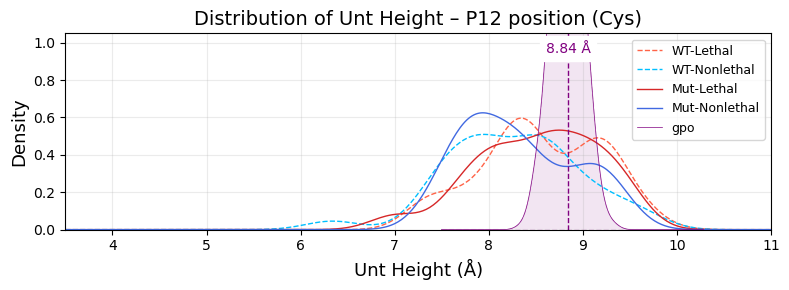

JSD (WT-L vs WT-N): 0.2520
JSD (MUT-L vs WT-L): 0.2220
JSD (MUT-N vs WT-N): 0.3342
WT_L → number of peaks: 2
  Peak 1: 6.7707 Å, height=0.0834
  Peak 2: 8.5940 Å, height=0.7481
WT_N → number of peaks: 1
  Peak 1: 8.0301 Å, height=0.4680
MUT_L → number of peaks: 2
  Peak 1: 7.4098 Å, height=0.1293
  Peak 2: 8.9511 Å, height=0.7341
MUT_N → number of peaks: 2
  Peak 1: 6.0000 Å, height=0.0407
  Peak 2: 8.5564 Å, height=0.5406

Position P9 (Unt Height) Standard Deviations:
Standard deviation for WT_L: 0.5873 Å
Standard deviation for WT_N: 0.7658 Å
Standard deviation for MUT_L: 0.6859 Å
Standard deviation for MUT_N: 0.7795 Å
L_△std (Normalized SD difference): 0.1678
N_△std (Normalized SD difference): 0.0179
(WT_L-WT_N)std (Normalized SD difference): -0.1784


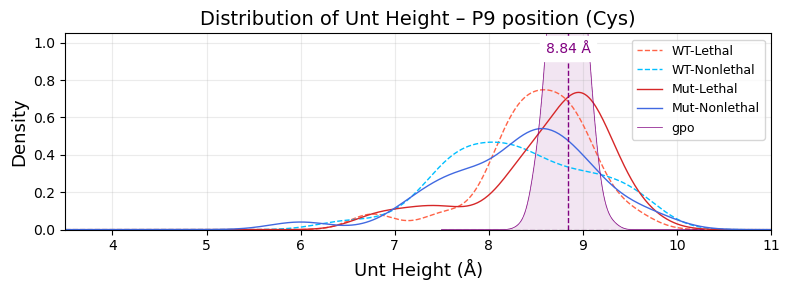

JSD (WT-L vs WT-N): 0.3625
JSD (MUT-L vs WT-L): 0.1979
JSD (MUT-N vs WT-N): 0.2364
WT_L → number of peaks: 2
  Peak 1: 6.4699 Å, height=0.0650
  Peak 2: 8.4248 Å, height=0.5079
WT_N → number of peaks: 3
  Peak 1: 6.6579 Å, height=0.0768
  Peak 2: 8.1805 Å, height=0.5448
  Peak 3: 9.2895 Å, height=0.2769
MUT_L → number of peaks: 1
  Peak 1: 8.7820 Å, height=0.4671
MUT_N → number of peaks: 2
  Peak 1: 7.6917 Å, height=0.3613
  Peak 2: 8.5752 Å, height=0.5410

Position P6 (Unt Height) Standard Deviations:
Standard deviation for WT_L: 0.7679 Å
Standard deviation for WT_N: 0.7778 Å
Standard deviation for MUT_L: 0.7761 Å
Standard deviation for MUT_N: 0.6948 Å
L_△std (Normalized SD difference): 0.0106
N_△std (Normalized SD difference): -0.1067
(WT_L-WT_N)std (Normalized SD difference): -0.0099


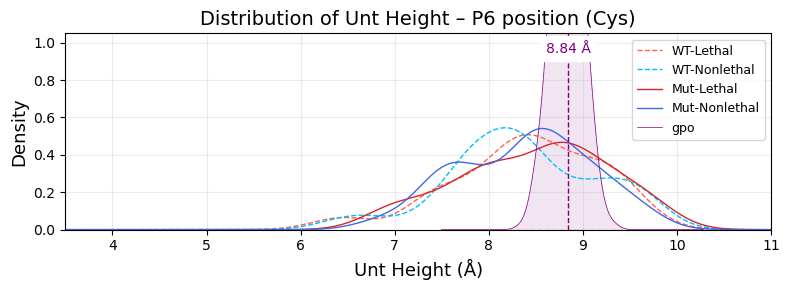

JSD (WT-L vs WT-N): 0.2193
JSD (MUT-L vs WT-L): 0.2276
JSD (MUT-N vs WT-N): 0.2341
WT_L → number of peaks: 3
  Peak 1: 5.8308 Å, height=0.0658
  Peak 2: 6.6203 Å, height=0.0678
  Peak 3: 8.0113 Å, height=0.5789
WT_N → number of peaks: 2
  Peak 1: 8.0865 Å, height=0.3955
  Peak 2: 9.4023 Å, height=0.2864
MUT_L → number of peaks: 1
  Peak 1: 8.0301 Å, height=0.6207
MUT_N → number of peaks: 1
  Peak 1: 7.9737 Å, height=0.3312

Position P3 (Unt Height) Standard Deviations:
Standard deviation for WT_L: 0.7677 Å
Standard deviation for WT_N: 0.9471 Å
Standard deviation for MUT_L: 0.7894 Å
Standard deviation for MUT_N: 1.0173 Å
L_△std (Normalized SD difference): 0.0284
N_△std (Normalized SD difference): 0.0741
(WT_L-WT_N)std (Normalized SD difference): -0.1795


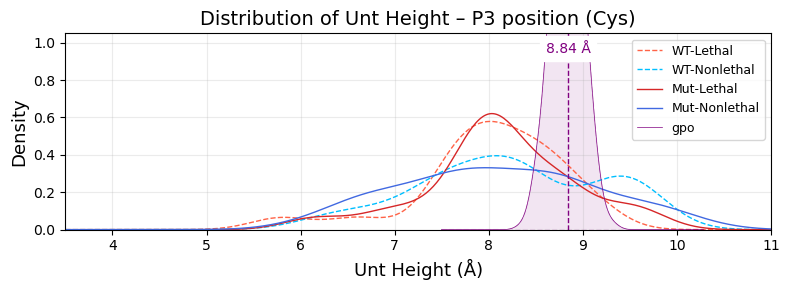

JSD (WT-L vs WT-N): 0.4274
JSD (MUT-L vs WT-L): 0.2391
JSD (MUT-N vs WT-N): 0.3297
WT_L → number of peaks: 1
  Peak 1: 8.2556 Å, height=0.5548
WT_N → number of peaks: 3
  Peak 1: 6.0376 Å, height=0.0596
  Peak 2: 8.4060 Å, height=0.3992
  Peak 3: 9.0075 Å, height=0.4261
MUT_L → number of peaks: 2
  Peak 1: 7.5414 Å, height=0.3573
  Peak 2: 8.8383 Å, height=0.6081
MUT_N → number of peaks: 1
  Peak 1: 9.2143 Å, height=0.4691

Position M0 (Unt Height) Standard Deviations:
Standard deviation for WT_L: 0.7783 Å
Standard deviation for WT_N: 0.9294 Å
Standard deviation for MUT_L: 0.7428 Å
Standard deviation for MUT_N: 0.8861 Å
L_△std (Normalized SD difference): -0.0456
N_△std (Normalized SD difference): -0.0466
(WT_L-WT_N)std (Normalized SD difference): -0.1511


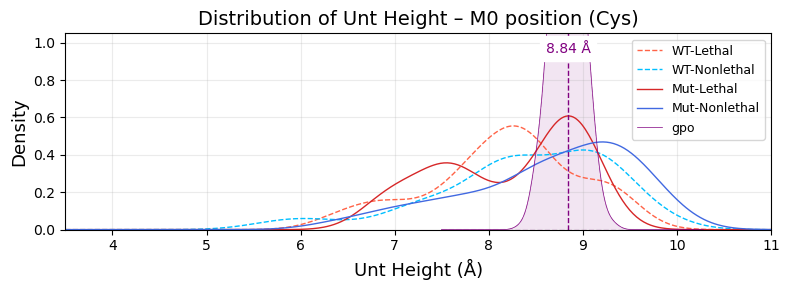

JSD (WT-L vs WT-N): 0.3568
JSD (MUT-L vs WT-L): 0.2467
JSD (MUT-N vs WT-N): 0.2754
WT_L → number of peaks: 2
  Peak 1: 7.3158 Å, height=0.1729
  Peak 2: 8.7632 Å, height=0.6025
WT_N → number of peaks: 2
  Peak 1: 5.7932 Å, height=0.0410
  Peak 2: 8.3872 Å, height=0.5405
MUT_L → number of peaks: 2
  Peak 1: 6.9211 Å, height=0.0904
  Peak 2: 8.7444 Å, height=0.9553
MUT_N → number of peaks: 2
  Peak 1: 4.4023 Å, height=0.0362
  Peak 2: 8.6880 Å, height=0.6503

Position P3′ (Unt Height) Standard Deviations:
Standard deviation for WT_L: 0.7514 Å
Standard deviation for WT_N: 0.7796 Å
Standard deviation for MUT_L: 0.5378 Å
Standard deviation for MUT_N: 0.8752 Å
L_△std (Normalized SD difference): -0.2843
N_△std (Normalized SD difference): 0.1226
(WT_L-WT_N)std (Normalized SD difference): -0.0282


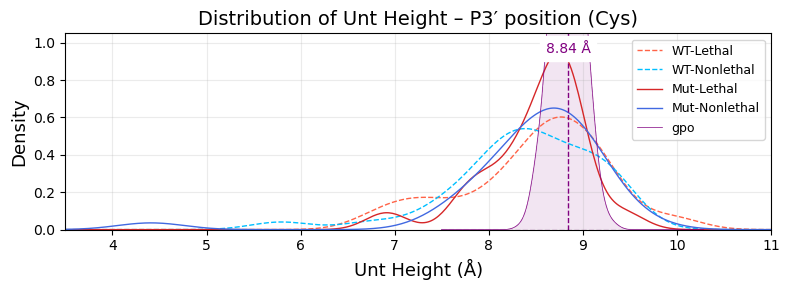

JSD (WT-L vs WT-N): 0.3098
JSD (MUT-L vs WT-L): 0.3115
JSD (MUT-N vs WT-N): 0.2594
WT_L → number of peaks: 2
  Peak 1: 6.6391 Å, height=0.1324
  Peak 2: 8.6504 Å, height=0.5042
WT_N → number of peaks: 1
  Peak 1: 8.2368 Å, height=0.5085
MUT_L → number of peaks: 2
  Peak 1: 6.8835 Å, height=0.1294
  Peak 2: 8.9135 Å, height=0.7114
MUT_N → number of peaks: 3
  Peak 1: 6.8647 Å, height=0.0525
  Peak 2: 8.2744 Å, height=0.6554
  Peak 3: 9.2331 Å, height=0.4717

Position P6′ (Unt Height) Standard Deviations:
Standard deviation for WT_L: 0.9031 Å
Standard deviation for WT_N: 0.6708 Å
Standard deviation for MUT_L: 0.6942 Å
Standard deviation for MUT_N: 0.6024 Å
L_△std (Normalized SD difference): -0.2314
N_△std (Normalized SD difference): -0.1020
(WT_L-WT_N)std (Normalized SD difference): 0.2323


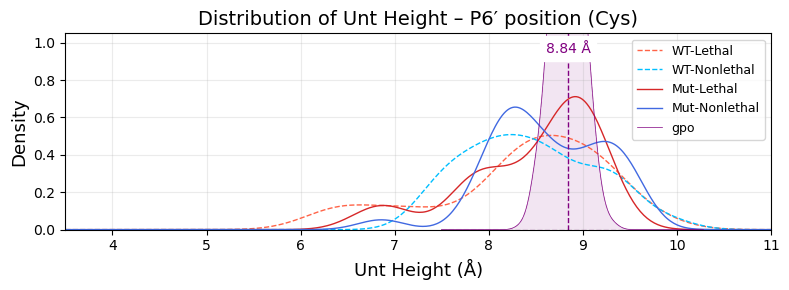

JSD (WT-L vs WT-N): 0.2655
JSD (MUT-L vs WT-L): 0.3035
JSD (MUT-N vs WT-N): 0.2973
WT_L → number of peaks: 2
  Peak 1: 8.1992 Å, height=0.5644
  Peak 2: 9.1955 Å, height=0.5836
WT_N → number of peaks: 1
  Peak 1: 8.9511 Å, height=0.4968
MUT_L → number of peaks: 2
  Peak 1: 8.2180 Å, height=0.6254
  Peak 2: 8.7632 Å, height=0.7086
MUT_N → number of peaks: 2
  Peak 1: 6.1504 Å, height=0.0427
  Peak 2: 8.8947 Å, height=0.5380

Position P9′ (Unt Height) Standard Deviations:
Standard deviation for WT_L: 0.5684 Å
Standard deviation for WT_N: 0.7085 Å
Standard deviation for MUT_L: 0.5093 Å
Standard deviation for MUT_N: 0.7453 Å
L_△std (Normalized SD difference): -0.1039
N_△std (Normalized SD difference): 0.0520
(WT_L-WT_N)std (Normalized SD difference): -0.1401


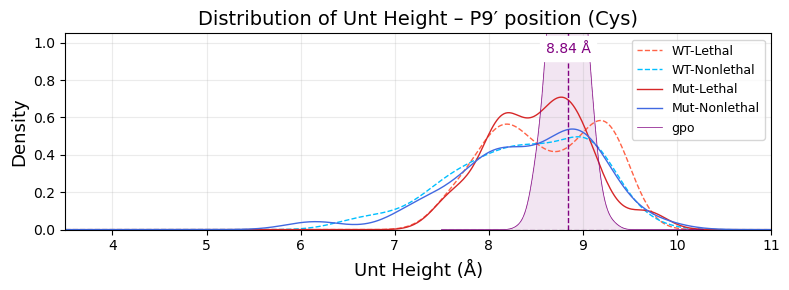

JSD (WT-L vs WT-N): 0.2924
JSD (MUT-L vs WT-L): 0.3115
JSD (MUT-N vs WT-N): 0.2458
WT_L → number of peaks: 1
  Peak 1: 8.7444 Å, height=0.6709
WT_N → number of peaks: 2
  Peak 1: 7.5789 Å, height=0.4781
  Peak 2: 8.5188 Å, height=0.6737
MUT_L → number of peaks: 3
  Peak 1: 8.1429 Å, height=0.5965
  Peak 2: 8.7632 Å, height=0.6397
  Peak 3: 9.3271 Å, height=0.4529
MUT_N → number of peaks: 1
  Peak 1: 8.2744 Å, height=0.7014

Position P12′ (Unt Height) Standard Deviations:
Standard deviation for WT_L: 0.6776 Å
Standard deviation for WT_N: 0.5857 Å
Standard deviation for MUT_L: 0.5239 Å
Standard deviation for MUT_N: 0.6065 Å
L_△std (Normalized SD difference): -0.2267
N_△std (Normalized SD difference): 0.0355
(WT_L-WT_N)std (Normalized SD difference): 0.0919


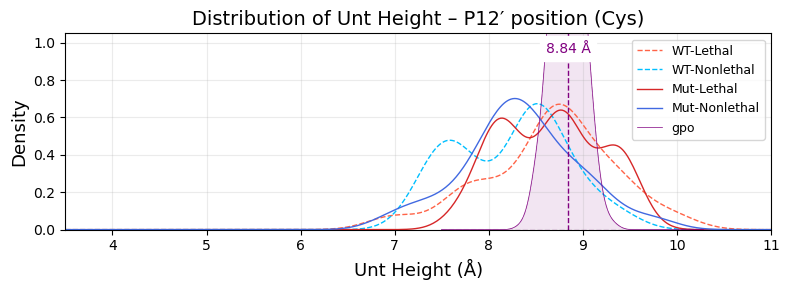

JSD (WT-L vs WT-N): 0.2090
JSD (MUT-L vs WT-L): 0.2959
JSD (MUT-N vs WT-N): 0.1804


In [60]:
# ------------------------------------------------------------
#Wt/Mut9pos各自分布圖-avg
from scipy.spatial import distance

def jsd_from_samples(p_samples, q_samples, bins=20, range_=None, base=2, eps=1e-12):
    """
    計算 Jensen-Shannon Divergence (JSD)
    """
    p_samples = np.asarray(p_samples, dtype=float)
    q_samples = np.asarray(q_samples, dtype=float)

    if range_ is None:
        min_val = min(p_samples.min(), q_samples.min())
        max_val = max(p_samples.max(), q_samples.max())
        range_ = (min_val, max_val)

    p_hist, _ = np.histogram(p_samples, bins=bins, range=range_, density=False)
    q_hist, _ = np.histogram(q_samples, bins=bins, range=range_, density=False)
    p = p_hist / p_hist.sum()
    q = q_hist / q_hist.sum()
    p = np.where(p == 0, eps, p)
    q = np.where(q == 0, eps, q)
    m = 0.5 * (p + q)
    m = np.where(m == 0, eps, m)

    jsd = 0.5 * distance.rel_entr(p, m).sum() + 0.5 * distance.rel_entr(q, m).sum()
    jsd /= np.log(base)
    return np.sqrt(jsd)

def calculate_jsd_for_wt_samples(samples):
    """
    計算 `WT-L vs WT-N`，`MUT-L vs WT-L`，`MUT-N vs WT-N` 的 JSD
    """
    # 計算需要的 JSD
    jsd_wt_l_vs_wt_n = jsd_from_samples(samples[:,0], samples[:,1])
    jsd_mut_l_vs_wt_l = jsd_from_samples(samples[:,2], samples[:,0])
    jsd_mut_n_vs_wt_n = jsd_from_samples(samples[:,3], samples[:,1])

    print(f"JSD (WT-L vs WT-N): {jsd_wt_l_vs_wt_n:.4f}")
    print(f"JSD (MUT-L vs WT-L): {jsd_mut_l_vs_wt_l:.4f}")
    print(f"JSD (MUT-N vs WT-N): {jsd_mut_n_vs_wt_n:.4f}")
    
    return {
        "JSD_WT_L_vs_WT_N": jsd_wt_l_vs_wt_n,
        "JSD_MUT_L_vs_WT_L": jsd_mut_l_vs_wt_l,
        "JSD_MUT_N_vs_WT_N": jsd_mut_n_vs_wt_n
    }

# --- 計算標準差的函數 -------------------------------------------
def calculate_standard_deviation(samples):
    """
    計算每條線段的標準差並返回
    """
    std_devs = {key: np.std(vals) for key, vals in samples.items()}
    
    # 顯示每條線段的標準差
    for key, std_dev in std_devs.items():
        print(f"Standard deviation for {key}: {std_dev:.4f} Å")
    
    return std_devs
# 計算標準化差異指標
def normalized_sd_difference(samples):
    """
    計算 WT_L-MUT_L 和 WT_N-MUT_N 的標準化差異指標：
    (SD(WT) - SD(MUT)) / (max(WT) - min(WT))
    
    samples: dict，包含 'WT_L', 'MUT_L', 'WT_N', 'MUT_N'
    return: dict，包含 L_std 和 N_std 的差異，若 N 不存在則顯示 None
    """
    results = {}

    # L 組
    if samples["WT_L"].size > 0 and samples["MUT_L"].size > 0:
        WT_L = samples["WT_L"]
        MUT_L = samples["MUT_L"]
        sd_WT_L = np.std(WT_L)
        sd_MUT_L = np.std(MUT_L)
        results["L_std"] = (sd_MUT_L - sd_WT_L) / sd_WT_L
        print(f"L_△std (Normalized SD difference): {results['L_std']:.4f}")
    else:
        results["L_std"] = None
        print("No L (lethal) samples, cannot calculate normalized SD difference")

    # N 組
    if "WT_N" in samples and "MUT_N" in samples and samples["WT_N"].size > 0 and samples["MUT_N"].size > 0:
        WT_N = samples["WT_N"]
        MUT_N = samples["MUT_N"]
        sd_WT_N = np.std(WT_N)
        sd_MUT_N = np.std(MUT_N)
        results["N_std"] = (sd_MUT_N - sd_WT_N) / sd_WT_N
        print(f"N_△std (Normalized SD difference): {results['N_std']:.4f}")
    else:
        results["N_std"] = None
        print("No N (non-lethal) samples, cannot calculate normalized SD difference")

    if samples["WT_L"].size > 0 and samples["WT_N"].size > 0:
        WT_L = samples["WT_L"]
        WT_N = samples["WT_N"]
        sd_WT_L = np.std(WT_L)
        sd_WT_N = np.std(WT_N)
        results["WT_L-N_std"] = (sd_WT_L - sd_WT_N)
        print(f"(WT_L-WT_N)std (Normalized SD difference): {results['WT_L-N_std']:.4f}")
    else:
        results["L_std"] = None
        print("No L (lethal) samples, cannot calculate normalized SD difference")

    return results

def plot_kde_onepos_wt_vs_mut(data_mut, data_wt, meta,
                              pos_label="M0",
                              t_title="Unit Height"):
    """
    data_mut : (587, 9)   ← mutant (每條 9 位置平均)
    data_wt  : (587, 9)   ← WT   (對應同 triplet 的 9 位置平均)
    meta     : dict       ← mutation_name / lethal_arr / alpha12_arr
    ------------------------------------------------------------
    只看 Cys，且僅 α1 鏈，拆成 lethal / non-lethal。
    WT 用相同遮罩對應出 WT-Lethal / WT-Nonlethal。
    """
    # --- 位置索引 ---------------------------------------------------
    pos_labels_all = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]
    idx = pos_labels_all.index(pos_label)      # 0–8

    # --- 轉 ndarray & 篩 Cys ----------------------------------------
    mut_name = np.asarray(meta["mutation_name"], dtype=str)
    lethal   = np.asarray(meta["lethal_arr"])
    alpha12  = np.asarray(meta["alpha12_arr"])

    is_cys        = mut_name == "CYS"
    mut_cys       = data_mut[is_cys]
    wt_cys        = data_wt[is_cys]
    leth_cys      = lethal[is_cys]
    a12_cys       = alpha12[is_cys]

    mask_lethal     = (a12_cys == 1) & (leth_cys == 0)
    mask_nonlethal  = (a12_cys == 1) & (leth_cys == 1)

    # --- 收集樣本 ---------------------------------------------------
    samples = dict(
        WT_L   = wt_cys[mask_lethal,    idx],
        WT_N   = wt_cys[mask_nonlethal, idx],
        MUT_L  = mut_cys[mask_lethal,    idx],
        MUT_N  = mut_cys[mask_nonlethal, idx],
    )

    # --- KDE & 繪圖 -------------------------------------------------
    # 自己取共同 x 範圍
    xs = np.linspace(3.5, 11, 400)

    plt.figure(figsize=(8,3))

    style = dict(
        WT_L  = dict(color='tomato',   ls='--', lw=1, label='WT-Lethal'),
        WT_N  = dict(color='deepskyblue', ls='--', lw=1, label='WT-Nonlethal'),
        MUT_L = dict(color='#d62728', lw=1, label='Mut-Lethal'),
        MUT_N = dict(color='royalblue', lw=1, label='Mut-Nonlethal'),        
        # MUT_L = dict(color='#d62728', lw=1, label='Mut-Lethal'),
        # MUT_N = dict(color='#1f77b4', lw=1, label='Mut-Nonlethal'),
    )

    kde_all = np.zeros((400,4))
    i = 0
    for key, vals in samples.items():
        if vals.size == 0: 
            continue

        kde = gaussian_kde(vals, 0.4)
        y = kde(xs)
        plt.plot(xs, y, **style[key])
        kde_all[:, i] = y
        i += 1

        # --- 找到所有峰 ---
        peaks, properties = find_peaks(y, height=0.001, distance=5)
        num_peaks = len(peaks)
        print(f"{key} → number of peaks: {num_peaks}")

        if num_peaks > 0:
            for j, pk in enumerate(peaks):
                peak_x = xs[pk]
                peak_y = y[pk]
                print(f"  Peak {j+1}: {peak_x:.4f} Å, height={peak_y:.4f}")

    # ----------------------GPO----------------------------------
    combined_vals = gpo_unit_hei_traj[:, 1:].ravel()  # 取出索引 1–8 (即 triplet 2–9)
    # 疊上 combined triplet 2–9 的 KDE
    kde_c = gaussian_kde(combined_vals, bw_method=0.4)
    xs_c  = np.linspace(combined_vals.min()*0.9,
                        combined_vals.max()*1.1, 400)
    ys_c  = kde_c(xs_c)
    plt.plot(xs_c, ys_c, color="purple", lw=0.5, label="gpo")
    plt.fill_between(xs_c, ys_c, linestyle='--', color="purple", alpha=0.1)
    # --- 在画完合并 KDE 之后，紧接着加：
    # 计算峰值位置
    peak_idx = np.argmax(ys_c)
    peak_x   = xs_c[peak_idx]
    # 画一条竖线
    plt.axvline(peak_x, color="purple", linestyle="--", linewidth=1)

    plt.text(peak_x, 0.93,        # 固定在 0.42 < 0.45
    f"{peak_x:.2f} Å", 
    color="purple", 
    ha="center", va="bottom",
    fontsize=10,
    backgroundcolor="white")

    print(f"\nPosition {pos_label} ({t_title}) Standard Deviations:")       
    std_devs = calculate_standard_deviation(samples)
    norm_diff = normalized_sd_difference(samples)
    # ----------------------GPO----------------------------------

    # 垂直參考線
    # plt.axvline(8.923, color='red', ls=':', lw=1.0, label='GRO')

    # 軸 & 標題
    plt.xlabel(f"{t_title} (Å)", fontsize=13)
    plt.ylabel("Density",        fontsize=13)
    plt.xlim(3.5, 11)
    plt.ylim(0, 1.05)
    plt.title(f"Distribution of {t_title} – {pos_label} position (Cys)", fontsize=14)
    plt.legend(fontsize=9)
    plt.grid(True, alpha=.25)
    plt.tight_layout()
    plt.show()
    return kde_all
# ------------------------------------------------------------

# === 呼叫範例 ================================================
meta = {
    "mutation_name": mutation_name_arr,
    "lethal_arr":    lethal_arr,
    "alpha12_arr":   alpha12_arr,
}

pos_labels_all = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]

for lbl in pos_labels_all:
    kde_all = plot_kde_onepos_wt_vs_mut(
        unit_hei_avg,        # mutant 資料
        unit_wt_avg,     # WT 資料
        meta,
        pos_label = lbl,   # 這一圈要畫的位置
        t_title   = "Unt Height"
    )
    calculate_jsd_for_wt_samples(kde_all)
    # print(kde_all.shape)

#### KDE-std

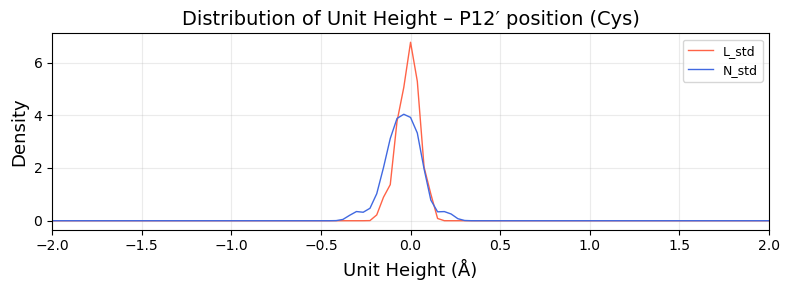

JSD (L vs N): 0.2563


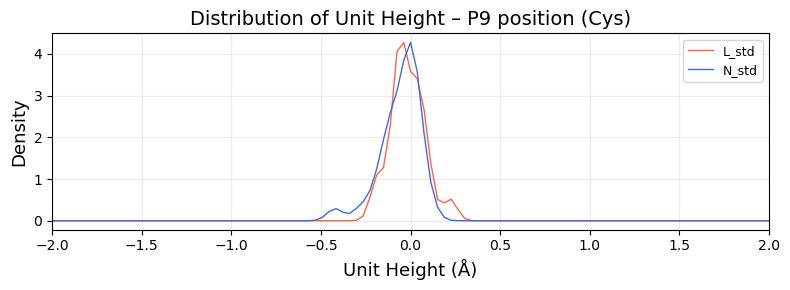

JSD (L vs N): 0.2468


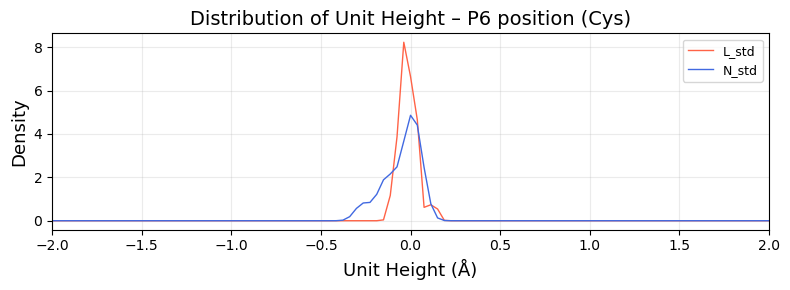

JSD (L vs N): 0.2085


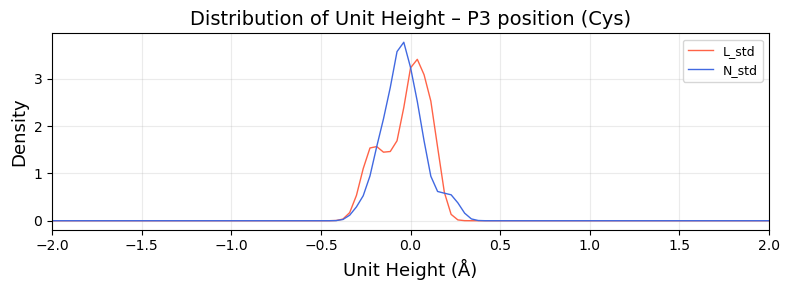

JSD (L vs N): 0.2267


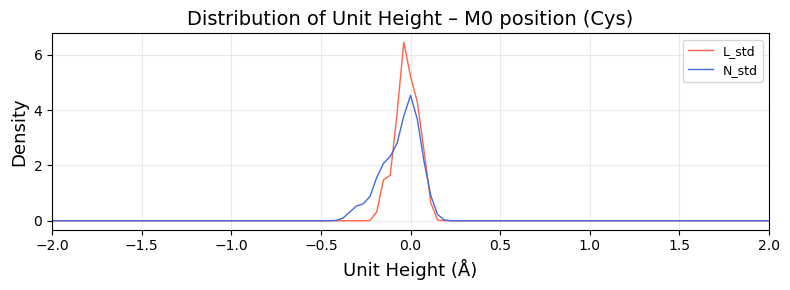

JSD (L vs N): 0.2220


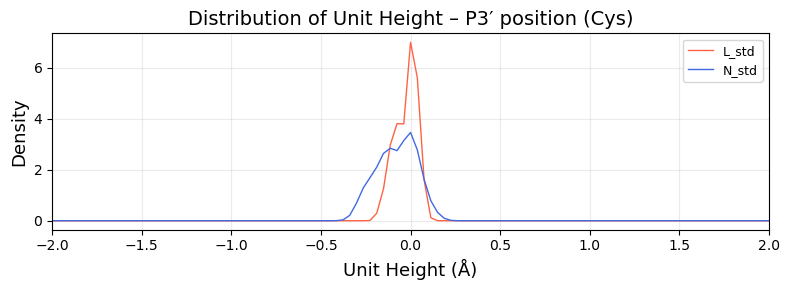

JSD (L vs N): 0.2326


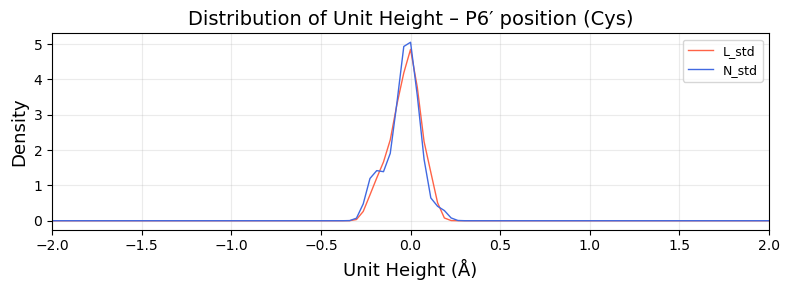

JSD (L vs N): 0.1602


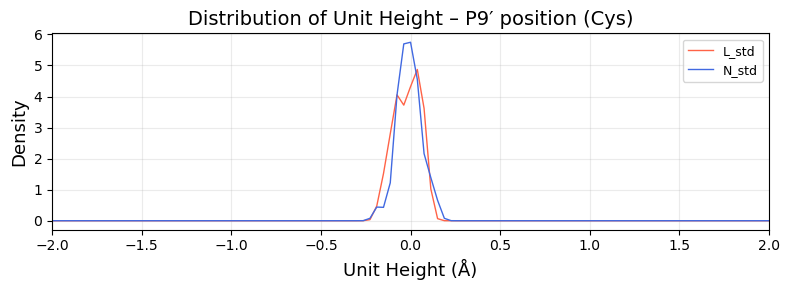

JSD (L vs N): 0.2392


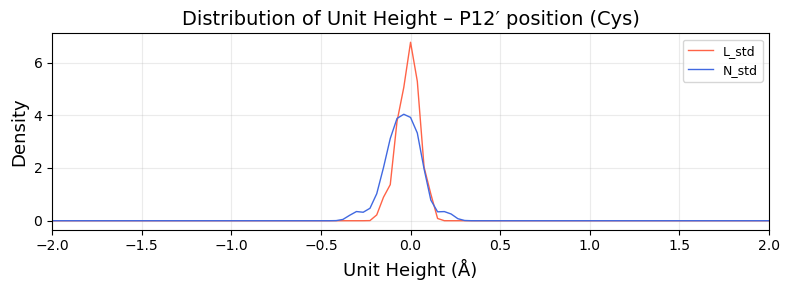

JSD (L vs N): 0.2563


In [101]:
# ------------------------------------------------------------
#Wt/Mut9pos各自分布圖-avg
from scipy.spatial import distance

def jsd_from_samples(p_samples, q_samples, bins=20, range_=None, base=2, eps=1e-12):
    """
    計算 Jensen-Shannon Divergence (JSD)
    """
    p_samples = np.asarray(p_samples, dtype=float)
    q_samples = np.asarray(q_samples, dtype=float)

    if range_ is None:
        min_val = min(p_samples.min(), q_samples.min())
        max_val = max(p_samples.max(), q_samples.max())
        range_ = (min_val, max_val)

    p_hist, _ = np.histogram(p_samples, bins=bins, range=range_, density=False)
    q_hist, _ = np.histogram(q_samples, bins=bins, range=range_, density=False)
    p = p_hist / p_hist.sum()
    q = q_hist / q_hist.sum()
    p = np.where(p == 0, eps, p)
    q = np.where(q == 0, eps, q)
    m = 0.5 * (p + q)
    m = np.where(m == 0, eps, m)

    jsd = 0.5 * distance.rel_entr(p, m).sum() + 0.5 * distance.rel_entr(q, m).sum()
    jsd /= np.log(base)
    return np.sqrt(jsd)

def calculate_jsd_for_wt_samples(samples):
    """
    計算 `WT-L vs WT-N`，`MUT-L vs WT-L`，`MUT-N vs WT-N` 的 JSD
    """
    # 計算需要的 JSD
    jsd_wt_l_vs_wt_n = jsd_from_samples(samples[:,0], samples[:,1])

    print(f"JSD (L vs N): {jsd_wt_l_vs_wt_n:.4f}")

    return {
        "JSD_WT_L_vs_WT_N": jsd_wt_l_vs_wt_n,
    }

def plot_kde_onepos_wt_vs_mut(data_mut, data_wt, meta,
                              pos_label="M0", t_title="Unit Height"):
    """
    data_mut : (587, 9)   ← mutant (每條 9 位置平均)
    data_wt  : (587, 9)   ← WT   (對應同 triplet 的 9 位置平均)
    meta     : dict       ← mutation_name / lethal_arr / alpha12_arr
    ------------------------------------------------------------
    只看 Cys，且僅 α1 鏈，拆成 lethal / non-lethal。
    WT 用相同遮罩對應出 WT-Lethal / WT-Nonlethal。
    """
    # --- 位置索引 ---------------------------------------------------
    pos_labels_all = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]
    idx = pos_labels_all.index(pos_label)  # 0–8

    # --- 轉 ndarray & 篩 Cys ----------------------------------------
    mut_name = np.asarray(meta["mutation_name"], dtype=str)
    lethal   = np.asarray(meta["lethal_arr"])
    alpha12  = np.asarray(meta["alpha12_arr"])

    is_cys        = mut_name == "CYS"
    mut_cys       = data_mut[is_cys]
    wt_cys        = data_wt[is_cys]
    leth_cys      = lethal[is_cys]
    a12_cys       = alpha12[is_cys]

    mask_lethal     = (a12_cys == 1) & (leth_cys == 0)
    mask_nonlethal  = (a12_cys == 1) & (leth_cys == 1)

    # --- 收集樣本 ---------------------------------------------------
    # 計算 L_std 和 N_std，這裡我們計算 MUT_L - WT_L 和 MUT_N - WT_N
    samples = dict(
        L_std = mut_cys[mask_lethal, idx] - wt_cys[mask_lethal, idx],  # MUT_L - WT_L
        N_std = mut_cys[mask_nonlethal, idx] - wt_cys[mask_nonlethal, idx]  # MUT_N - WT_N
    )

    # --- KDE & 繪圖 -------------------------------------------------
    # 自己取共同 x 範圍
    xs = np.linspace(-2, 2, 107)

    plt.figure(figsize=(8, 3))

    style = dict(
        L_std = dict(color='tomato',   lw=1, label='L_std'),
        N_std = dict(color='royalblue', lw=1, label='N_std')
    )

    kde_all = np.zeros((107, 2))  # 只有兩條線，L_std 和 N_std
    i = 0
    for key, vals in samples.items():
        if vals.size == 0:
            continue
        kde = gaussian_kde(vals, 0.4)
        plt.plot(xs, kde(xs), **style[key])
        kde_all[:, i] = kde(xs)
        i += 1



    # 軸 & 標題
    plt.xlabel(f"{t_title} (Å)", fontsize=13)
    plt.ylabel("Density", fontsize=13)
    plt.xlim(-2, 2)
    # plt.ylim(0, 1.05)
    plt.title(f"Distribution of {t_title} – {pos_label} position (Cys)", fontsize=14)
    plt.legend(fontsize=9)
    plt.grid(True, alpha=.25)
    plt.tight_layout()
    plt.show()

    # 返回 kde_all（包含兩條線的 KDE）
    return kde_all

# ------------------------------------------------------------

# === 呼叫範例 ================================================
meta = {
    "mutation_name": mutation_name_arr,
    "lethal_arr":    lethal_arr,
    "alpha12_arr":   alpha12_arr,
}

pos_labels_all = ["P12′","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]

for lbl in pos_labels_all:
    kde_all = plot_kde_onepos_wt_vs_mut(
        unit_hei_std,  # mutant 資料
        unit_wt_std,   # WT 資料
        meta,
        pos_label=lbl,
        t_title="Unit Height"
    )
    calculate_jsd_for_wt_samples(kde_all)


#### CDF

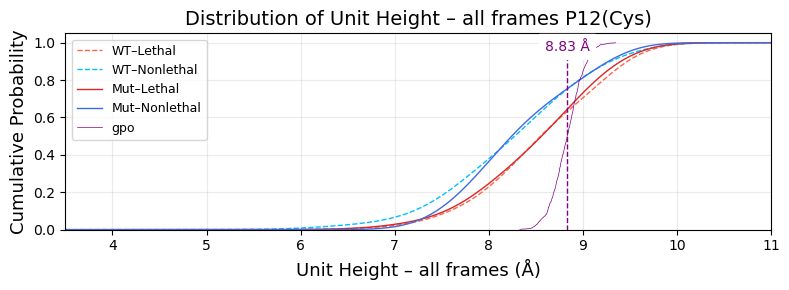

[P12] JSD (WT-L vs WT-N): 0.0617
[P12] JSD (MUT-L vs WT-L): 0.0337
[P12] JSD (MUT-N vs WT-N): 0.0796

 [CDF ΔY 最大差異點] P12:
  WT-L vs WT-N   → x = 8.0301 Å, ΔY = -0.1503
  MUT-L vs WT-L  → x = 9.1767 Å, ΔY = 0.0329
  MUT-N vs WT-N  → x = 7.3910 Å, ΔY = -0.0638


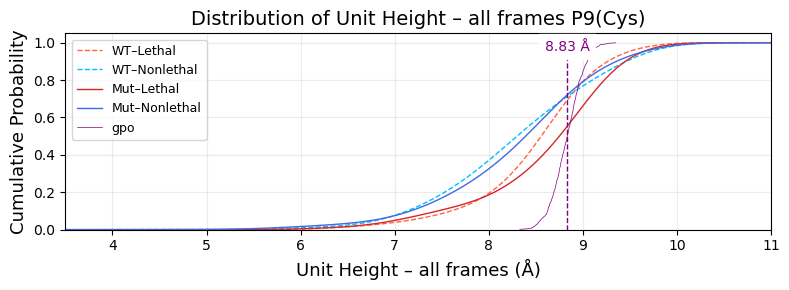

[P9] JSD (WT-L vs WT-N): 0.1064
[P9] JSD (MUT-L vs WT-L): 0.0626
[P9] JSD (MUT-N vs WT-N): 0.0480

 [CDF ΔY 最大差異點] P9:
  WT-L vs WT-N   → x = 8.1053 Å, ΔY = -0.1806
  MUT-L vs WT-L  → x = 8.8383 Å, ΔY = -0.1401
  MUT-N vs WT-N  → x = 8.1429 Å, ΔY = -0.0483


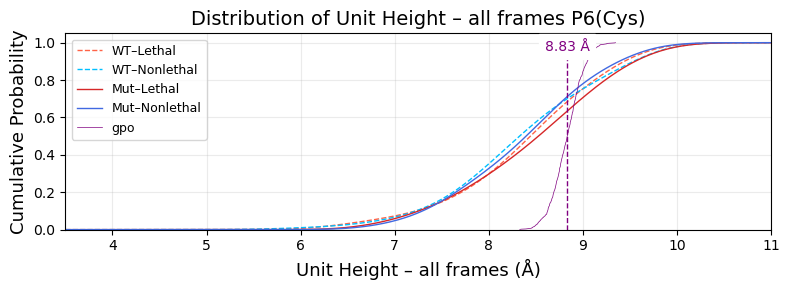

[P6] JSD (WT-L vs WT-N): 0.0528
[P6] JSD (MUT-L vs WT-L): 0.0551
[P6] JSD (MUT-N vs WT-N): 0.0602

 [CDF ΔY 最大差異點] P6:
  WT-L vs WT-N   → x = 8.1992 Å, ΔY = -0.0588
  MUT-L vs WT-L  → x = 8.8008 Å, ΔY = -0.0503
  MUT-N vs WT-N  → x = 9.3083 Å, ΔY = 0.0397


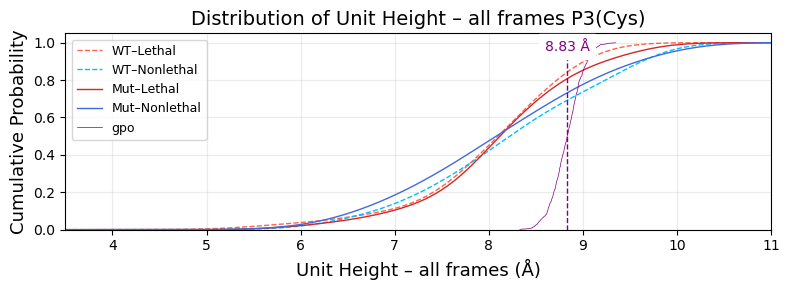

[P3] JSD (WT-L vs WT-N): 0.1374
[P3] JSD (MUT-L vs WT-L): 0.0778
[P3] JSD (MUT-N vs WT-N): 0.0458

 [CDF ΔY 最大差異點] P3:
  WT-L vs WT-N   → x = 9.0451 Å, ΔY = 0.1605
  MUT-L vs WT-L  → x = 9.2331 Å, ΔY = -0.0500
  MUT-N vs WT-N  → x = 7.6353 Å, ΔY = 0.0569


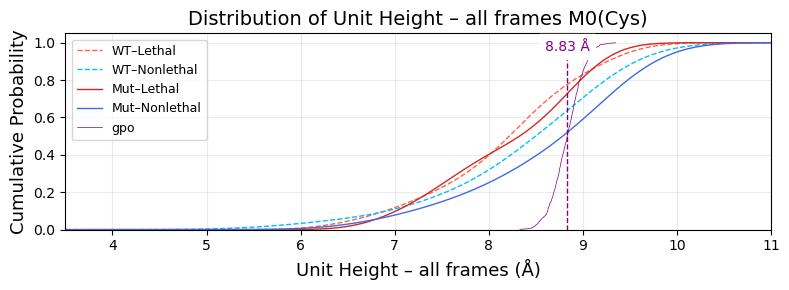

[M0] JSD (WT-L vs WT-N): 0.0845
[M0] JSD (MUT-L vs WT-L): 0.0927
[M0] JSD (MUT-N vs WT-N): 0.0649

 [CDF ΔY 最大差異點] M0:
  WT-L vs WT-N   → x = 8.6692 Å, ΔY = 0.1449
  MUT-L vs WT-L  → x = 8.5752 Å, ΔY = -0.0757
  MUT-N vs WT-N  → x = 8.8571 Å, ΔY = -0.1176


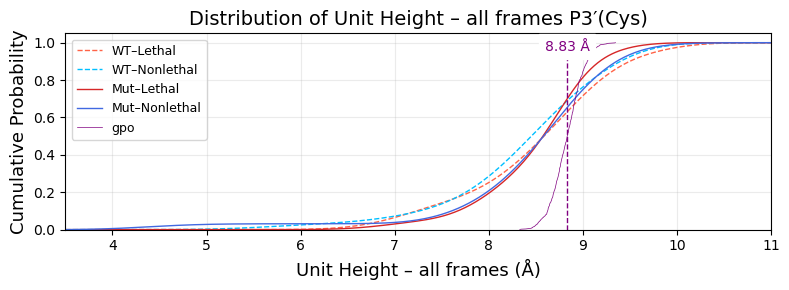

[P3′] JSD (WT-L vs WT-N): 0.0725
[P3′] JSD (MUT-L vs WT-L): 0.1138
[P3′] JSD (MUT-N vs WT-N): 0.0779

 [CDF ΔY 最大差異點] P3′:
  WT-L vs WT-N   → x = 8.5564 Å, ΔY = -0.0692
  MUT-L vs WT-L  → x = 9.1203 Å, ΔY = 0.1045
  MUT-N vs WT-N  → x = 8.2368 Å, ΔY = -0.0833


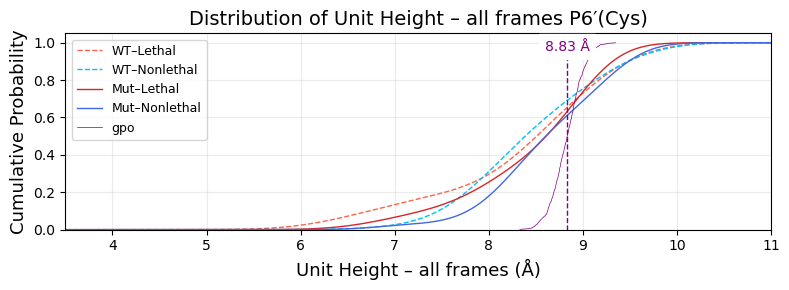

[P6′] JSD (WT-L vs WT-N): 0.1619
[P6′] JSD (MUT-L vs WT-L): 0.1078
[P6′] JSD (MUT-N vs WT-N): 0.0612

 [CDF ΔY 最大差異點] P6′:
  WT-L vs WT-N   → x = 7.1466 Å, ΔY = 0.1103
  MUT-L vs WT-L  → x = 7.1654 Å, ΔY = -0.0685
  MUT-N vs WT-N  → x = 8.0865 Å, ΔY = -0.1334


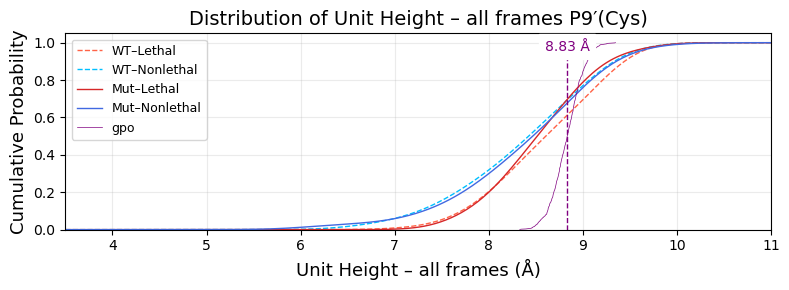

[P9′] JSD (WT-L vs WT-N): 0.0758
[P9′] JSD (MUT-L vs WT-L): 0.0492
[P9′] JSD (MUT-N vs WT-N): 0.0337

 [CDF ΔY 最大差異點] P9′:
  WT-L vs WT-N   → x = 7.8421 Å, ΔY = -0.1198
  MUT-L vs WT-L  → x = 9.0075 Å, ΔY = 0.0941
  MUT-N vs WT-N  → x = 7.8233 Å, ΔY = -0.0208


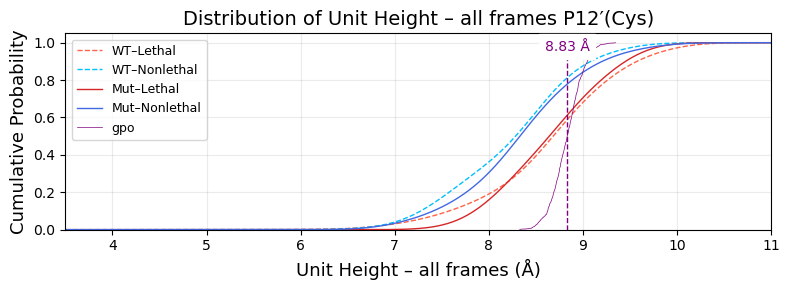

[P12′] JSD (WT-L vs WT-N): 0.0970
[P12′] JSD (MUT-L vs WT-L): 0.0987
[P12′] JSD (MUT-N vs WT-N): 0.0545

 [CDF ΔY 最大差異點] P12′:
  WT-L vs WT-N   → x = 8.6128 Å, ΔY = -0.2392
  MUT-L vs WT-L  → x = 7.5977 Å, ΔY = -0.0646
  MUT-N vs WT-N  → x = 7.7857 Å, ΔY = -0.0682


In [86]:
from scipy.spatial import distance
from scipy import integrate
def jsd_from_samples(p_samples, q_samples, bins=20, range_=None, base=2, eps=1e-12):
    """
    計算 Jensen-Shannon Divergence (JSD)
    """
    p_samples = np.asarray(p_samples, dtype=float)
    q_samples = np.asarray(q_samples, dtype=float)

    if range_ is None:
        min_val = min(p_samples.min(), q_samples.min())
        max_val = max(p_samples.max(), q_samples.max())
        range_ = (min_val, max_val)

    p_hist, _ = np.histogram(p_samples, bins=bins, range=range_, density=False)
    q_hist, _ = np.histogram(q_samples, bins=bins, range=range_, density=False)
    p = p_hist / p_hist.sum()
    q = q_hist / q_hist.sum()
    p = np.where(p == 0, eps, p)
    q = np.where(q == 0, eps, q)
    m = 0.5 * (p + q)
    m = np.where(m == 0, eps, m)

    jsd = 0.5 * distance.rel_entr(p, m).sum() + 0.5 * distance.rel_entr(q, m).sum()
    jsd /= np.log(base)
    return np.sqrt(jsd)

bar_results = {
    "WT-L vs WT-N": {"signed": [], "abs": []},
    "MUT-L vs WT-L": {"signed": [], "abs": []},
    "MUT-N vs WT-N": {"signed": [], "abs": []},
}

def calculate_jsd_for_wt_samples(samples, pos_label="M0", save_dir="./jsd_plots/CYS"):
    # 用於收集所有位置的積分結果

    pos_labels_all = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]


    os.makedirs(save_dir, exist_ok=True)
    # ====== 三組 JSD ======
    jsd_wt_l_vs_wt_n = jsd_from_samples(samples[:,0], samples[:,1])
    jsd_mut_l_vs_wt_l = jsd_from_samples(samples[:,2], samples[:,0])
    jsd_mut_n_vs_wt_n = jsd_from_samples(samples[:,3], samples[:,1])

    print(f"[{pos_label}] JSD (WT-L vs WT-N): {jsd_wt_l_vs_wt_n:.4f}")
    print(f"[{pos_label}] JSD (MUT-L vs WT-L): {jsd_mut_l_vs_wt_l:.4f}")
    print(f"[{pos_label}] JSD (MUT-N vs WT-N): {jsd_mut_n_vs_wt_n:.4f}")

    # ====== 三組比較繪圖 ======
    pairs = [
        ("WT-L vs WT-N", samples[:,0], samples[:,1], jsd_wt_l_vs_wt_n, "Cumulative ∫(L - N) dx", "Cumulative ∫|L - N| dx"),
        ("MUT-L vs WT-L", samples[:,2], samples[:,0], jsd_mut_l_vs_wt_l, "Cumulative ∫(MUT - WT) dx", "Cumulative ∫|MUT - WT| dx"),
        ("MUT-N vs WT-N", samples[:,3], samples[:,1], jsd_mut_n_vs_wt_n, "Cumulative ∫(MUT - WT) dx", "Cumulative ∫|MUT - WT| dx"),
    ]

    final_values = {}
    # 累積積分曲線（cumulative integral curve）> 隨著 x 累積面積變化的曲線
    for title, L, N, jsd_val, ylabelsign, ylabelabs in pairs:
        # 積分仍在索引空間進行
        x_idx = np.linspace(0, len(L)-1, len(L))
        diff = L - N
        # === 有號積分 ===
        cum_area_signed = integrate.cumulative_trapezoid(diff, x_idx, initial=0)
        final_signed = cum_area_signed[-1]
        # === 絕對值積分 ===
        cum_area_abs = integrate.cumulative_trapezoid(np.abs(diff), x_idx, initial=0)
        final_abs = cum_area_abs[-1]
        # 紀錄結果
        final_values[title] = {"signed": final_signed, "abs": final_abs}

        # 畫圖
        plt.figure(figsize=(8,3))
        plt.plot(x_idx, cum_area_signed, color="deeppink", lw=1, label=ylabelsign)
        plt.plot(x_idx, cum_area_abs, color="orange", lw=1, label=ylabelabs)
        plt.legend(fontsize=10)
        plt.axhline(0, color="gray", linestyle="--", lw=1)
        plt.xlabel("x (Å)", fontsize=13)
        plt.ylabel("Cumulative ∫ f(x) dx", fontsize=15)
        plt.ylim(-25, 25)

        # 🔹設定 x 軸刻度對應真實範圍 (3.5–11)，且不超出
        tick_label = np.arange(4, 12, 1)                     # 4,5,6,7,8,9,10,11
        tick_label = tick_label[tick_label <= 11]            # 確保不超出 11
        tick_pos = (tick_label - 3.5) / (11 - 3.5) * (len(L) - 1)
        plt.xticks(tick_pos, tick_label)
        # 限制 X 軸範圍
        plt.xlim(0, len(L)-1)

        plt.title(f"{title} – {pos_label}\nJSD = {jsd_val:.4f}")
        plt.text(
            0.98, 0.95,
            f"Final = {final_signed:.4f}\n|Final| = {final_abs:.4f}",
            transform=plt.gca().transAxes,
            color="black", fontsize=12,
            ha="right", va="top"
        )

        plt.grid(True, alpha=0.25)
        plt.tight_layout()

        # 檔名處理：避免特殊符號
        safe_title = title.replace(" ", "_").replace("–", "-").replace("/", "-")
        filename = f"{safe_title}_{pos_label}.png"
        save_path = os.path.join(save_dir, filename)

        plt.savefig(save_path, dpi=300)
        plt.close()
        results_per_pair = {
            title: {"signed": final_signed, "abs": final_abs}
        }

    return {
        "JSD_WT_L_vs_WT_N": jsd_wt_l_vs_wt_n,
        "JSD_MUT_L_vs_WT_L": jsd_mut_l_vs_wt_l,
        "JSD_MUT_N_vs_WT_N": jsd_mut_n_vs_wt_n,
        "final_values": final_values
    }

def plot_cdf_onepos_wt_vs_mut(
    data_mut, data_wt, meta,
    pos_label="M0",
    t_title="Unit Height",
    xlim=None, ylim=(0, 1.05)
):
    """
    data_mut : (N, 9) 或 (N, T, 9) ← mutant（每條 9 位置；或含 T 個時間步）
    data_wt  : (N, 9) 或 (N, T, 9) ← WT
    meta     : dict ← mutation_name(_arr) / lethal_arr / alpha12_arr（長度 N）
               若 data_* 是 3D，會自動 repeat 以對齊攤平後樣本數
    僅取 Cys、α1，並拆成 Lethal / Nonlethal；WT 用相同遮罩。
    """

    # --- 位置索引 ---------------------------------------------------
    pos_labels_all = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]
    if pos_label not in pos_labels_all:
        raise ValueError(f"pos_label 必須是 {pos_labels_all} 之一")
    idx = pos_labels_all.index(pos_label)

    # --- 取得 meta 欄位 ---------------------------------------------
    def _get(meta, base):
        if base in meta: return np.asarray(meta[base])
        if f"{base}_arr" in meta: return np.asarray(meta[f"{base}_arr"])
        raise KeyError(f"meta 缺少：{base} 或 {base}_arr")

    mut_name = _get(meta, "mutation_name").astype(str)
    lethal   = _get(meta, "lethal")
    alpha12  = _get(meta, "alpha12")

    # --- 攤平資料 & 同步 repeat meta -------------------------------
    def _flatten_and_repeat(data, mut_name, lethal, alpha12):
        if data.ndim == 3:
            N, T, P = data.shape
            assert P == 9, f"最後一維應為 9，取得 {P}"
            data2d  = data.reshape(N*T, P)
            return (data2d,
                    np.repeat(mut_name, T),
                    np.repeat(lethal,   T),
                    np.repeat(alpha12,  T))
        elif data.ndim == 2:
            return data, mut_name, lethal, alpha12
        else:
            raise ValueError("data_* 形狀需為 (N,9) 或 (N,T,9)")

    mut2d, mut_name_r, leth_r, a12_r = _flatten_and_repeat(data_mut, mut_name, lethal, alpha12)
    wt2d,  _,           _,     _     = _flatten_and_repeat(data_wt,  mut_name, lethal, alpha12)

    # --- 只取 Cys，僅 α1，拆 lethal / non-lethal -------------------
    is_cys   = (mut_name_r == "CYS")
    mut_cys  = mut2d[is_cys]
    wt_cys   = wt2d[is_cys]
    leth_cys = leth_r[is_cys]
    a12_cys  = a12_r[is_cys]

    mask_lethal    = (a12_cys == 1) & (leth_cys == 0)
    mask_nonlethal = (a12_cys == 1) & (leth_cys == 1)

    # --- 收集樣本 --------------------------------------------------
    samples = dict(
        WT_L   = wt_cys[mask_lethal,    idx],
        WT_N   = wt_cys[mask_nonlethal, idx],
        MUT_L  = mut_cys[mask_lethal,   idx],
        MUT_N  = mut_cys[mask_nonlethal,idx],
    )

    if not any(v.size for v in samples.values()):
        print(f"[警告] {pos_label} 在目前遮罩下沒有樣本可畫。")
        return

    # --- 決定 X 範圍（含 GPO） -------------------------------------
    vals_list = [v for v in samples.values() if v.size]
    all_vals = np.concatenate(vals_list)
    if 'gpo_unit_hei_traj' in globals():
        gpo_vals = gpo_unit_hei_traj[:, 1:].ravel()
        if gpo_vals.size:
            all_vals = np.concatenate([all_vals, gpo_vals])

    if xlim is None:
        x_min, x_max = all_vals.min()*0.9, all_vals.max()*1.1
    else:
        x_min, x_max = xlim

    # --- 繪圖 -------------------------------------------------------
    xs = np.linspace(3.5, 11, 400)
    dx = (11-3.5)/399
    plt.figure(figsize=(8, 3))

    style = dict(
        WT_L  = dict(color='tomato',      ls='--', lw=1, label='WT–Lethal'),
        WT_N  = dict(color='deepskyblue', ls='--', lw=1, label='WT–Nonlethal'),
        MUT_L = dict(color='#d62728',     lw=1,    label='Mut–Lethal'),
        MUT_N = dict(color='royalblue',   lw=1,    label='Mut–Nonlethal'),
    )

    # 畫 ECDF

    kde_all = np.zeros((400,4))
    i = 0
    for key, vals in samples.items():
        if vals.size == 0:
            continue
        kde = gaussian_kde(vals,0.4)
        Y= kde(xs)/(dx*kde(xs)).sum()
        C_kde =np.cumsum(Y*dx)
        # plt.plot(xs, kde(xs), **style[key], alpha = 0.3)
        plt.plot(xs, C_kde, **style[key])
        kde_all[:,i] = C_kde
        i = i + 1   


    # 疊上 gpo（triplet 2–9）— CDF
    if 'gpo_unit_hei_traj' in globals():
        combined_vals = gpo_unit_hei_traj[:, 1:].ravel()
        if combined_vals.size:
            xs_c = np.sort(combined_vals)
            ys_c = np.arange(1, len(xs_c)+1) / len(xs_c)
            plt.plot(xs_c, ys_c, color="purple", lw=0.5, label="gpo")
            # plt.fill_between(xs_c, ys_c, linestyle='--', color="purple", alpha=0.1)

            # 標記中位數
            median_x = np.median(combined_vals)
            plt.axvline(median_x, color="purple", linestyle="--", linewidth=1)
            plt.text(median_x, 0.94,
                     f"{median_x:.2f} Å",
                     color="purple", ha="center", va="bottom",
                     fontsize=10, backgroundcolor="white")

    # 軸 & 標題
    plt.xlabel(f"{t_title} (Å)", fontsize=13)
    plt.ylabel("Cumulative Probability", fontsize=13)
    plt.xlim(3.5, 11)
    plt.ylim(*ylim)
    plt.title(f"Distribution of {t_title} {pos_label}(Cys)", fontsize=14)
    plt.legend(fontsize=9)
    plt.grid(True, alpha=.25)
    plt.tight_layout()
    plt.show()
    return kde_all

for lbl in pos_labels_all:
    kde_all = plot_cdf_onepos_wt_vs_mut(
        unit_hei_all,
        unit_hei_wt,
        meta,
        pos_label=lbl,
        t_title="Unit Height – all frames"
    )
    result = calculate_jsd_for_wt_samples(kde_all, pos_label=lbl)
        # =========================================================
    # 🔹 計算 CDF 差異最大點（ΔY 最大）
    # =========================================================
    if kde_all.shape[1] >= 4:  # 確保四條曲線都有
        xs = np.linspace(3.5, 11, kde_all.shape[0])  # 對應 CDF 的 x 軸

        # 各組差異
        diff_wt_ln   = kde_all[:, 0] - kde_all[:, 1]  # WT-L vs WT-N
        diff_mutl_wtl = kde_all[:, 2] - kde_all[:, 0]  # MUT-L vs WT-L
        diff_mutn_wtn = kde_all[:, 3] - kde_all[:, 1]  # MUT-N vs WT-N

        # 各組差異的最大絕對值位置
        idx_max_wtln  = np.argmax(np.abs(diff_wt_ln))
        idx_max_mutl  = np.argmax(np.abs(diff_mutl_wtl))
        idx_max_mutn  = np.argmax(np.abs(diff_mutn_wtn))

        print(f"\n [CDF ΔY 最大差異點] {lbl}:")
        print(f"  WT-L vs WT-N   → x = {xs[idx_max_wtln]:.4f} Å, ΔY = {diff_wt_ln[idx_max_wtln]:.4f}")
        print(f"  MUT-L vs WT-L  → x = {xs[idx_max_mutl]:.4f} Å, ΔY = {diff_mutl_wtl[idx_max_mutl]:.4f}")
        print(f"  MUT-N vs WT-N  → x = {xs[idx_max_mutn]:.4f} Å, ΔY = {diff_mutn_wtn[idx_max_mutn]:.4f}")

        # 若要畫圖標出，可用以下（選擇性）：
        # plt.axvline(xs[idx_max_wtln],  color="gray", linestyle="--", lw=0.8, alpha=0.6)
        # plt.axvline(xs[idx_max_mutl],  color="red",  linestyle="--", lw=0.8, alpha=0.6)
        # plt.axvline(xs[idx_max_mutn],  color="blue", linestyle="--", lw=0.8, alpha=0.6)


    # 收集積分結果
    for title in bar_results.keys():
        bar_results[title]["signed"].append(result["final_values"][title]["signed"])
        bar_results[title]["abs"].append(result["final_values"][title]["abs"])

##### 畫長條圖

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# X 軸位置
x_labels = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]
x = np.arange(len(x_labels))

for title, data in bar_results.items():
    # --- 有號積分 ---
    plt.figure(figsize=(8,4))
    plt.bar(x, data["signed"], color="deeppink", alpha=0.7)
    plt.xticks(x, x_labels, rotation=45)
    plt.ylabel("Cumulative ∫()dx")
    plt.ylim(-20,20)
    plt.title(f"{title} – Signed Integral")
    plt.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(f"./jsd_plots/CYS/bar_{title.replace(' ','_')}_signed.png", dpi=300)
    plt.close()

    # --- 絕對值積分 ---
    plt.figure(figsize=(8,4))
    plt.bar(x, data["abs"], color="orange", alpha=0.7)
    plt.xticks(x, x_labels, rotation=45)
    plt.ylabel("Cumulative ∫|| dx")
    plt.ylim(-20,20)
    plt.title(f"{title} – Absolute Integral")
    plt.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(f"./jsd_plots/CYS/bar_{title.replace(' ','_')}_abs.png", dpi=300)
    plt.close()


### uh_CYS_mut-wt

#### KDE-avg(mut-wt)

DIFF_L → number of peaks: 2
  Peak 1: -0.2444 Å, density=0.7649
  Peak 2: 0.1504 Å, density=0.8681
DIFF_N → number of peaks: 2
  Peak 1: -0.0564 Å, density=0.7779
  Peak 2: 1.3534 Å, density=0.1375

Position P12 (Unit Height – avg) Standard Deviations:
Standard deviation for DIFF_L: 0.4353 Å
Standard deviation for DIFF_N: 0.5811 Å
(DIFF_L-DIFF_N)std (Normalized SD difference): -0.1459


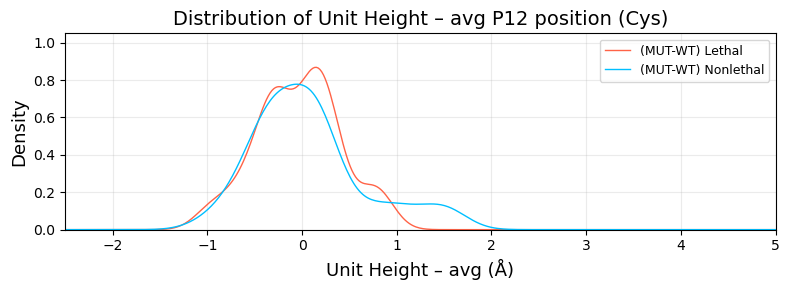

JSD (DIFF-L vs DIFF-N): 0.2379
DIFF_L → number of peaks: 2
  Peak 1: -1.4098 Å, density=0.1092
  Peak 2: 0.2256 Å, density=1.3209
DIFF_N → number of peaks: 1
  Peak 1: -0.1128 Å, density=0.6202

Position P9 (Unit Height – avg) Standard Deviations:
Standard deviation for DIFF_L: 0.4450 Å
Standard deviation for DIFF_N: 0.6014 Å
(DIFF_L-DIFF_N)std (Normalized SD difference): -0.1564


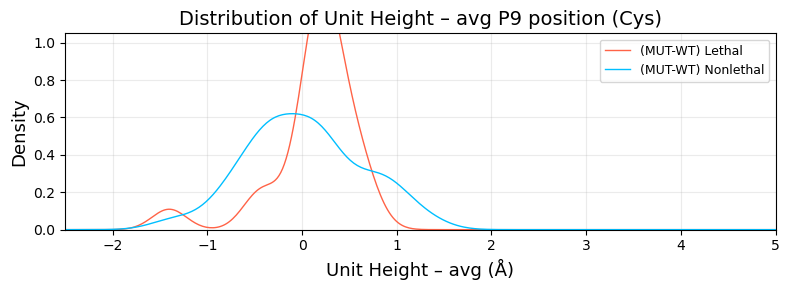

JSD (DIFF-L vs DIFF-N): 0.2933
DIFF_L → number of peaks: 1
  Peak 1: 0.0000 Å, density=1.1412
DIFF_N → number of peaks: 2
  Peak 1: -0.4511 Å, density=0.5353
  Peak 2: 0.1128 Å, density=0.8207

Position P6 (Unit Height – avg) Standard Deviations:
Standard deviation for DIFF_L: 0.3399 Å
Standard deviation for DIFF_N: 0.4948 Å
(DIFF_L-DIFF_N)std (Normalized SD difference): -0.1549


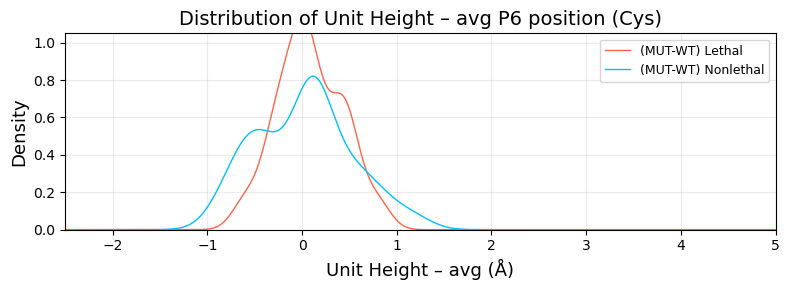

JSD (DIFF-L vs DIFF-N): 0.2355
DIFF_L → number of peaks: 2
  Peak 1: 0.0376 Å, density=0.9862
  Peak 2: 1.0150 Å, density=0.2207
DIFF_N → number of peaks: 2
  Peak 1: -1.2030 Å, density=0.2372
  Peak 2: 0.0752 Å, density=0.6735

Position P3 (Unit Height – avg) Standard Deviations:
Standard deviation for DIFF_L: 0.4448 Å
Standard deviation for DIFF_N: 0.6470 Å
(DIFF_L-DIFF_N)std (Normalized SD difference): -0.2023


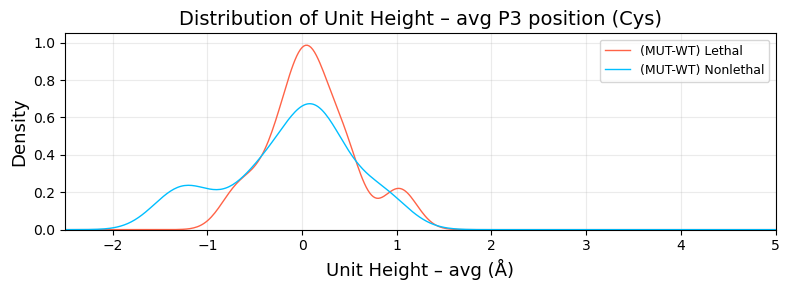

JSD (DIFF-L vs DIFF-N): 0.2607
DIFF_L → number of peaks: 2
  Peak 1: -0.2632 Å, density=0.6064
  Peak 2: 0.4699 Å, density=0.8512
DIFF_N → number of peaks: 1
  Peak 1: 0.2444 Å, density=0.7546

Position M0 (Unit Height – avg) Standard Deviations:
Standard deviation for DIFF_L: 0.4778 Å
Standard deviation for DIFF_N: 0.6421 Å
(DIFF_L-DIFF_N)std (Normalized SD difference): -0.1642


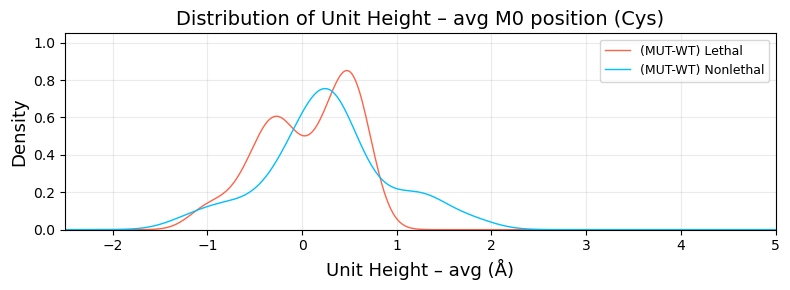

JSD (DIFF-L vs DIFF-N): 0.2737
DIFF_L → number of peaks: 2
  Peak 1: 0.0752 Å, density=0.9449
  Peak 2: 1.6729 Å, density=0.0909
DIFF_N → number of peaks: 3
  Peak 1: -1.3722 Å, density=0.0602
  Peak 2: 0.1316 Å, density=0.9163
  Peak 3: 1.7481 Å, density=0.0595

Position P3′ (Unit Height – avg) Standard Deviations:
Standard deviation for DIFF_L: 0.5348 Å
Standard deviation for DIFF_N: 0.5320 Å
(DIFF_L-DIFF_N)std (Normalized SD difference): 0.0028


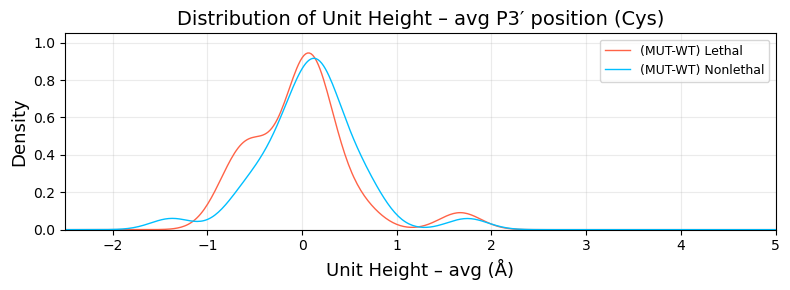

JSD (DIFF-L vs DIFF-N): 0.0931
DIFF_L → number of peaks: 2
  Peak 1: -0.4323 Å, density=0.5821
  Peak 2: 0.4699 Å, density=0.5704
DIFF_N → number of peaks: 1
  Peak 1: 0.1316 Å, density=1.0705

Position P6′ (Unit Height – avg) Standard Deviations:
Standard deviation for DIFF_L: 0.5853 Å
Standard deviation for DIFF_N: 0.3887 Å
(DIFF_L-DIFF_N)std (Normalized SD difference): 0.1966


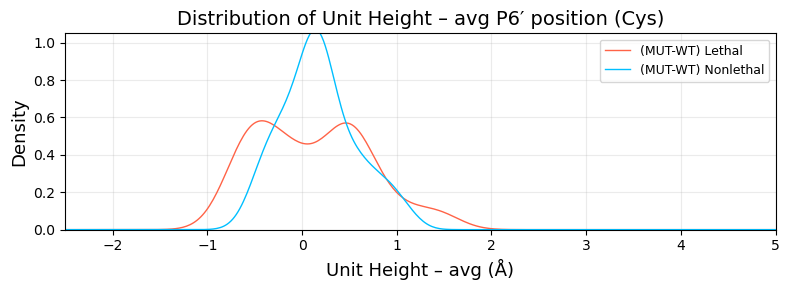

JSD (DIFF-L vs DIFF-N): 0.3255
DIFF_L → number of peaks: 1
  Peak 1: -0.0376 Å, density=0.7967
DIFF_N → number of peaks: 2
  Peak 1: 0.0376 Å, density=0.8118
  Peak 2: 1.7669 Å, density=0.0575

Position P9′ (Unit Height – avg) Standard Deviations:
Standard deviation for DIFF_L: 0.4574 Å
Standard deviation for DIFF_N: 0.5503 Å
(DIFF_L-DIFF_N)std (Normalized SD difference): -0.0929


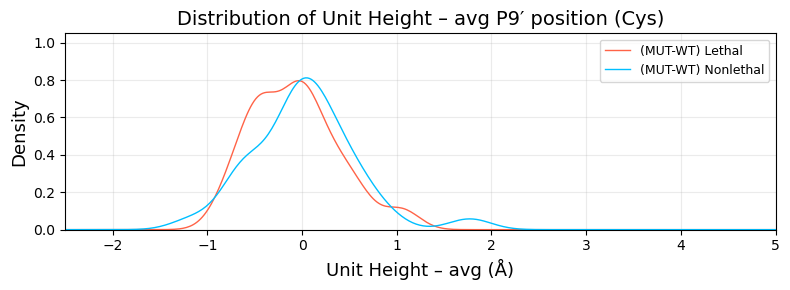

JSD (DIFF-L vs DIFF-N): 0.1563
DIFF_L → number of peaks: 1
  Peak 1: -0.0564 Å, density=0.8877
DIFF_N → number of peaks: 2
  Peak 1: -1.2594 Å, density=0.0699
  Peak 2: 0.2820 Å, density=0.9136

Position P12′ (Unit Height – avg) Standard Deviations:
Standard deviation for DIFF_L: 0.4390 Å
Standard deviation for DIFF_N: 0.4537 Å
(DIFF_L-DIFF_N)std (Normalized SD difference): -0.0147


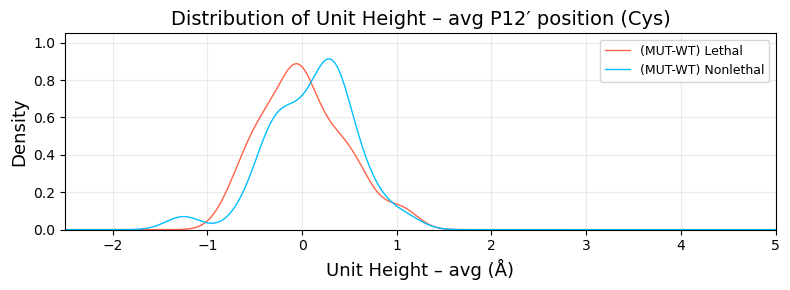

JSD (DIFF-L vs DIFF-N): 0.1291


In [76]:
# 改------------------------------------------------------------
# 單一位置 WT vs Mut 分布圖 (KDE / PDF)

def jsd_from_samples(p_samples, q_samples, bins=20, range_=None, base=2, eps=1e-12):
    """
    計算 Jensen-Shannon Divergence (JSD)
    """
    p_samples = np.asarray(p_samples, dtype=float)
    q_samples = np.asarray(q_samples, dtype=float)

    if range_ is None:
        min_val = min(p_samples.min(), q_samples.min())
        max_val = max(p_samples.max(), q_samples.max())
        range_ = (min_val, max_val)

    p_hist, _ = np.histogram(p_samples, bins=bins, range=range_, density=False)
    q_hist, _ = np.histogram(q_samples, bins=bins, range=range_, density=False)
    p = p_hist / p_hist.sum()
    q = q_hist / q_hist.sum()
    p = np.where(p == 0, eps, p)
    q = np.where(q == 0, eps, q)
    m = 0.5 * (p + q)
    m = np.where(m == 0, eps, m)

    jsd = 0.5 * distance.rel_entr(p, m).sum() + 0.5 * distance.rel_entr(q, m).sum()
    jsd /= np.log(base)
    return np.sqrt(jsd)

def calculate_jsd_for_wt_samples(samples):
    """
    計算 WT-L vs WT-N`，MUT-L vs WT-L`，`MUT-N vs WT-N` 的 JSD
    """
    # 計算需要的 JSD
    jsd_diff_l_vs_diff_n = jsd_from_samples(samples[:,0], samples[:,1])

    print(f"JSD (DIFF-L vs DIFF-N): {jsd_diff_l_vs_diff_n:.4f}")
    
    return {
        "JSD_DIFF_L_vs_DIFF_N": jsd_diff_l_vs_diff_n,
    }

# --- 計算標準差的函數 -------------------------------------------
def calculate_standard_deviation(samples):
    """
    計算每條線段的標準差並返回
    """
    std_devs = {key: np.std(vals) for key, vals in samples.items()}
    
    # 顯示每條線段的標準差
    for key, std_dev in std_devs.items():
        print(f"Standard deviation for {key}: {std_dev:.4f} Å")
    
    return std_devs

# 計算標準化差異指標
def normalized_sd_difference(samples):

    results = {}

    if samples["DIFF_L"].size > 0 and samples["DIFF_N"].size > 0:
        DIFF_L = samples["DIFF_L"]
        DIFF_N = samples["DIFF_N"]
        sd_DIFF_L = np.std(DIFF_L)
        sd_DIFF_N = np.std(DIFF_N)
        results["DIFF_L-N_std"] = (sd_DIFF_L - sd_DIFF_N)
        print(f"(DIFF_L-DIFF_N)std (Normalized SD difference): {results['DIFF_L-N_std']:.4f}")
    else:
        results["L_std"] = None
        print("No L (lethal) samples, cannot calculate normalized SD difference")

    return results

                   
def plot_kde_onepos_wt_vs_mut(
    data_mut, data_wt, meta,
    pos_label="M0", t_title="Unit Height",
    # bw_pos=0.45, bw_gpo=0.7,
    xlim=None, ylim=(0, 1)
):
    """
    data_mut : (N, 9) 或 (N, T, 9) ← mutant（每條 9 位置；或含 T 個時間步）
    data_wt  : (N, 9) 或 (N, T, 9) ← WT
    meta     : dict ← mutation_name(_arr) / lethal_arr / alpha12_arr（長度 N）
               若 data_* 是 3D，會自動 repeat 以對齊攤平後樣本數
    僅取 Cys、α1，並拆成 Lethal / Nonlethal；WT 用相同遮罩。
    """

    # --- 位置索引 ---------------------------------------------------
    pos_labels_all = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]
    if pos_label not in pos_labels_all:
        raise ValueError(f"pos_label 必須是 {pos_labels_all} 之一")
    idx = pos_labels_all.index(pos_label)

    # --- 取得 meta 欄位（支援 *_arr 或無尾綴） ------------------------
    def _get(meta, base):
        if base in meta: return np.asarray(meta[base])
        if f"{base}_arr" in meta: return np.asarray(meta[f"{base}_arr"])
        raise KeyError(f"meta 缺少：{base} 或 {base}_arr")

    mut_name = _get(meta, "mutation_name").astype(str)
    lethal   = _get(meta, "lethal")
    alpha12  = _get(meta, "alpha12")
    # --- 計算 (Mut - WT) 差值 -------------------------------------
    diff_all = unit_hei_avg - unit_wt_avg

    # --- 攤平資料 & 同步 repeat meta --------------------------------
    def _flatten_and_repeat(data, mut_name, lethal, alpha12):
        if data.ndim == 3:
            N, T, P = data.shape
            assert P == 9, f"最後一維應為 9，取得 {P}"
            data2d  = data.reshape(N*T, P)
            return (data2d,
                    np.repeat(mut_name, T),
                    np.repeat(lethal, T),
                    np.repeat(alpha12, T))
        elif data.ndim == 2:
            return data, mut_name, lethal, alpha12
        else:
            raise ValueError("data_* 形狀需為 (N,9) 或 (N,T,9)")

    mut2d, mut_name_r, leth_r, a12_r = _flatten_and_repeat(data_mut, mut_name, lethal, alpha12)
    wt2d,  _,           _,     _     = _flatten_and_repeat(data_wt,  mut_name, lethal, alpha12)

    # --- 只取 Cys，僅 α1，拆 lethal / non-lethal ---------------------
    is_cys   = (mut_name_r == "CYS")
    leth_cys = leth_r[is_cys]
    a12_cys  = a12_r[is_cys]
    diff_all_cys = diff_all[is_cys]

    mask_lethal    = (a12_cys == 1) & (leth_cys == 0)
    mask_nonlethal = (a12_cys == 1) & (leth_cys == 1)

    # --- 收集樣本 ---------------------------------------------------
    samples = dict(
        DIFF_L   = diff_all_cys[mask_lethal,    idx],
        DIFF_N   = diff_all_cys[mask_nonlethal, idx],

    )
    

    if not any(v.size for v in samples.values()):
        print(f"[警告] {pos_label} 在目前遮罩下沒有樣本可畫。")
        return

    # --- 決定 X 軸範圍 ---------------------------------------------
    vals_list = [v for v in samples.values() if v.size]
    all_vals = np.concatenate(vals_list)

    if 'gpo_unit_hei_traj' in globals():
        gpo_vals = gpo_unit_hei_traj[:, 1:].ravel()
        if gpo_vals.size:
            all_vals = np.concatenate([all_vals, gpo_vals])

    if xlim is None:
        x_min, x_max = all_vals.min()*0.9, all_vals.max()*1.1
    else:
        x_min, x_max = xlim
    xs = np.linspace(-2.5, 5, 400)

    # --- 繪圖 --------------------------------------------------------
    plt.figure(figsize=(8, 3))

    style = dict(
        DIFF_L  = dict(color='tomato',      lw=1, label='(MUT-WT) Lethal'),
        DIFF_N  = dict(color='deepskyblue', lw=1, label='(MUT-WT) Nonlethal'),

    )

    kde_all = np.zeros((400,4))
    i = 0
    for key, vals in samples.items():
        if vals.size == 0: 
            continue

        kde = gaussian_kde(vals, 0.4)
        y = kde(xs)
        plt.plot(xs, y, **style[key])
        kde_all[:, i] = y
        i += 1

        # --- 找到所有峰 ---
        peaks, properties = find_peaks(y, height=0.001, distance=5)
        num_peaks = len(peaks)
        print(f"{key} → number of peaks: {num_peaks}")

        if num_peaks > 0:
            for j, pk in enumerate(peaks):
                peak_x = xs[pk]
                peak_y = y[pk]
                print(f"  Peak {j+1}: {peak_x:.4f} Å, density={peak_y:.4f}")

            
    print(f"\nPosition {pos_label} ({t_title}) Standard Deviations:")
    std_devs = calculate_standard_deviation(samples)
    # 正規化標準差差異
    norm_diff = normalized_sd_difference(samples)

    # 軸 & 標題
    plt.xlabel(f"{t_title} (Å)", fontsize=13)
    plt.ylabel("Density", fontsize=13)
    plt.xlim(-2.5, 5)
    plt.xticks(np.arange(-2, 6, 1))
    plt.ylim(0, 1.05)
    plt.title(f"Distribution of {t_title} {pos_label} position (Cys)", fontsize=14)
    plt.legend(fontsize=9)
    plt.grid(True, alpha=.25)
    plt.tight_layout()
    plt.show()

    return kde_all

# ------------------------------------------------------------
# 呼叫範例
meta = {
    "mutation_name": mutation_name_arr,  # 或 mutation_name_arr
    "lethal_arr":    lethal_arr,
    "alpha12_arr":   alpha12_arr,
}

pos_labels_all = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]

for lbl in pos_labels_all:
    kde_all = plot_kde_onepos_wt_vs_mut(
        unit_hei_avg,   # mutant 資料
        unit_wt_avg,    # WT 資料
        meta,
        pos_label=lbl,
        t_title="Unit Height – avg"
    )
    calculate_jsd_for_wt_samples(kde_all)


#### CDF-avg(mut-wt)

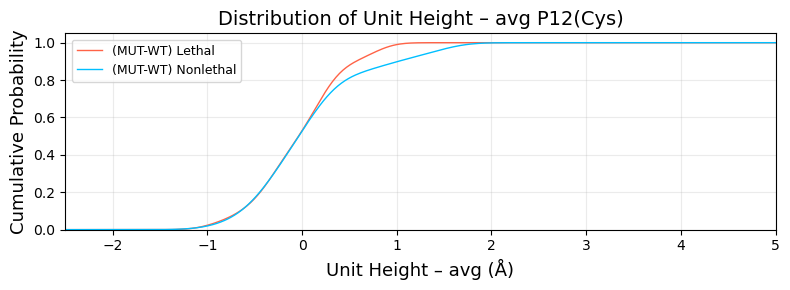

JSD (DIFF- L vs N): 0.1162
✅ 已儲存：./jsd_plots/CYS_diff\DIFF-_L_vs_N_P12.png


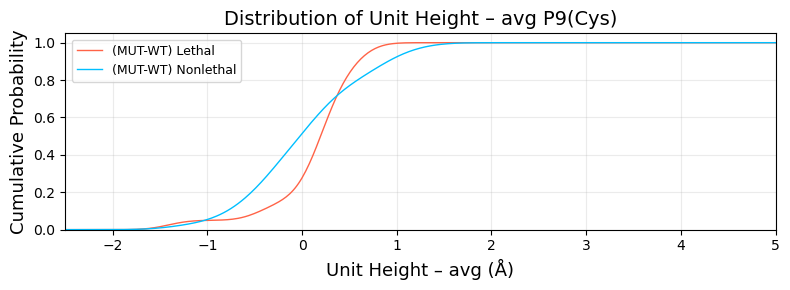

JSD (DIFF- L vs N): 0.1487
✅ 已儲存：./jsd_plots/CYS_diff\DIFF-_L_vs_N_P9.png


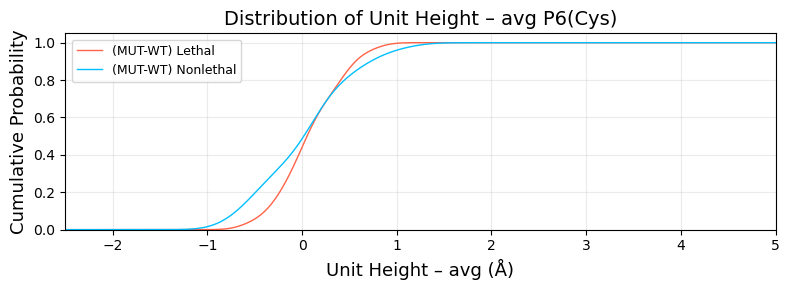

JSD (DIFF- L vs N): 0.0964
✅ 已儲存：./jsd_plots/CYS_diff\DIFF-_L_vs_N_P6.png


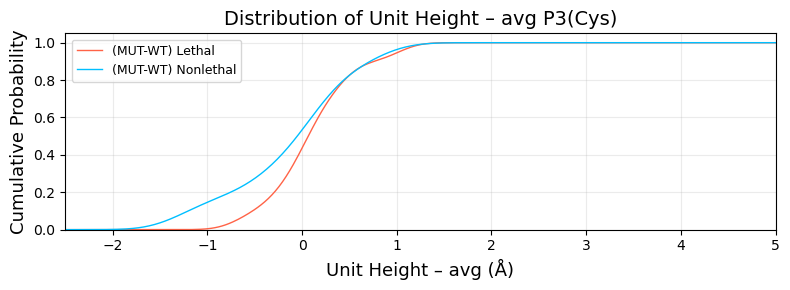

JSD (DIFF- L vs N): 0.1416
✅ 已儲存：./jsd_plots/CYS_diff\DIFF-_L_vs_N_P3.png


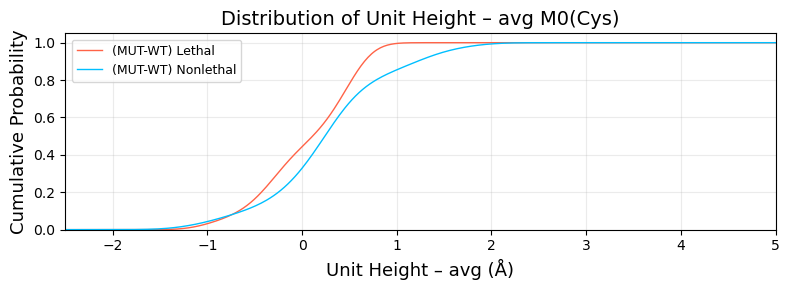

JSD (DIFF- L vs N): 0.1461
✅ 已儲存：./jsd_plots/CYS_diff\DIFF-_L_vs_N_M0.png


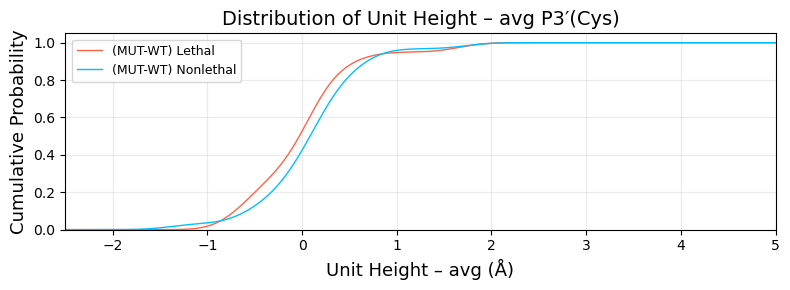

JSD (DIFF- L vs N): 0.1010
✅ 已儲存：./jsd_plots/CYS_diff\DIFF-_L_vs_N_P3′.png


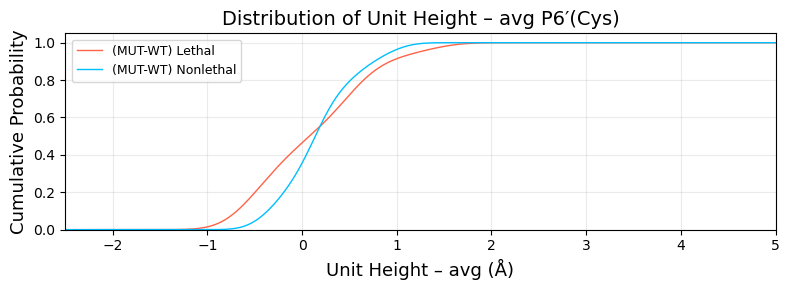

JSD (DIFF- L vs N): 0.1047
✅ 已儲存：./jsd_plots/CYS_diff\DIFF-_L_vs_N_P6′.png


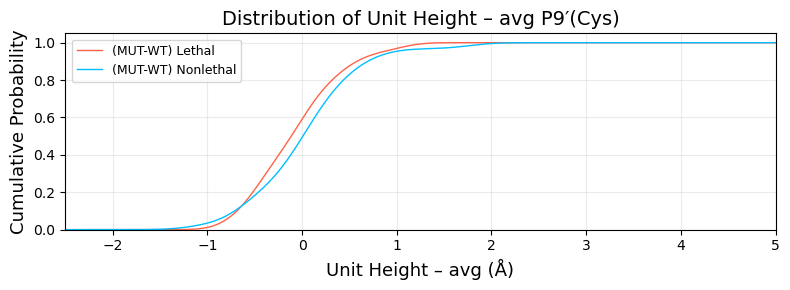

JSD (DIFF- L vs N): 0.0542
✅ 已儲存：./jsd_plots/CYS_diff\DIFF-_L_vs_N_P9′.png


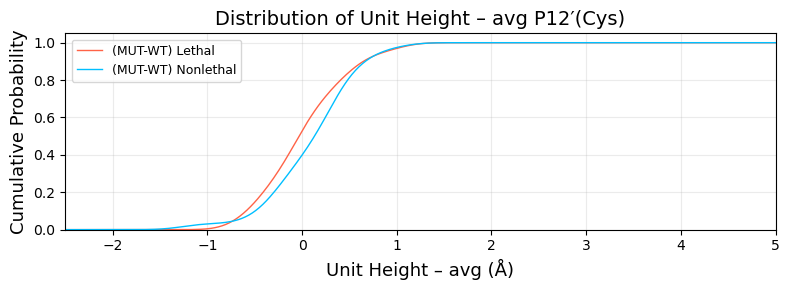

JSD (DIFF- L vs N): 0.0548
✅ 已儲存：./jsd_plots/CYS_diff\DIFF-_L_vs_N_P12′.png


In [80]:
from scipy.spatial import distance
from scipy import integrate
def jsd_from_samples(p_samples, q_samples, bins=20, range_=None, base=2, eps=1e-12):
    """
    計算 Jensen-Shannon Divergence (JSD)
    """
    p_samples = np.asarray(p_samples, dtype=float)
    q_samples = np.asarray(q_samples, dtype=float)

    if range_ is None:
        min_val = min(p_samples.min(), q_samples.min())
        max_val = max(p_samples.max(), q_samples.max())
        range_ = (min_val, max_val)

    p_hist, _ = np.histogram(p_samples, bins=bins, range=range_, density=False)
    q_hist, _ = np.histogram(q_samples, bins=bins, range=range_, density=False)
    p = p_hist / p_hist.sum()
    q = q_hist / q_hist.sum()
    p = np.where(p == 0, eps, p)
    q = np.where(q == 0, eps, q)
    m = 0.5 * (p + q)
    m = np.where(m == 0, eps, m)

    jsd = 0.5 * distance.rel_entr(p, m).sum() + 0.5 * distance.rel_entr(q, m).sum()
    jsd /= np.log(base)
    return np.sqrt(jsd)

bar_results = {
    "DIFF- L vs N": {"signed": [], "abs": []},
}

def calculate_jsd_for_wt_samples(samples, pos_label="M0", save_dir="./jsd_plots/CYS_diff"):
    # 用於收集所有位置的積分結果

    pos_labels_all = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]

    os.makedirs(save_dir, exist_ok=True)
    # 計算需要的 JSD
    jsd_diff_l_vs_diff_n = jsd_from_samples(samples[:,0], samples[:,1])

    print(f"JSD (DIFF- L vs N): {jsd_diff_l_vs_diff_n:.4f}")

    # ====== 三組比較繪圖 ======
    pairs = [
        ("DIFF- L vs N", samples[:,0], samples[:,1], jsd_diff_l_vs_diff_n, "Cumulative ∫(L - N) dx", "Cumulative ∫|L - N| dx"),
    ]

    final_values = {}
    # 累積積分曲線（cumulative integral curve）> 隨著 x 累積面積變化的曲線
    for title, L, N, jsd_val, ylabelsign, ylabelabs in pairs:
        # 積分仍在索引空間進行
        x_idx = np.linspace(0, len(L)-1, len(L))
        diff = L - N
        # === 有號積分 ===
        cum_area_signed = integrate.cumulative_trapezoid(diff, x_idx, initial=0)
        final_signed = cum_area_signed[-1]
        # === 絕對值積分 ===
        cum_area_abs = integrate.cumulative_trapezoid(np.abs(diff), x_idx, initial=0)
        final_abs = cum_area_abs[-1]
        # 紀錄結果
        final_values[title] = {"signed": final_signed, "abs": final_abs}

        # 畫圖
        plt.figure(figsize=(8,4))
        plt.plot(x_idx, cum_area_signed, color="deeppink", lw=1, label=ylabelsign)
        plt.plot(x_idx, cum_area_abs, color="orange", lw=1, label=ylabelabs)
        plt.legend(fontsize=9)
        plt.axhline(0, color="gray", linestyle="--", lw=1)
        plt.xlabel("x (Å)", fontsize=13)
        plt.ylabel("Cumulative ∫dx", fontsize=13)
        plt.ylim(-25, 25)

        # 🔹設定 x 軸刻度對應真實範圍 (3.5–11)，且不超出
        tick_label = np.arange(-2, 6, 1)                     # -2,-1,0,1,2,3,4,5
        tick_label = tick_label[tick_label <= 5]            # 確保不超出 5
        tick_pos = (tick_label - -2.5) / (6 - -2.5) * (len(L) - 1)
        plt.xticks(tick_pos, tick_label)
        # 限制 X 軸範圍
        plt.xlim(0, len(L)-1)

        plt.title(f"{title} – {pos_label}\nJSD = {jsd_val:.4f}")
        plt.text(
            0.98, 0.95,
            f"Final = {final_signed:.4f}\n|Final| = {final_abs:.4f}",
            transform=plt.gca().transAxes,
            color="black", fontsize=9,
            ha="right", va="top"
        )

        plt.grid(True, alpha=0.25)
        plt.tight_layout()

        # 檔名處理：避免特殊符號
        safe_title = title.replace(" ", "_").replace("–", "-").replace("/", "-")
        filename = f"{safe_title}_{pos_label}.png"
        save_path = os.path.join(save_dir, filename)

        plt.savefig(save_path, dpi=300)
        plt.close()
        results_per_pair = {
            title: {"signed": final_signed, "abs": final_abs}
        }

        print(f"✅ 已儲存：{save_path}")

    return {
        "JSD_DIFF_L_vs_DIFF_N": jsd_diff_l_vs_diff_n,
        "final_values": final_values
    }

def plot_cdf_onepos_wt_vs_mut(
    data_mut, data_wt, meta,
    pos_label="M0",
    t_title="Unit Height",
    xlim=None, ylim=(0, 1.05)
):
    """
    data_mut : (N, 9) 或 (N, T, 9) ← mutant（每條 9 位置；或含 T 個時間步）
    data_wt  : (N, 9) 或 (N, T, 9) ← WT
    meta     : dict ← mutation_name(_arr) / lethal_arr / alpha12_arr（長度 N）
               若 data_* 是 3D，會自動 repeat 以對齊攤平後樣本數
    僅取 Cys、α1，並拆成 Lethal / Nonlethal；WT 用相同遮罩。
    """

    # --- 位置索引 ---------------------------------------------------
    pos_labels_all = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]
    if pos_label not in pos_labels_all:
        raise ValueError(f"pos_label 必須是 {pos_labels_all} 之一")
    idx = pos_labels_all.index(pos_label)

    # --- 取得 meta 欄位 ---------------------------------------------
    def _get(meta, base):
        if base in meta: return np.asarray(meta[base])
        if f"{base}_arr" in meta: return np.asarray(meta[f"{base}_arr"])
        raise KeyError(f"meta 缺少：{base} 或 {base}_arr")

    mut_name = _get(meta, "mutation_name").astype(str)
    lethal   = _get(meta, "lethal")
    alpha12  = _get(meta, "alpha12")

    # --- 攤平資料 & 同步 repeat meta -------------------------------
    def _flatten_and_repeat(data, mut_name, lethal, alpha12):
        if data.ndim == 3:
            N, T, P = data.shape
            assert P == 9, f"最後一維應為 9，取得 {P}"
            data2d  = data.reshape(N*T, P)
            return (data2d,
                    np.repeat(mut_name, T),
                    np.repeat(lethal,   T),
                    np.repeat(alpha12,  T))
        elif data.ndim == 2:
            return data, mut_name, lethal, alpha12
        else:
            raise ValueError("data_* 形狀需為 (N,9) 或 (N,T,9)")

    mut2d, mut_name_r, leth_r, a12_r = _flatten_and_repeat(data_mut, mut_name, lethal, alpha12)
    wt2d,  _,           _,     _     = _flatten_and_repeat(data_wt,  mut_name, lethal, alpha12)

    # --- 計算 (Mut - WT) 差值 -------------------------------------
    diff_all = unit_hei_avg - unit_wt_avg
    # --- 只取 Cys，僅 α1，拆 lethal / non-lethal -------------------
    is_cys   = (mut_name_r == "CYS")
    leth_cys = leth_r[is_cys]
    a12_cys  = a12_r[is_cys]
    diff_all_cys = diff_all[is_cys]

    mask_lethal    = (a12_cys == 1) & (leth_cys == 0)
    mask_nonlethal = (a12_cys == 1) & (leth_cys == 1)

    # --- 收集樣本 --------------------------------------------------
    samples = dict(
        DIFF_L   = diff_all_cys[mask_lethal,    idx],
        DIFF_N   = diff_all_cys[mask_nonlethal, idx],
    )

    if not any(v.size for v in samples.values()):
        print(f"[警告] {pos_label} 在目前遮罩下沒有樣本可畫。")
        return

    # --- 決定 X 範圍（含 GPO） -------------------------------------
    vals_list = [v for v in samples.values() if v.size]
    all_vals = np.concatenate(vals_list)
    if 'gpo_unit_hei_traj' in globals():
        gpo_vals = gpo_unit_hei_traj[:, 1:].ravel()
        if gpo_vals.size:
            all_vals = np.concatenate([all_vals, gpo_vals])

    if xlim is None:
        x_min, x_max = all_vals.min()*0.9, all_vals.max()*1.1
    else:
        x_min, x_max = xlim

    # --- 繪圖 -------------------------------------------------------
    xs = np.linspace(-2.5, 5, 400)
    dx = (5 - -2.5) / 399
    plt.figure(figsize=(8, 3))

    style = dict(
        DIFF_L  = dict(color='tomato',      lw=1, label='(MUT-WT) Lethal'),
        DIFF_N  = dict(color='deepskyblue', lw=1, label='(MUT-WT) Nonlethal'),
    )

    # 畫 ECDF

    kde_all = np.zeros((400,4))
    i = 0
    for key, vals in samples.items():
        if vals.size == 0:
            continue
        kde = gaussian_kde(vals,0.4)
        Y= kde(xs)/(dx*kde(xs)).sum()
        C_kde =np.cumsum(Y*dx)
        # plt.plot(xs, kde(xs), **style[key], alpha = 0.3)
        plt.plot(xs, C_kde, **style[key])
        kde_all[:,i] = C_kde
        i = i + 1   


    # 軸 & 標題
    plt.xlabel(f"{t_title} (Å)", fontsize=13)
    plt.ylabel("Cumulative Probability", fontsize=13)
    plt.xlim(-2.5, 5)
    plt.ylim(*ylim)
    plt.title(f"Distribution of {t_title} {pos_label}(Cys)", fontsize=14)
    plt.legend(fontsize=9)
    plt.grid(True, alpha=.25)
    plt.tight_layout()
    plt.show()
    return kde_all

for lbl in pos_labels_all:
    kde_all = plot_cdf_onepos_wt_vs_mut(
        unit_hei_avg,
        unit_wt_avg,
        meta,
        pos_label=lbl,
        t_title="Unit Height – avg"
    )
    result = calculate_jsd_for_wt_samples(kde_all, pos_label=lbl)

    # 收集積分結果
    for title in bar_results.keys():
        bar_results[title]["signed"].append(result["final_values"][title]["signed"])
        bar_results[title]["abs"].append(result["final_values"][title]["abs"])

In [81]:
# X 軸位置
x_labels = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]
x = np.arange(len(x_labels))

for title, data in bar_results.items():
    # --- 有號積分 ---
    plt.figure(figsize=(8,4))
    plt.bar(x, data["signed"], color="deeppink", alpha=0.7)
    plt.xticks(x, x_labels, rotation=45)
    plt.ylabel("Cumulative ∫()dx")
    plt.ylim(-20,20)
    plt.title(f"{title} – Signed Integral")
    plt.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(f"./jsd_plots/CYS_diff/bar_{title.replace(' ','_')}_signed.png", dpi=300)
    plt.close()

    # --- 絕對值積分 ---
    plt.figure(figsize=(8,4))
    plt.bar(x, data["abs"], color="orange", alpha=0.7)
    plt.xticks(x, x_labels, rotation=45)
    plt.ylabel("Cumulative ∫|| dx")
    plt.ylim(-20,20)
    plt.title(f"{title} – Absolute Integral")
    plt.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(f"./jsd_plots/CYS_diff/bar_{title.replace(' ','_')}_abs.png", dpi=300)
    plt.close()


## 選擇突變案例畫100FRAMES

### KDE

--- Showing P12 ---
peak for WT_N: 8.2556 Å
peak for MUT_N: 8.2180 Å
Standard deviation for WT_L: nan Å
Standard deviation for WT_N: 0.3637 Å
Standard deviation for MUT_L: nan Å
Standard deviation for MUT_N: 0.2769 Å
No L (lethal) samples, cannot calculate normalized SD difference
N_std (Normalized SD difference): -0.2388


c:\Users\wendy\anaconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\wendy\anaconda3\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\wendy\anaconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


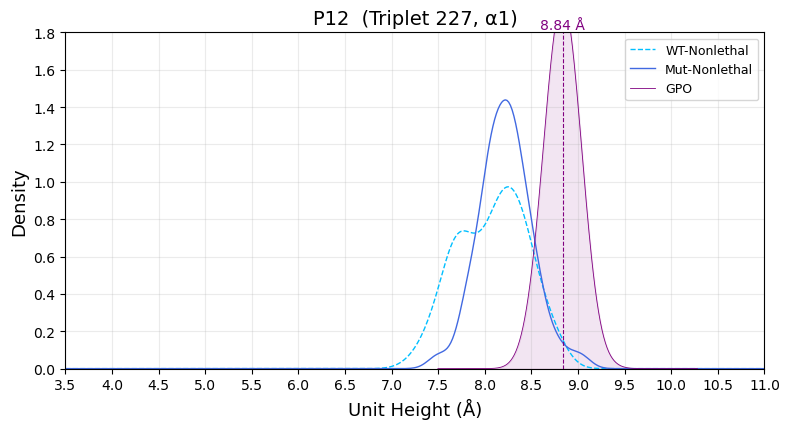

JSD (WT-L vs WT-N): 0.3673
JSD (MUT-L vs WT-L): 0.0000
JSD (MUT-N vs WT-N): 0.2390
--- Showing P9 ---
peak for WT_N: 7.7293 Å
peak for MUT_N: 8.9887 Å
Standard deviation for WT_L: nan Å
Standard deviation for WT_N: 0.3296 Å
Standard deviation for MUT_L: nan Å
Standard deviation for MUT_N: 0.2235 Å
No L (lethal) samples, cannot calculate normalized SD difference
N_std (Normalized SD difference): -0.3219


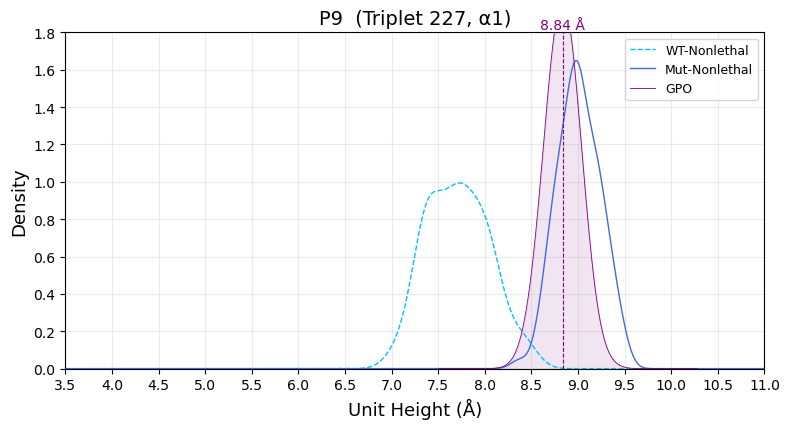

JSD (WT-L vs WT-N): 0.3547
JSD (MUT-L vs WT-L): 0.0000
JSD (MUT-N vs WT-N): 0.2384
--- Showing P6 ---
peak for WT_N: 8.4248 Å
peak for MUT_N: 9.0827 Å
Standard deviation for WT_L: nan Å
Standard deviation for WT_N: 0.3957 Å
Standard deviation for MUT_L: nan Å
Standard deviation for MUT_N: 0.3198 Å
No L (lethal) samples, cannot calculate normalized SD difference
N_std (Normalized SD difference): -0.1919


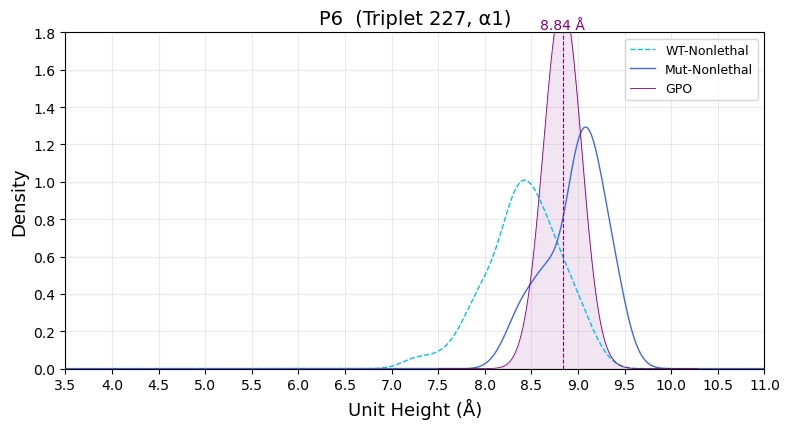

JSD (WT-L vs WT-N): 0.4015
JSD (MUT-L vs WT-L): 0.0000
JSD (MUT-N vs WT-N): 0.1886
--- Showing P3 ---
peak for WT_N: 7.9549 Å
peak for MUT_N: 8.7444 Å
Standard deviation for WT_L: nan Å
Standard deviation for WT_N: 0.4832 Å
Standard deviation for MUT_L: nan Å
Standard deviation for MUT_N: 0.3123 Å
No L (lethal) samples, cannot calculate normalized SD difference
N_std (Normalized SD difference): -0.3537


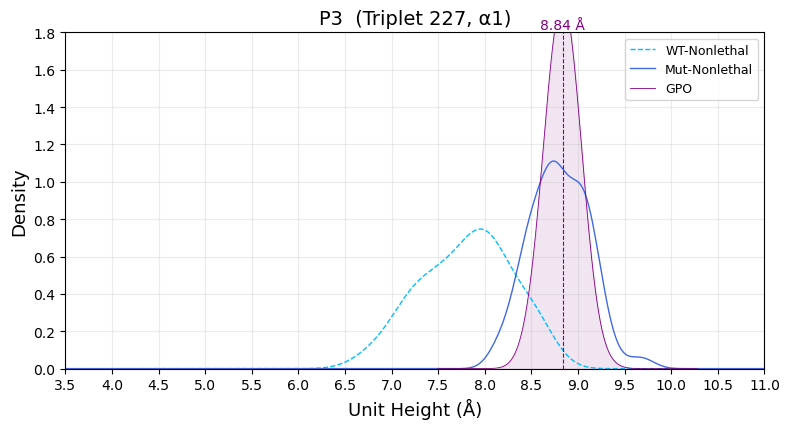

JSD (WT-L vs WT-N): 0.4306
JSD (MUT-L vs WT-L): 0.0000
JSD (MUT-N vs WT-N): 0.2968
--- Showing M0 ---
peak for WT_N: 9.2143 Å
peak for MUT_N: 9.6654 Å
Standard deviation for WT_L: nan Å
Standard deviation for WT_N: 0.3324 Å
Standard deviation for MUT_L: nan Å
Standard deviation for MUT_N: 0.2023 Å
No L (lethal) samples, cannot calculate normalized SD difference
N_std (Normalized SD difference): -0.3916


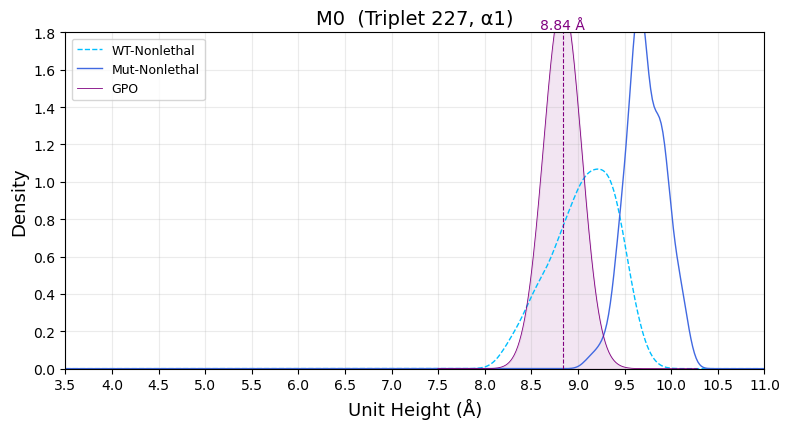

JSD (WT-L vs WT-N): 0.3483
JSD (MUT-L vs WT-L): 0.0000
JSD (MUT-N vs WT-N): 0.2496
--- Showing P3′ ---
peak for WT_N: 9.1391 Å
peak for MUT_N: 8.3496 Å
Standard deviation for WT_L: nan Å
Standard deviation for WT_N: 0.3883 Å
Standard deviation for MUT_L: nan Å
Standard deviation for MUT_N: 0.1639 Å
No L (lethal) samples, cannot calculate normalized SD difference
N_std (Normalized SD difference): -0.5780


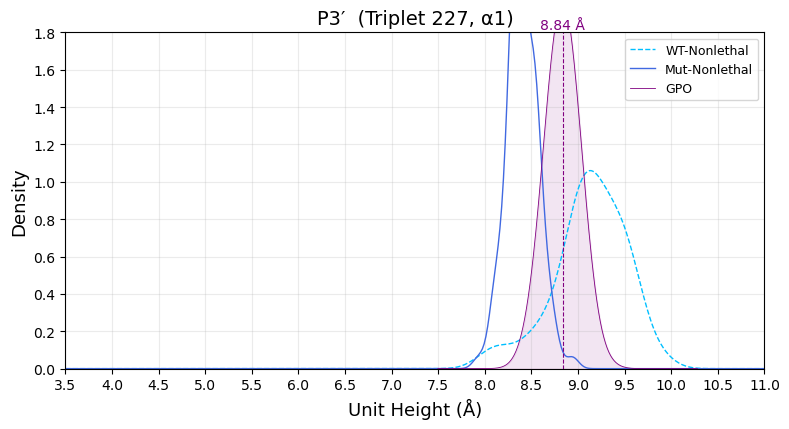

JSD (WT-L vs WT-N): 0.3976
JSD (MUT-L vs WT-L): 0.0000
JSD (MUT-N vs WT-N): 0.2703
--- Showing P6′ ---
peak for WT_N: 9.3271 Å
peak for MUT_N: 9.4211 Å
Standard deviation for WT_L: nan Å
Standard deviation for WT_N: 0.2280 Å
Standard deviation for MUT_L: nan Å
Standard deviation for MUT_N: 0.1819 Å
No L (lethal) samples, cannot calculate normalized SD difference
N_std (Normalized SD difference): -0.2022


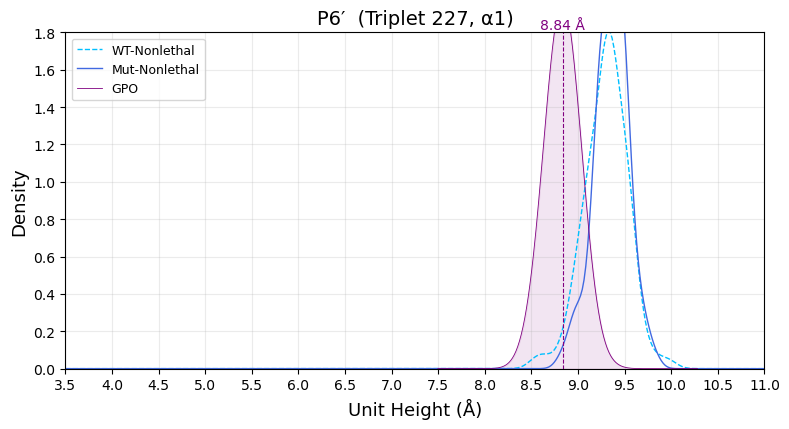

JSD (WT-L vs WT-N): 0.2818
JSD (MUT-L vs WT-L): 0.0000
JSD (MUT-N vs WT-N): 0.1581
--- Showing P9′ ---
peak for WT_N: 9.1767 Å
peak for MUT_N: 8.9323 Å
Standard deviation for WT_L: nan Å
Standard deviation for WT_N: 0.1989 Å
Standard deviation for MUT_L: nan Å
Standard deviation for MUT_N: 0.2443 Å
No L (lethal) samples, cannot calculate normalized SD difference
N_std (Normalized SD difference): 0.2282


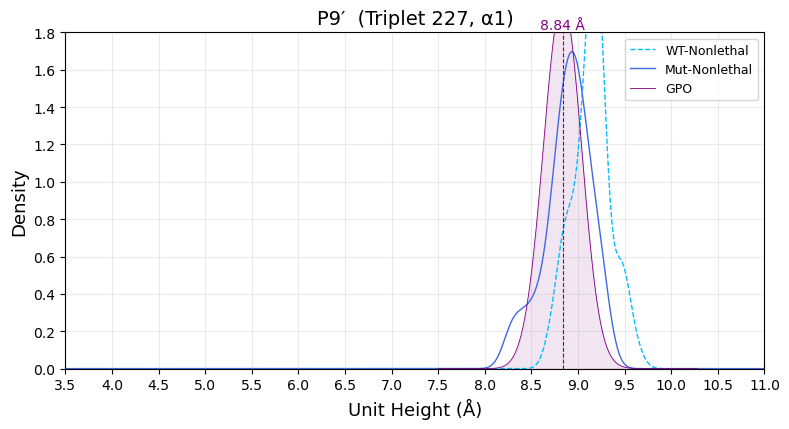

JSD (WT-L vs WT-N): 0.2691
JSD (MUT-L vs WT-L): 0.0000
JSD (MUT-N vs WT-N): 0.1636
--- Showing P12′ ---
peak for WT_N: 8.0865 Å
peak for MUT_N: 8.3120 Å
Standard deviation for WT_L: nan Å
Standard deviation for WT_N: 0.3291 Å
Standard deviation for MUT_L: nan Å
Standard deviation for MUT_N: 0.1687 Å
No L (lethal) samples, cannot calculate normalized SD difference
N_std (Normalized SD difference): -0.4872


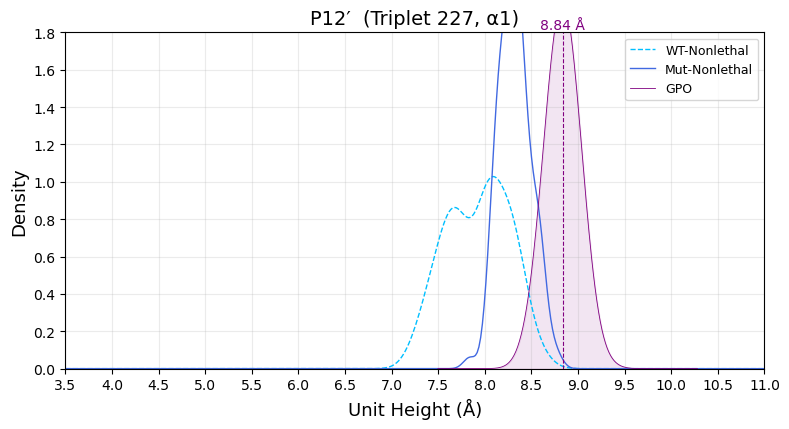

JSD (WT-L vs WT-N): 0.3419
JSD (MUT-L vs WT-L): 0.0000
JSD (MUT-N vs WT-N): 0.2526


In [88]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
def jsd_from_samples(p_samples, q_samples, bins=20, range_=None, base=2, eps=1e-12):
    """
    計算 Jensen-Shannon Divergence (JSD)
    """
    p_samples = np.asarray(p_samples, dtype=float)
    q_samples = np.asarray(q_samples, dtype=float)

    if range_ is None:
        min_val = min(p_samples.min(), q_samples.min())
        max_val = max(p_samples.max(), q_samples.max())
        range_ = (min_val, max_val)

    p_hist, _ = np.histogram(p_samples, bins=bins, range=range_, density=False)
    q_hist, _ = np.histogram(q_samples, bins=bins, range=range_, density=False)
    p = p_hist / p_hist.sum()
    q = q_hist / q_hist.sum()
    p = np.where(p == 0, eps, p)
    q = np.where(q == 0, eps, q)
    m = 0.5 * (p + q)
    m = np.where(m == 0, eps, m)

    jsd = 0.5 * distance.rel_entr(p, m).sum() + 0.5 * distance.rel_entr(q, m).sum()
    jsd /= np.log(base)
    return np.sqrt(jsd)

def calculate_jsd_for_wt_samples(samples):
    """
    計算 `WT-L vs WT-N`，`MUT-L vs WT-L`，`MUT-N vs WT-N` 的 JSD
    """
    # 計算需要的 JSD
    jsd_wt_l_vs_wt_n = jsd_from_samples(samples[:,0], samples[:,1])
    jsd_mut_l_vs_wt_l = jsd_from_samples(samples[:,2], samples[:,0])
    jsd_mut_n_vs_wt_n = jsd_from_samples(samples[:,3], samples[:,1])

    print(f"JSD (WT-L vs WT-N): {jsd_wt_l_vs_wt_n:.4f}")
    print(f"JSD (MUT-L vs WT-L): {jsd_mut_l_vs_wt_l:.4f}")
    print(f"JSD (MUT-N vs WT-N): {jsd_mut_n_vs_wt_n:.4f}")
    
    return {
        "JSD_WT_L_vs_WT_N": jsd_wt_l_vs_wt_n,
        "JSD_MUT_L_vs_WT_L": jsd_mut_l_vs_wt_l,
        "JSD_MUT_N_vs_WT_N": jsd_mut_n_vs_wt_n
    }

# ------------------------- 共用設定 -------------------------
POS_LABS = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]
COLORS   = ["#ff1493","#227700","#ffd700","#00ffff",
            "#000000","#4575b4","#542788","#cc0000","#00ff00"]

# ── GPO 參考 KDE (triplet 2–9) ────────────────────────────
combined  = gpo_unit_hei_traj[:, 1:].ravel()
xs_gpo    = np.linspace(combined.min()*0.9, combined.max()*1.1, 300)
ys_gpo    = gaussian_kde(combined, bw_method=0.7)(xs_gpo)
peak_gpo  = xs_gpo[np.argmax(ys_gpo)]

# # --- 計算標準差的函數 -------------------------------------------
# def calculate_standard_deviation(samples):
#     """
#     計算每條線段的標準差並返回
#     """
#     std_devs = {key: np.std(vals) for key, vals in samples.items()}
    
#     # 顯示每條線段的標準差
#     for key, std_dev in std_devs.items():
#         print(f"Standard deviation for {key}: {std_dev:.4f} Å")
    
#     return std_devs

def normalized_sd_difference(samples):
    """
    計算 WT_L-MUT_L 和 WT_N-MUT_N 的標準化差異指標：
    (SD(WT) - SD(MUT)) / (max(WT) - min(WT))
    
    samples: dict，包含 'WT_L', 'MUT_L', 'WT_N', 'MUT_N'
    return: dict，包含 L_std 和 N_std 的差異，若 N 不存在則顯示 None
    """
    results = {}

    # L 組
    if samples["WT_L"].size > 0 and samples["MUT_L"].size > 0:
        WT_L = samples["WT_L"]
        MUT_L = samples["MUT_L"]
        sd_WT_L = np.std(WT_L)
        sd_MUT_L = np.std(MUT_L)
        results["L_std"] = (sd_MUT_L - sd_WT_L) / sd_WT_L
        print(f"L_std (Normalized SD difference): {results['L_std']:.4f}")
    else:
        results["L_std"] = None
        print("No L (lethal) samples, cannot calculate normalized SD difference")

    # N 組
    if "WT_N" in samples and "MUT_N" in samples and samples["WT_N"].size > 0 and samples["MUT_N"].size > 0:
        WT_N = samples["WT_N"]
        MUT_N = samples["MUT_N"]
        sd_WT_N = np.std(WT_N)
        sd_MUT_N = np.std(MUT_N)
        results["N_std"] = (sd_MUT_N - sd_WT_N) / sd_WT_N
        print(f"N_std (Normalized SD difference): {results['N_std']:.4f}")
    else:
        results["N_std"] = None
        print("No N (non-lethal) samples, cannot calculate normalized SD difference")


    return results

import numpy as np
from scipy.stats import gaussian_kde


# --------------------- 主繪圖函式 --------------------------
def plot_kde_onepos_wt_vs_mut(data_mut, data_wt, meta,
                              pos_label="M0", t_title="Unit Height",
                              triplet_sel=227):
    """
    畫出單一位置 (如 M0) 的 KDE，Mut/WT 對照，CYS, α1, 指定 triplet。
    """
    idx = POS_LABS.index(pos_label)

    # 資料展開
    n_mut, n_frames, n_pos = data_mut.shape
    data_mut_2d = data_mut.reshape(n_mut * n_frames, n_pos)
    data_wt_2d  = data_wt.reshape(n_mut * n_frames, n_pos)

    # meta 展開
    mut  = np.repeat(np.asarray(meta["mutation_name_arr"]).astype(str), n_frames)
    leth = np.repeat(np.asarray(meta["lethal_arr"]), n_frames)
    tripnum = np.repeat(np.asarray(meta["triplet_number"]), n_frames)
    a12  = np.repeat(np.asarray(meta["alpha12_arr"]), n_frames)

    # 篩選條件
    mask_sel = (tripnum == triplet_sel) & (a12 == 1) & (mut == "CYS")
    mut_sel  = data_mut_2d[mask_sel]
    wt_sel   = data_wt_2d[mask_sel]
    leth_sel = leth[mask_sel]

    # lethal / nonlethal
    m_L = leth_sel == 0
    m_N = leth_sel == 1

    samples = dict(
        WT_L  = wt_sel [m_L, idx],
        WT_N  = wt_sel [m_N, idx],
        MUT_L = mut_sel[m_L, idx],
        MUT_N = mut_sel[m_N, idx],
    )


    if all(v.size == 0 for v in samples.values()):
        print(f"No data for {pos_label}")
        return

    # KDE 範圍
    all_vals = np.concatenate([v for v in samples.values() if v.size])
    xs = np.linspace(3.5, 11, 400)

    plt.figure(figsize=(8, 4.4))
    style = dict(
        WT_L  = dict(color='tomato',      ls='--', lw=1, label='WT-Lethal'),
        WT_N  = dict(color='deepskyblue', ls='--', lw=1, label='WT-Nonlethal'),
        MUT_L = dict(color='#d62728',     lw=1,   label='Mut-Lethal'),
        MUT_N = dict(color='royalblue',   lw=1,   label='Mut-Nonlethal'),
    )

    kde_all = np.zeros((400,4))
    i = 0
    for key, vals in samples.items():
        if vals.size == 0: 
            i = i+1
            continue
        kde = gaussian_kde(vals, bw_method=0.4)
        plt.plot(xs, kde(xs), **style[key])
        kde_all[:,i] = kde(xs)
        i += 1
        # 找到峰值位置
        peak_idx = np.argmax(kde(xs))
        peak_x = xs[peak_idx]
        print(f"peak for {key}: {peak_x:.4f} Å")

    std_devs = calculate_standard_deviation(samples)
    norm_diff = normalized_sd_difference(samples)

    # 疊 GPO
    plt.plot(xs_gpo, ys_gpo, color='purple', lw=.6, label='GPO')
    plt.fill_between(xs_gpo, ys_gpo, color='purple', alpha=.1)
    plt.axvline(peak_gpo, color='purple', ls='--', lw=.8)
    plt.text(peak_gpo, 1.8, f"{peak_gpo:.2f} Å",
             color="purple", ha="center", va="bottom", fontsize=10)

    # 設置 X 軸刻度
    x_ticks = np.arange(3.5, 11.5, 0.5)  # 例如每隔 0.5 顯示一個刻度
    plt.xticks(x_ticks)  # 設定刻度
    
    plt.xlabel(f"{t_title} (Å)", fontsize=13)
    plt.ylabel("Density", fontsize=13)
    plt.xlim(3.5, 11)
  
    plt.ylim(0, 1.8)
    plt.title(f"{pos_label}  (Triplet {triplet_sel}, α1)", fontsize=14)
    plt.legend(fontsize=9)
    plt.grid(alpha=.25)
    plt.tight_layout()
    plt.show()  # ✅ 直接顯示不儲存

    return kde_all


# ------------------------ 連續顯示 9 張圖 --------------------------
def plot_all9_units_show(data_mut, data_wt, meta, t_title="Unit Height",
                         triplet_sel=227):
    """
    連續顯示9張圖（P12～P12′），不儲存檔案。
    """
    for lbl in POS_LABS:
        print(f"--- Showing {lbl} ---")
        kde_all = plot_kde_onepos_wt_vs_mut(data_mut, data_wt, meta,
                                  pos_label=lbl,
                                  t_title=t_title,
                                  triplet_sel=triplet_sel)
        calculate_jsd_for_wt_samples(kde_all)

meta = {
    "lethal_arr":     lethal_arr,
    "alpha12_arr":    alpha12_arr,
    "triplet_number": triplet_number_arr, 
    "mutation_name_arr": mutation_name_arr
}

plot_all9_units_show(unit_hei_all, unit_hei_wt, meta,
                     t_title="Unit Height", triplet_sel=227)


### check kde

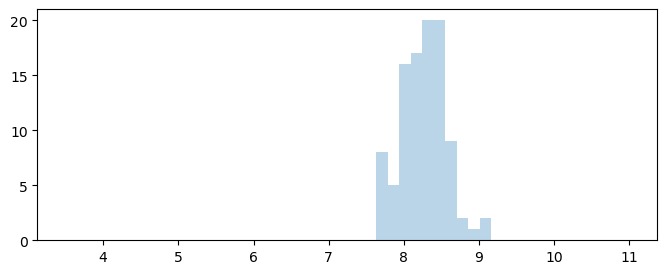

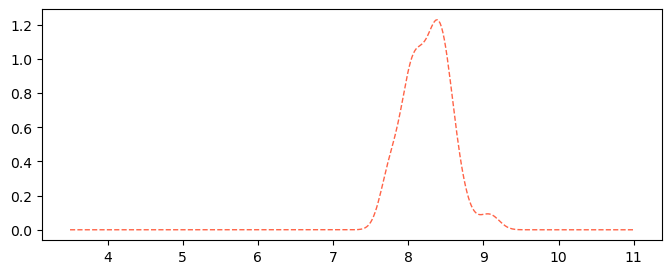

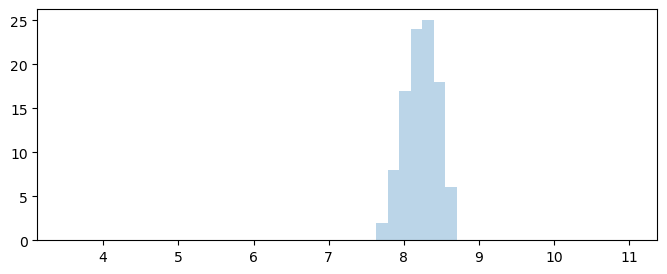

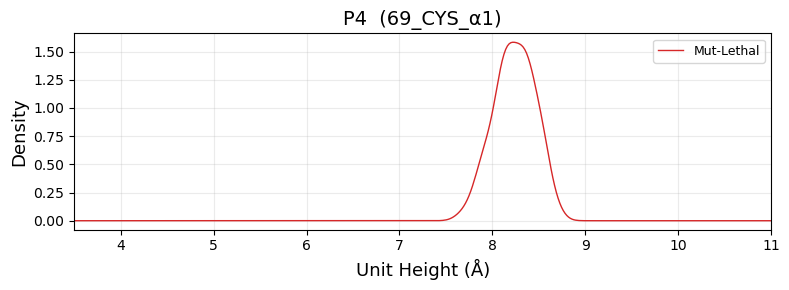

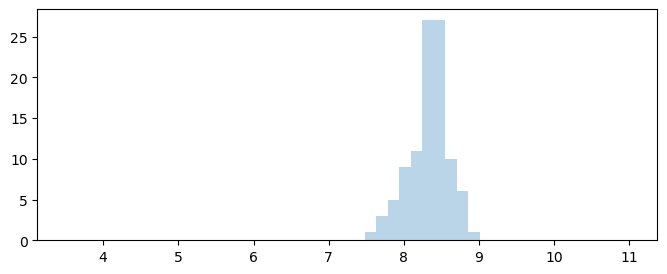

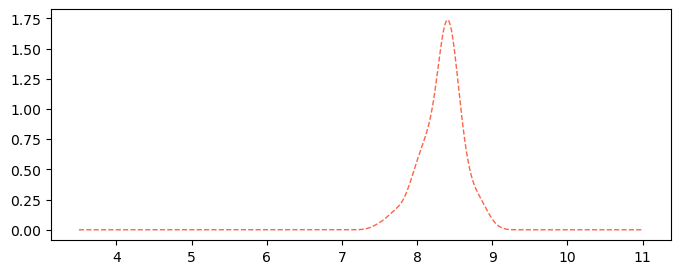

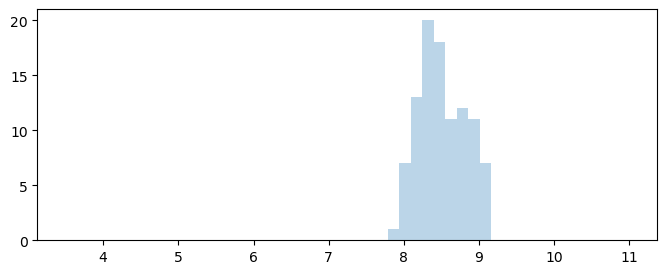

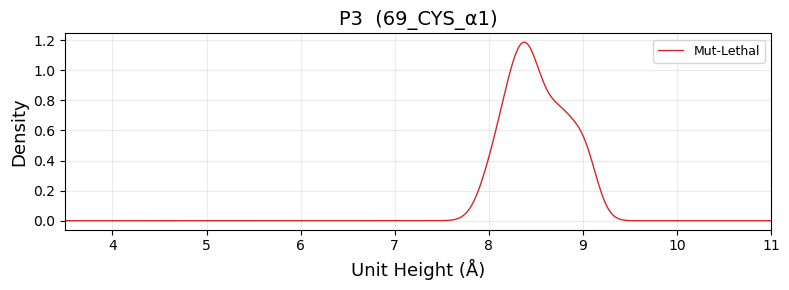

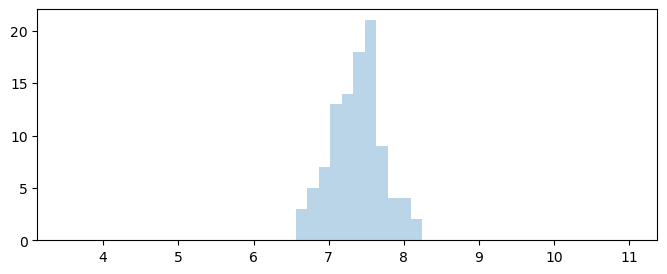

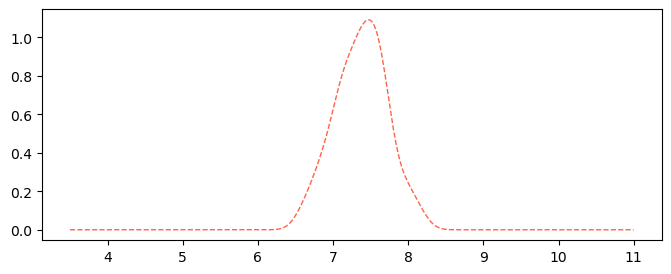

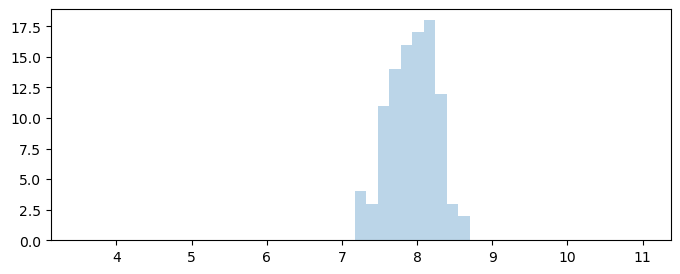

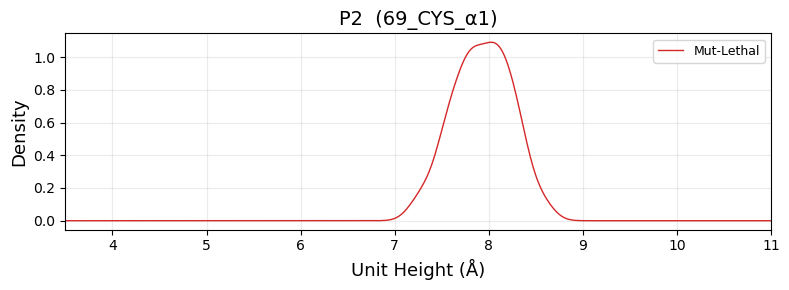

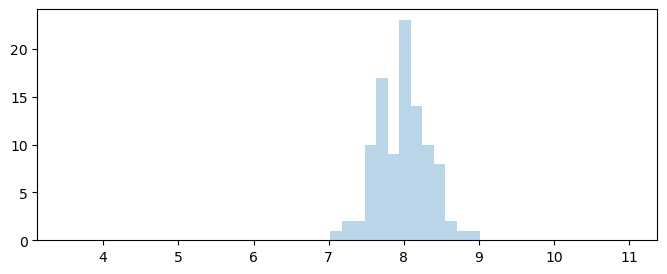

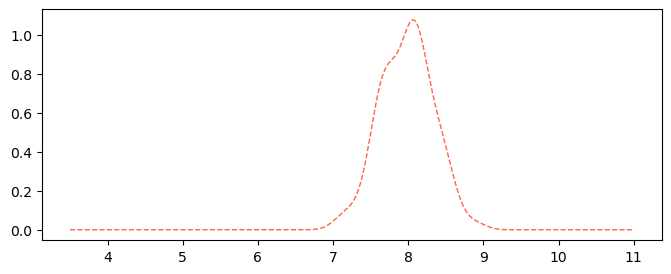

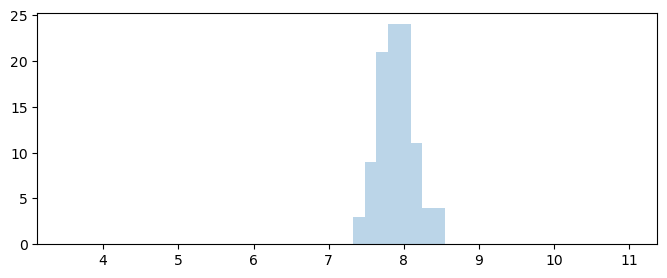

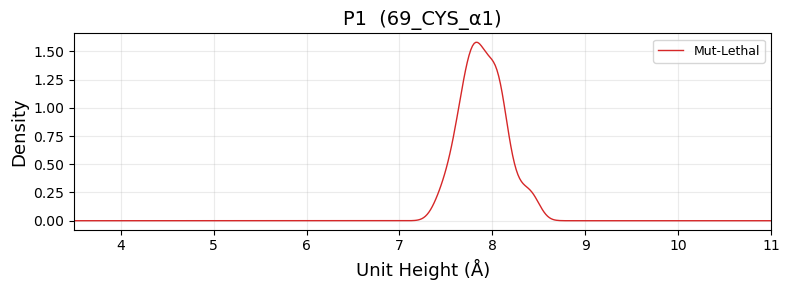

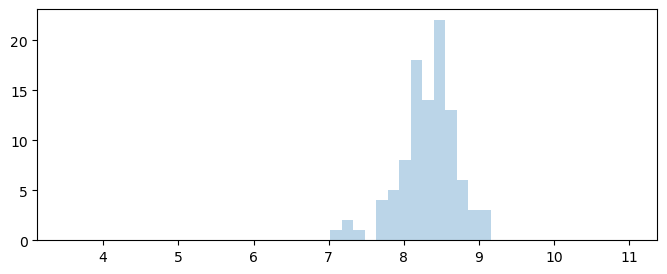

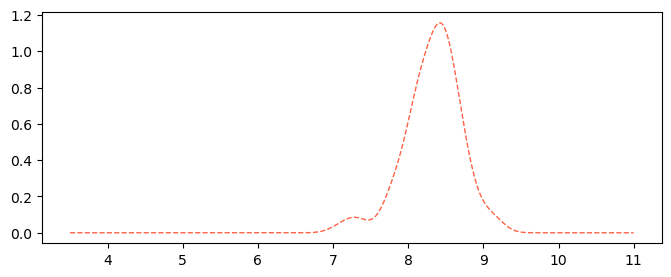

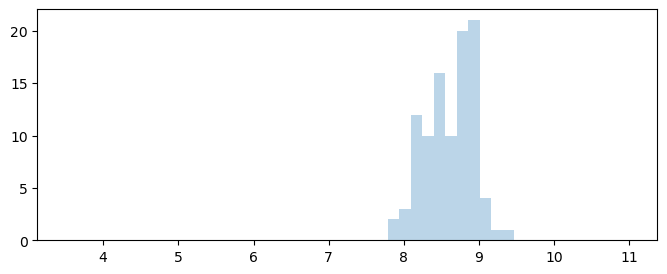

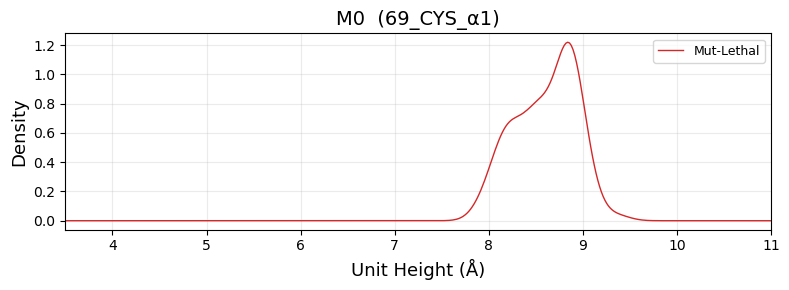

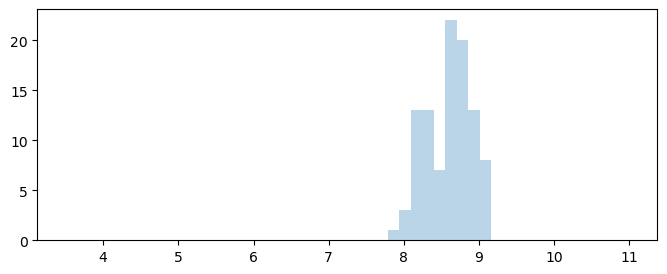

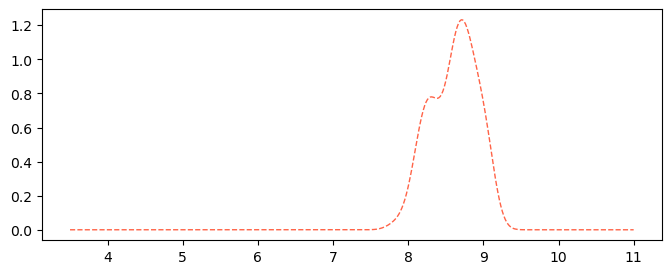

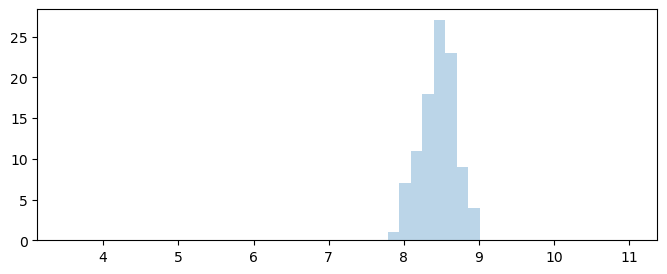

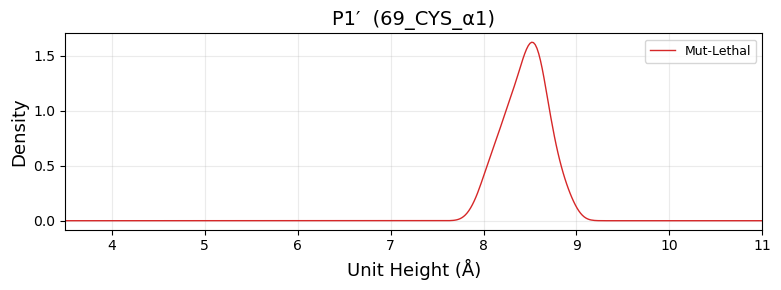

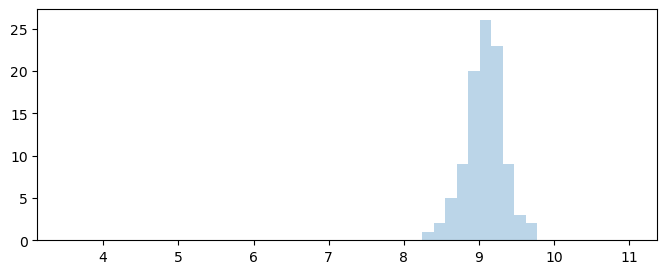

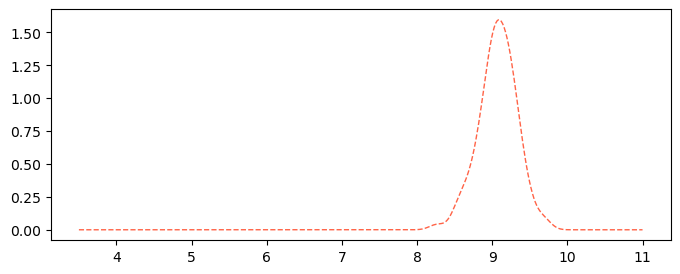

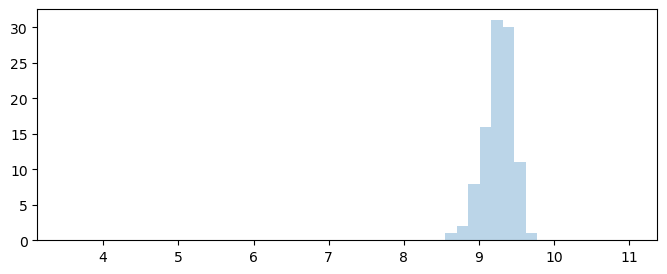

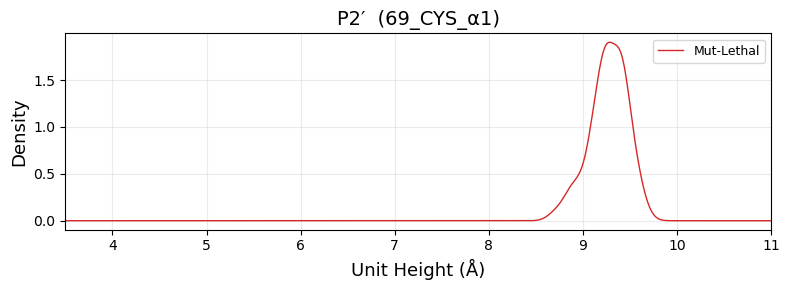

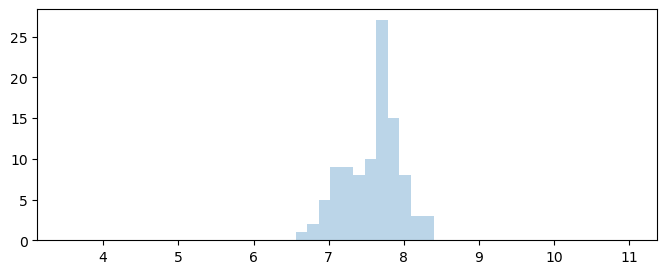

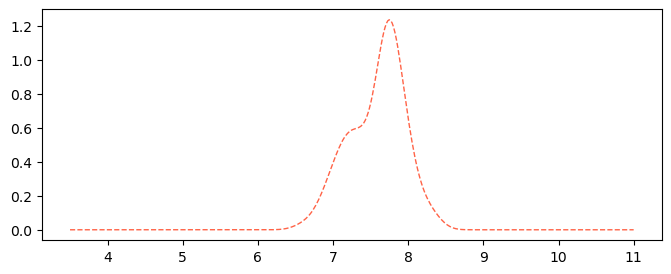

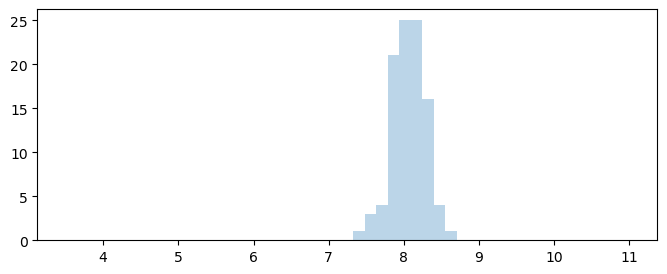

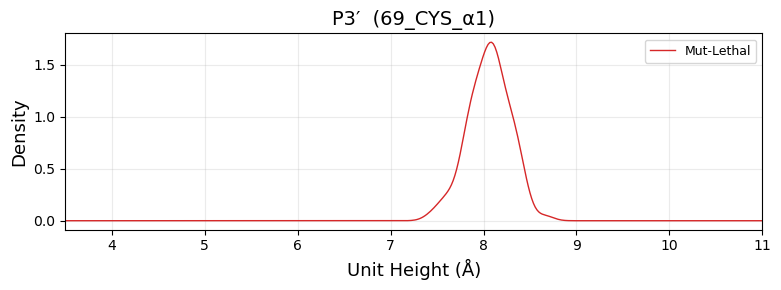

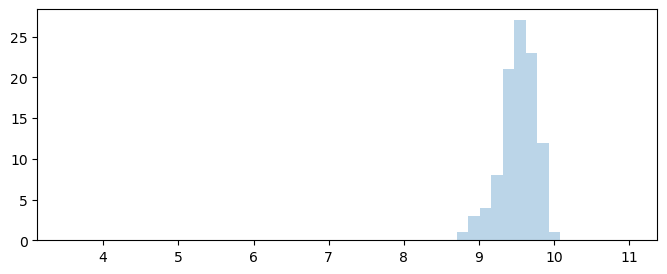

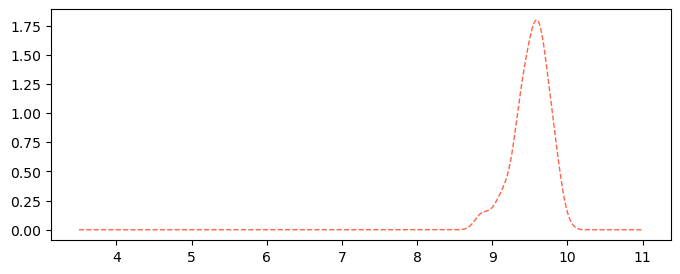

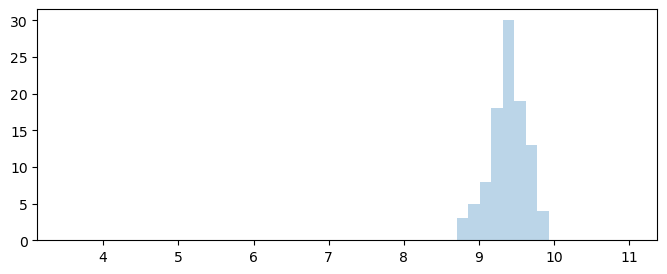

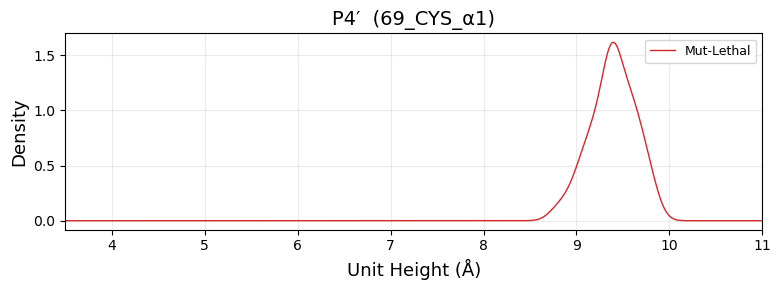

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ------------------------- 共用設定 -------------------------
POS_LABS = ["P4","P3","P2","P1","M0","P1′","P2′","P3′","P4′"]
COLORS   = ["#ff1493","#227700","#ffd700","#00ffff",
            "#000000","#4575b4","#542788","#cc0000","#00ff00"]

# ── GPO 參考 KDE (triplet 2–9) ────────────────────────────
combined  = gpo_unit_hei_traj[:, 1:].ravel()
xs_gpo    = np.linspace(combined.min()*0.9, combined.max()*1.1, 300)
ys_gpo    = gaussian_kde(combined, bw_method=0.7)(xs_gpo)
peak_gpo  = xs_gpo[np.argmax(ys_gpo)]


# --------------------- 主繪圖函式 --------------------------
def plot_kde_onepos_wt_vs_mut(data_mut, data_wt, meta,
                              pos_label="M0", t_title="Unit Height",
                              triplet_sel=69):
    """
    畫出單一位置 (如 M0) 的 KDE，Mut/WT 對照，CYS, α1, 指定 triplet。
    """
    idx = POS_LABS.index(pos_label)

    # 資料展開
    n_mut, n_frames, n_pos = data_mut.shape
    data_mut_2d = data_mut.reshape(n_mut * n_frames, n_pos)
    data_wt_2d  = data_wt.reshape(n_mut * n_frames, n_pos)

    # meta 展開
    mut  = np.repeat(np.asarray(meta["mutation_name_arr"]).astype(str), n_frames)
    leth = np.repeat(np.asarray(meta["lethal_arr"]), n_frames)
    tripnum = np.repeat(np.asarray(meta["triplet_number"]), n_frames)
    a12  = np.repeat(np.asarray(meta["alpha12_arr"]), n_frames)

    # 篩選條件
    mask_sel = (tripnum == triplet_sel) & (a12 == 1) & (mut == "CYS")
    mut_sel  = data_mut_2d[mask_sel]
    wt_sel   = data_wt_2d[mask_sel]
    leth_sel = leth[mask_sel]

    # lethal / nonlethal
    m_L = leth_sel == 0
    m_N = leth_sel == 1

    samples = dict(
        WT_L  = wt_sel [m_L, idx],
        WT_N  = wt_sel [m_N, idx],
        MUT_L = mut_sel[m_L, idx],
        MUT_N = mut_sel[m_N, idx],
    )

    if all(v.size == 0 for v in samples.values()):
        print(f"No data for {pos_label}")
        return

    # KDE 範圍
    all_vals = np.concatenate([v for v in samples.values() if v.size])
    xs = np.linspace(3.5, 11, 400)

    # plt.figure(figsize=(8, 3))
    style = dict(
        WT_L  = dict(color='tomato',      ls='--', lw=1, label='WT-Lethal'),
        WT_N  = dict(color='deepskyblue', ls='--', lw=1, label='WT-Nonlethal'),
        MUT_L = dict(color='#d62728',     lw=1,   label='Mut-Lethal'),
        MUT_N = dict(color='royalblue',   lw=1,   label='Mut-Nonlethal'),
    )

    for key, vals in samples.items():
        if vals.size == 0: continue
        kde = gaussian_kde(vals, bw_method=0.4)
        plt.figure(figsize=(8, 3))
        bins = np.linspace(3.5, 11, 50)
        hist, bin_edges = np.histogram(vals, bins=bins)
        plt.hist(vals, bins=bins, alpha=0.3)
        plt.figure(figsize=(8, 3))
        plt.plot(xs, kde(xs), **style[key])

    # 疊 GPO
    # plt.plot(xs_gpo, ys_gpo, color='purple', lw=.5, label='GPO')
    # plt.fill_between(xs_gpo, ys_gpo, color='purple', alpha=.1)
    # plt.axvline(peak_gpo, color='purple', ls='--', lw=.5)
    # plt.text(peak_gpo, 1.8, f"{peak_gpo:.2f} Å",
    #          color="purple", ha="center", va="bottom", fontsize=10)

    plt.xlabel(f"{t_title} (Å)", fontsize=13)
    plt.ylabel("Density", fontsize=13)
    plt.xlim(3.5, 11)
    # plt.ylim(0, 1.8)
    plt.title(f"{pos_label}  ({triplet_sel}_CYS_α1)", fontsize=14)
    plt.legend(fontsize=9)
    plt.grid(alpha=.25)
    plt.tight_layout()
    plt.show()  # ✅ 直接顯示不儲存


# ------------------------ 連續顯示 9 張圖 --------------------------
def plot_all9_units_show(data_mut, data_wt, meta, t_title="Unit Height",
                         triplet_sel=69):
    """
    連續顯示9張圖（P4～P4′），不儲存檔案。
    """
    for lbl in POS_LABS:
        plot_kde_onepos_wt_vs_mut(data_mut, data_wt, meta,
                                  pos_label=lbl,
                                  t_title=t_title,
                                  triplet_sel=triplet_sel)
meta = {
    "lethal_arr":     lethal_arr,
    "alpha12_arr":    alpha12_arr,
    "triplet_number": triplet_number_arr,
    "mutation_name_arr": mutation_name_arr
}

plot_all9_units_show(unit_hei_all, unit_hei_wt, meta,
                     t_title="Unit Height", triplet_sel=69)


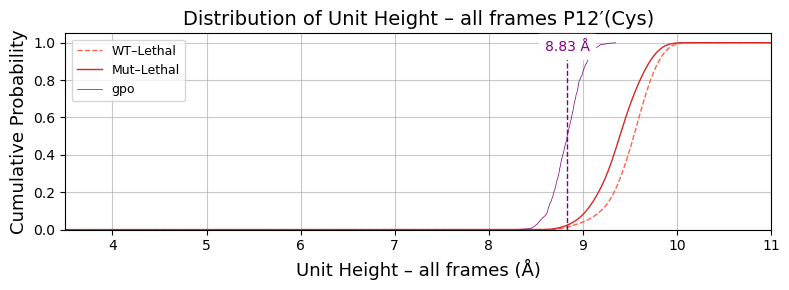

JSD (WT-L vs WT-N): 0.3816
JSD (MUT-L vs WT-L): 0.0474
JSD (MUT-N vs WT-N): 0.0000


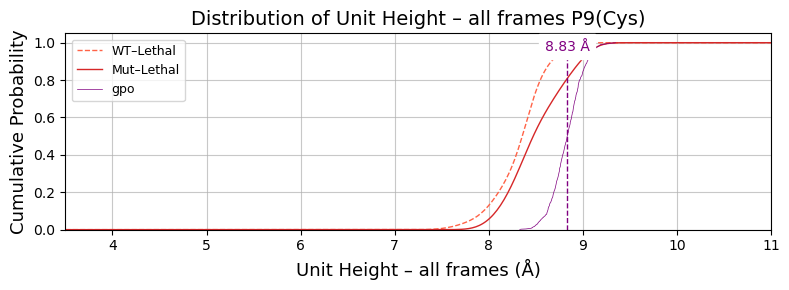

JSD (WT-L vs WT-N): 0.5062
JSD (MUT-L vs WT-L): 0.0823
JSD (MUT-N vs WT-N): 0.0000


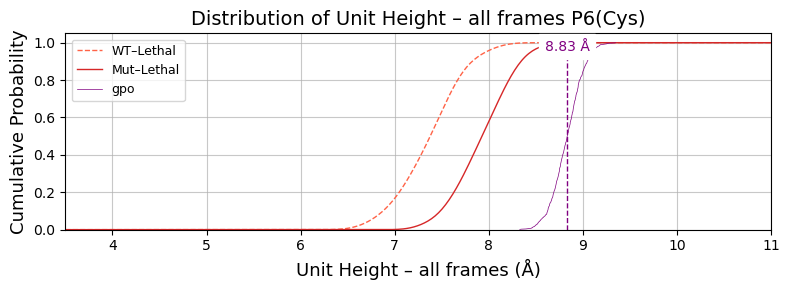

JSD (WT-L vs WT-N): 0.6059
JSD (MUT-L vs WT-L): 0.0768
JSD (MUT-N vs WT-N): 0.0000


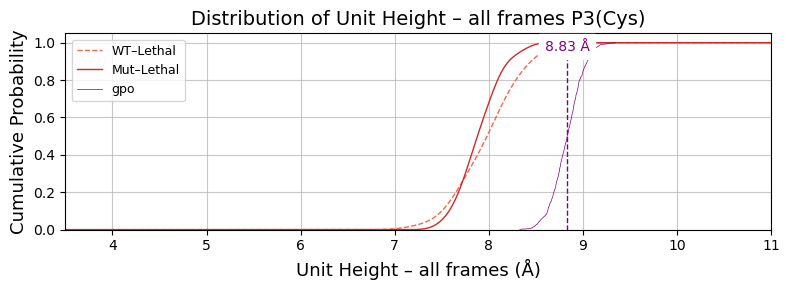

JSD (WT-L vs WT-N): 0.5473
JSD (MUT-L vs WT-L): 0.0785
JSD (MUT-N vs WT-N): 0.0000


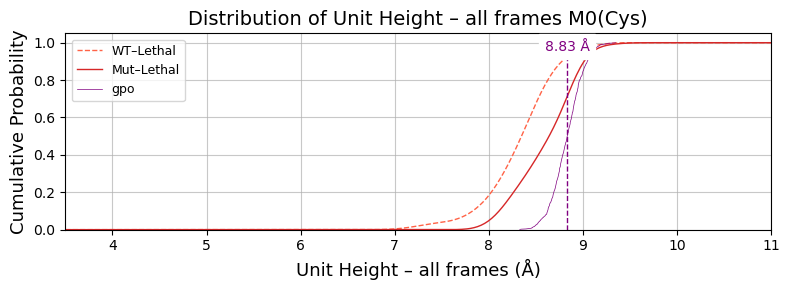

JSD (WT-L vs WT-N): 0.5241
JSD (MUT-L vs WT-L): 0.0746
JSD (MUT-N vs WT-N): 0.0000


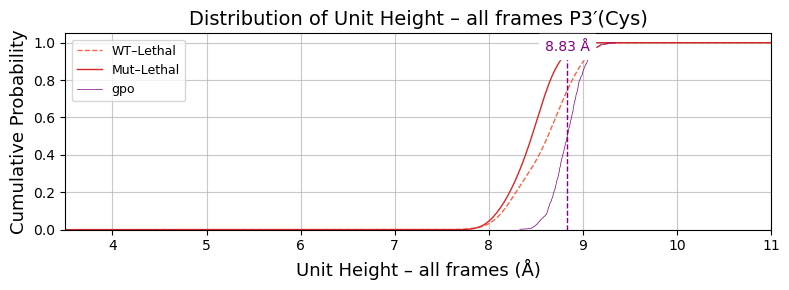

JSD (WT-L vs WT-N): 0.4808
JSD (MUT-L vs WT-L): 0.0608
JSD (MUT-N vs WT-N): 0.0000


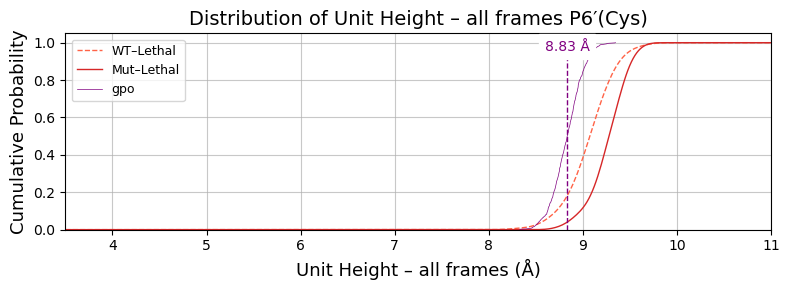

JSD (WT-L vs WT-N): 0.4268
JSD (MUT-L vs WT-L): 0.0608
JSD (MUT-N vs WT-N): 0.0000


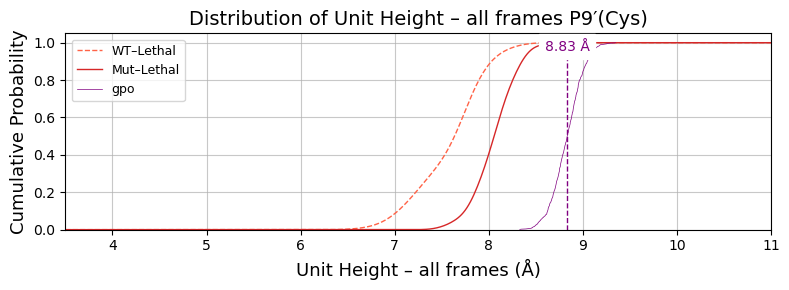

JSD (WT-L vs WT-N): 0.5917
JSD (MUT-L vs WT-L): 0.1096
JSD (MUT-N vs WT-N): 0.0000


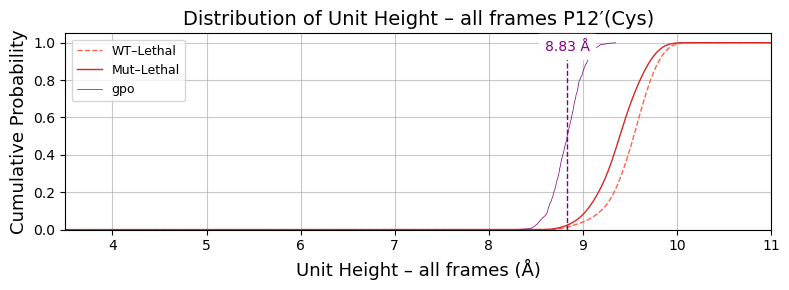

JSD (WT-L vs WT-N): 0.3816
JSD (MUT-L vs WT-L): 0.0474
JSD (MUT-N vs WT-N): 0.0000


In [123]:
###L
from scipy.spatial import distance

def jsd_from_samples(p_samples, q_samples, bins=20, range_=None, base=2, eps=1e-12):
    """
    計算 Jensen-Shannon Divergence (JSD)
    """
    p_samples = np.asarray(p_samples, dtype=float)
    q_samples = np.asarray(q_samples, dtype=float)

    if range_ is None:
        min_val = min(p_samples.min(), q_samples.min())
        max_val = max(p_samples.max(), q_samples.max())
        range_ = (min_val, max_val)

    p_hist, _ = np.histogram(p_samples, bins=bins, range=range_, density=False)
    q_hist, _ = np.histogram(q_samples, bins=bins, range=range_, density=False)
    p = p_hist / p_hist.sum()
    q = q_hist / q_hist.sum()
    p = np.where(p == 0, eps, p)
    q = np.where(q == 0, eps, q)
    m = 0.5 * (p + q)
    m = np.where(m == 0, eps, m)

    jsd = 0.5 * distance.rel_entr(p, m).sum() + 0.5 * distance.rel_entr(q, m).sum()
    jsd /= np.log(base)
    return np.sqrt(jsd)

def calculate_jsd_for_wt_samples(samples):
    """
    計算 `WT-L vs WT-N`，`MUT-L vs WT-L`，`MUT-N vs WT-N` 的 JSD
    """
    # 計算需要的 JSD
    jsd_wt_l_vs_wt_n = jsd_from_samples(samples[:,0], samples[:,1])
    jsd_mut_l_vs_wt_l = jsd_from_samples(samples[:,2], samples[:,0])
    jsd_mut_n_vs_wt_n = jsd_from_samples(samples[:,3], samples[:,1])

    print(f"JSD (WT-L vs WT-N): {jsd_wt_l_vs_wt_n:.4f}")
    print(f"JSD (MUT-L vs WT-L): {jsd_mut_l_vs_wt_l:.4f}")
    print(f"JSD (MUT-N vs WT-N): {jsd_mut_n_vs_wt_n:.4f}")
    
    return {
        "JSD_WT_L_vs_WT_N": jsd_wt_l_vs_wt_n,
        "JSD_MUT_L_vs_WT_L": jsd_mut_l_vs_wt_l,
        "JSD_MUT_N_vs_WT_N": jsd_mut_n_vs_wt_n
    }


def plot_cdf_onepos_wt_vs_mut(
    data_mut, data_wt, meta,
    pos_label="M0",
    t_title="Unit Height",
    triplet_sel=69,
    xlim=None, ylim=(0, 1.05)
):
    """
    data_mut : (N, 9) 或 (N, T, 9) ← mutant（每條 9 位置；或含 T 個時間步）
    data_wt  : (N, 9) 或 (N, T, 9) ← WT
    meta     : dict ← mutation_name(_arr) / lethal_arr / alpha12_arr（長度 N）
               若 data_* 是 3D，會自動 repeat 以對齊攤平後樣本數
    僅取 Cys、α1，並拆成 Lethal / Nonlethal；WT 用相同遮罩。
    """

    # --- 位置索引 ---------------------------------------------------
    pos_labels_all = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]
    if pos_label not in pos_labels_all:
        raise ValueError(f"pos_label 必須是 {pos_labels_all} 之一")
    idx = pos_labels_all.index(pos_label)

    # --- 取得 meta 欄位 ---------------------------------------------
    def _get(meta, base):
        if base in meta: return np.asarray(meta[base])
        if f"{base}_arr" in meta: return np.asarray(meta[f"{base}_arr"])
        raise KeyError(f"meta 缺少：{base} 或 {base}_arr")

    mut_name = _get(meta, "mutation_name").astype(str)
    lethal   = _get(meta, "lethal")
    tripnum  = _get(meta, "triplet_number")
    alpha12  = _get(meta, "alpha12")

    # --- 攤平資料 & 同步 repeat meta -------------------------------
    def _flatten_and_repeat(data, tripnum, mut_name, lethal, alpha12):
        if data.ndim == 3:
            N, T, P = data.shape
            assert P == 9, f"最後一維應為 9，取得 {P}"
            data2d  = data.reshape(N*T, P)
            return (data2d,
                    np.repeat(tripnum, T),
                    np.repeat(mut_name, T),
                    np.repeat(lethal,   T),
                    np.repeat(alpha12,  T))
        elif data.ndim == 2:
            return data, tripnum, mut_name, lethal, alpha12
        else:
            raise ValueError("data_* 形狀需為 (N,9) 或 (N,T,9)")

    mut2d, tripnum_r, mut_name_r, leth_r, a12_r = _flatten_and_repeat(data_mut, tripnum, mut_name, lethal, alpha12)
    wt2d,  tripnum_r, mut_name_r, leth_r, a12_r = _flatten_and_repeat(data_wt,  tripnum, mut_name, lethal, alpha12)

    # --- 只取 Cys，僅 α1，拆 lethal / non-lethal -------------------
    mask_sel = (tripnum_r == triplet_sel) & (a12_r == 1) & (mut_name_r == "CYS")
    mut_69_cys_1  = mut2d[mask_sel]
    wt_69_cys_1   = wt2d[mask_sel]
    leth_69_cys_1 = leth_r[mask_sel]

    mask_lethal    =  (leth_69_cys_1 == 0)
    mask_nonlethal =  (leth_69_cys_1 == 1)

    # --- 收集樣本 --------------------------------------------------
    samples = dict(
        WT_L   = wt_69_cys_1[mask_lethal,    idx],
        WT_N   = wt_69_cys_1[mask_nonlethal, idx],
        MUT_L  = mut_69_cys_1[mask_lethal,   idx],
        MUT_N  = mut_69_cys_1[mask_nonlethal,idx],
    )
    
    if not any(v.size for v in samples.values()):
        print(f"[警告] {pos_label} 在目前遮罩下沒有樣本可畫。")
        return

    # --- 決定 X 範圍（含 GPO） -------------------------------------
    vals_list = [v for v in samples.values() if v.size]
    all_vals = np.concatenate(vals_list)
    if 'gpo_unit_hei_traj' in globals():
        gpo_vals = gpo_unit_hei_traj[:, 1:].ravel()
        if gpo_vals.size:
            all_vals = np.concatenate([all_vals, gpo_vals])

    if xlim is None:
        x_min, x_max = all_vals.min()*0.9, all_vals.max()*1.1
    else:
        x_min, x_max = xlim

    # --- 繪圖 -------------------------------------------------------
    xs = np.linspace(3.5, 11, 400)
    dx = (11-3.5)/399
    plt.figure(figsize=(8, 3))

    style = dict(
        WT_L  = dict(color='tomato',      ls='--', lw=1, label='WT–Lethal'),
        WT_N  = dict(color='deepskyblue', ls='--', lw=1, label='WT–Nonlethal'),
        MUT_L = dict(color='#d62728',     lw=1,    label='Mut–Lethal'),
        MUT_N = dict(color='royalblue',   lw=1,    label='Mut–Nonlethal'),
    )

    # 畫 ECDF

    kde_all = np.zeros((400,4))
    i = 0
    for key, vals in samples.items():
        if vals.size == 0:
            i = i + 1
            continue
        kde = gaussian_kde(vals,0.4)
        Y= kde(xs)/(dx*kde(xs)).sum()
        C_kde =np.cumsum(Y*dx)
        # plt.plot(xs, kde(xs), **style[key], alpha = 0.3)
        plt.plot(xs, C_kde, **style[key])
        kde_all[:,i] = C_kde
        i = i + 1   
    
    # 疊上 gpo（triplet 2–9）— CDF
    if 'gpo_unit_hei_traj' in globals():
        combined_vals = gpo_unit_hei_traj[:, 1:].ravel()
        if combined_vals.size:
            xs_c = np.sort(combined_vals)
            ys_c = np.arange(1, len(xs_c)+1) / len(xs_c)
            plt.plot(xs_c, ys_c, color="purple", lw=0.5, label="gpo")
            # plt.fill_between(xs_c, ys_c, linestyle='--', color="purple", alpha=0.1)

            # 標記中位數
            median_x = np.median(combined_vals)
            plt.axvline(median_x, color="purple", linestyle="--", linewidth=1)
            plt.text(median_x, 0.94,
                     f"{median_x:.2f} Å",
                     color="purple", ha="center", va="bottom",
                     fontsize=10, backgroundcolor="white")

    # 軸 & 標題
    plt.xlabel(f"{t_title} (Å)", fontsize=13)
    plt.ylabel("Cumulative Probability", fontsize=13)
    plt.xlim(3.5, 11)
    plt.ylim(*ylim)
    plt.title(f"Distribution of {t_title} {pos_label}(Cys)", fontsize=14)
    plt.legend(fontsize=9)
    plt.grid(True, alpha=.69)
    plt.tight_layout()
    plt.show()
    return kde_all

for lbl in pos_labels_all:
    kde_all = plot_cdf_onepos_wt_vs_mut(
        unit_hei_all,
        unit_hei_wt,
        meta,
        pos_label=lbl,
        t_title="Unit Height – all frames",
        triplet_sel=69,
        xlim=None, ylim=(0, 1.05)
    )
    calculate_jsd_for_wt_samples(kde_all)


### CDF

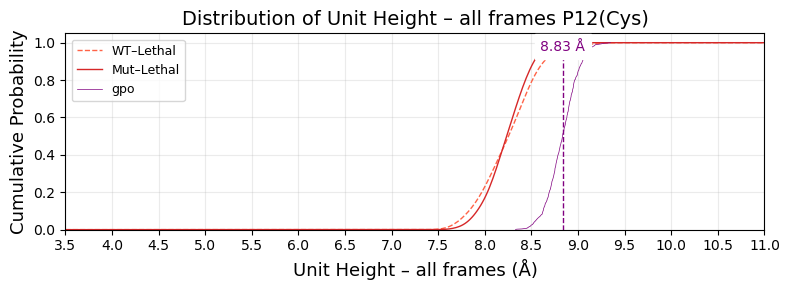

JSD (WT-L vs WT-N): 0.5134
JSD (MUT-L vs WT-L): 0.0638
JSD (MUT-N vs WT-N): 0.0000


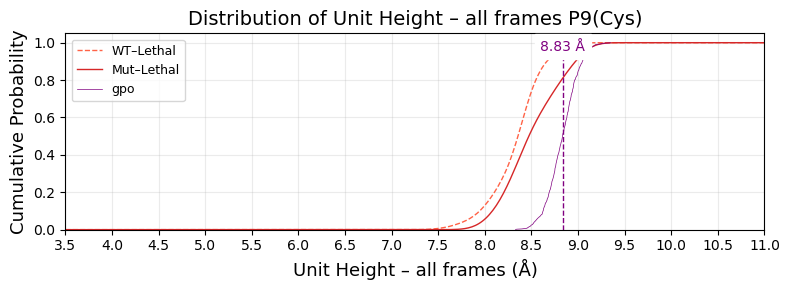

JSD (WT-L vs WT-N): 0.5062
JSD (MUT-L vs WT-L): 0.0823
JSD (MUT-N vs WT-N): 0.0000


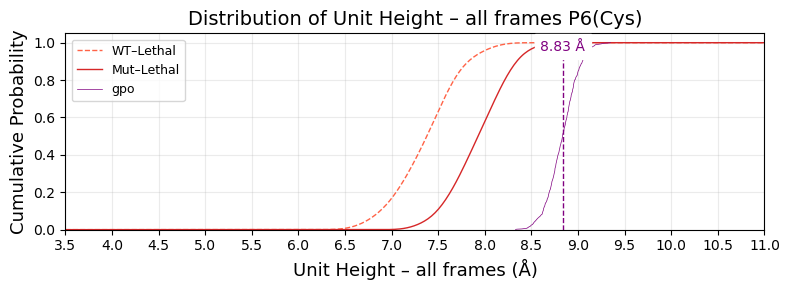

JSD (WT-L vs WT-N): 0.6059
JSD (MUT-L vs WT-L): 0.0768
JSD (MUT-N vs WT-N): 0.0000


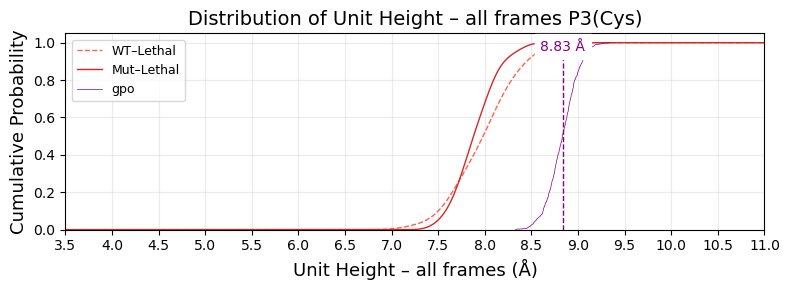

JSD (WT-L vs WT-N): 0.5473
JSD (MUT-L vs WT-L): 0.0785
JSD (MUT-N vs WT-N): 0.0000


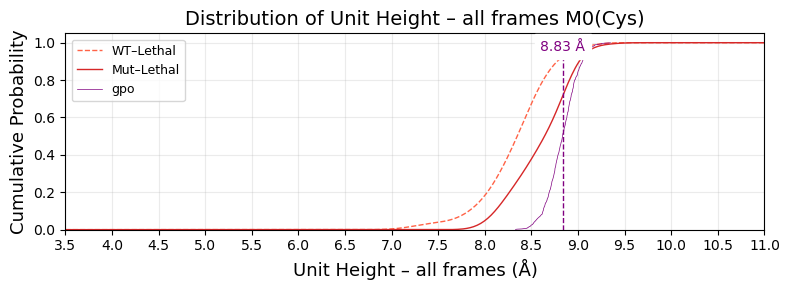

JSD (WT-L vs WT-N): 0.5241
JSD (MUT-L vs WT-L): 0.0746
JSD (MUT-N vs WT-N): 0.0000


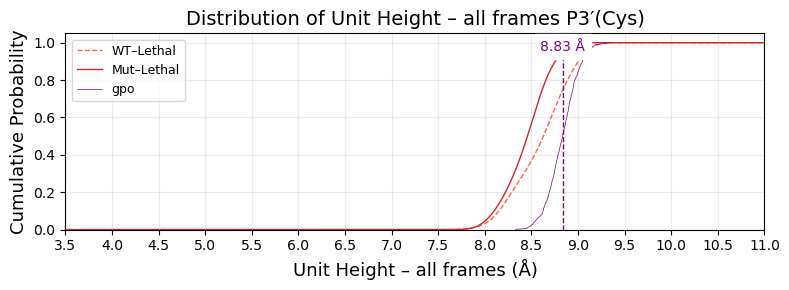

JSD (WT-L vs WT-N): 0.4808
JSD (MUT-L vs WT-L): 0.0608
JSD (MUT-N vs WT-N): 0.0000


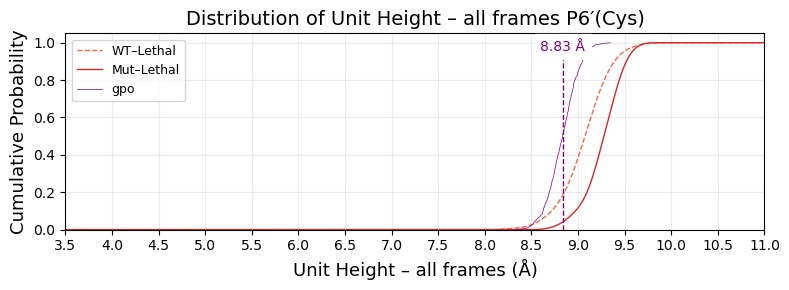

JSD (WT-L vs WT-N): 0.4268
JSD (MUT-L vs WT-L): 0.0608
JSD (MUT-N vs WT-N): 0.0000


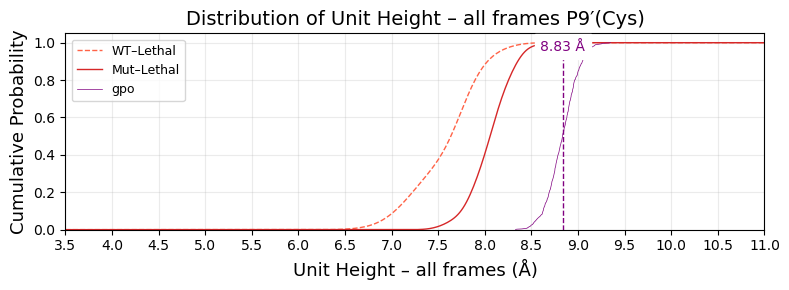

JSD (WT-L vs WT-N): 0.5917
JSD (MUT-L vs WT-L): 0.1096
JSD (MUT-N vs WT-N): 0.0000


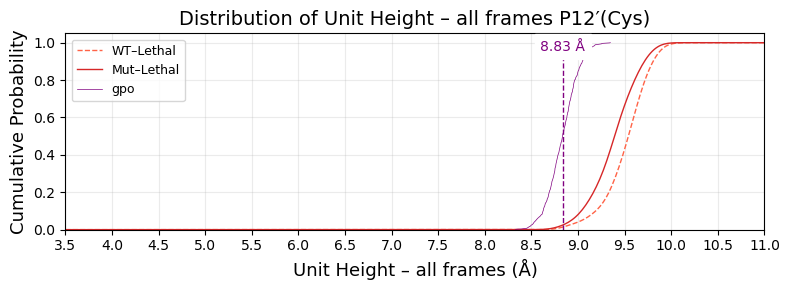

JSD (WT-L vs WT-N): 0.3816
JSD (MUT-L vs WT-L): 0.0474
JSD (MUT-N vs WT-N): 0.0000


In [ ]:
from scipy.spatial import distance

def jsd_from_samples(p_samples, q_samples, bins=20, range_=None, base=2, eps=1e-12):
    """
    計算 Jensen-Shannon Divergence (JSD)
    """
    p_samples = np.asarray(p_samples, dtype=float)
    q_samples = np.asarray(q_samples, dtype=float)

    if range_ is None:
        min_val = min(p_samples.min(), q_samples.min())
        max_val = max(p_samples.max(), q_samples.max())
        range_ = (min_val, max_val)

    p_hist, _ = np.histogram(p_samples, bins=bins, range=range_, density=False)
    q_hist, _ = np.histogram(q_samples, bins=bins, range=range_, density=False)
    p = p_hist / p_hist.sum()
    q = q_hist / q_hist.sum()
    p = np.where(p == 0, eps, p)
    q = np.where(q == 0, eps, q)
    m = 0.5 * (p + q)
    m = np.where(m == 0, eps, m)

    jsd = 0.5 * distance.rel_entr(p, m).sum() + 0.5 * distance.rel_entr(q, m).sum()
    jsd /= np.log(base)
    return np.sqrt(jsd)

def calculate_jsd_for_wt_samples(samples):
    """
    計算 `WT-L vs WT-N`，`MUT-L vs WT-L`，`MUT-N vs WT-N` 的 JSD
    """
    # 計算需要的 JSD
    jsd_wt_l_vs_wt_n = jsd_from_samples(samples[:,0], samples[:,1])
    jsd_mut_l_vs_wt_l = jsd_from_samples(samples[:,2], samples[:,0])
    jsd_mut_n_vs_wt_n = jsd_from_samples(samples[:,3], samples[:,1])

    print(f"JSD (WT-L vs WT-N): {jsd_wt_l_vs_wt_n:.4f}")
    print(f"JSD (MUT-L vs WT-L): {jsd_mut_l_vs_wt_l:.4f}")
    print(f"JSD (MUT-N vs WT-N): {jsd_mut_n_vs_wt_n:.4f}")
    
    return {
        "JSD_WT_L_vs_WT_N": jsd_wt_l_vs_wt_n,
        "JSD_MUT_L_vs_WT_L": jsd_mut_l_vs_wt_l,
        "JSD_MUT_N_vs_WT_N": jsd_mut_n_vs_wt_n
    }


def plot_cdf_onepos_wt_vs_mut(
    data_mut, data_wt, meta,
    pos_label="M0",
    t_title="Unit Height",
    triplet_sel=69,
    xlim=None, ylim=(0, 1.05)
):
    """
    data_mut : (N, 9) 或 (N, T, 9) ← mutant（每條 9 位置；或含 T 個時間步）
    data_wt  : (N, 9) 或 (N, T, 9) ← WT
    meta     : dict ← mutation_name(_arr) / lethal_arr / alpha12_arr（長度 N）
               若 data_* 是 3D，會自動 repeat 以對齊攤平後樣本數
    僅取 Cys、α1，並拆成 Lethal / Nonlethal；WT 用相同遮罩。
    """

    # --- 位置索引 ---------------------------------------------------
    pos_labels_all = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]
    if pos_label not in pos_labels_all:
        raise ValueError(f"pos_label 必須是 {pos_labels_all} 之一")
    idx = pos_labels_all.index(pos_label)

    # --- 取得 meta 欄位 ---------------------------------------------
    def _get(meta, base):
        if base in meta: return np.asarray(meta[base])
        if f"{base}_arr" in meta: return np.asarray(meta[f"{base}_arr"])
        raise KeyError(f"meta 缺少：{base} 或 {base}_arr")

    mut_name = _get(meta, "mutation_name").astype(str)
    lethal   = _get(meta, "lethal")
    tripnum  = _get(meta, "triplet_number")
    alpha12  = _get(meta, "alpha12")

    # --- 攤平資料 & 同步 repeat meta -------------------------------
    def _flatten_and_repeat(data, tripnum, mut_name, lethal, alpha12):
        if data.ndim == 3:
            N, T, P = data.shape
            assert P == 9, f"最後一維應為 9，取得 {P}"
            data2d  = data.reshape(N*T, P)
            return (data2d,
                    np.repeat(tripnum, T),
                    np.repeat(mut_name, T),
                    np.repeat(lethal,   T),
                    np.repeat(alpha12,  T))
        elif data.ndim == 2:
            return data, tripnum, mut_name, lethal, alpha12
        else:
            raise ValueError("data_* 形狀需為 (N,9) 或 (N,T,9)")

    mut2d, tripnum_r, mut_name_r, leth_r, a12_r = _flatten_and_repeat(data_mut, tripnum, mut_name, lethal, alpha12)
    wt2d,  tripnum_r, mut_name_r, leth_r, a12_r = _flatten_and_repeat(data_wt,  tripnum, mut_name, lethal, alpha12)

    # --- 只取 Cys，僅 α1，拆 lethal / non-lethal -------------------
    mask_sel = (tripnum_r == triplet_sel) & (a12_r == 1) & (mut_name_r == "CYS")
    mut_25_cys_1  = mut2d[mask_sel]
    wt_25_cys_1   = wt2d[mask_sel]
    leth_25_cys_1 = leth_r[mask_sel]

    mask_lethal    =  (leth_25_cys_1 == 0)
    mask_nonlethal =  (leth_25_cys_1 == 1)

    # --- 收集樣本 --------------------------------------------------
    samples = dict(
        WT_L   = wt_25_cys_1[mask_lethal,    idx],
        WT_N   = wt_25_cys_1[mask_nonlethal, idx],
        MUT_L  = mut_25_cys_1[mask_lethal,   idx],
        MUT_N  = mut_25_cys_1[mask_nonlethal,idx],
    )
    
    if not any(v.size for v in samples.values()):
        print(f"[警告] {pos_label} 在目前遮罩下沒有樣本可畫。")
        return

    # --- 決定 X 範圍（含 GPO） -------------------------------------
    vals_list = [v for v in samples.values() if v.size]
    all_vals = np.concatenate(vals_list)
    if 'gpo_unit_hei_traj' in globals():
        gpo_vals = gpo_unit_hei_traj[:, 1:].ravel()
        if gpo_vals.size:
            all_vals = np.concatenate([all_vals, gpo_vals])

    if xlim is None:
        x_min, x_max = all_vals.min()*0.9, all_vals.max()*1.1
    else:
        x_min, x_max = xlim

    # --- 繪圖 -------------------------------------------------------
    xs = np.linspace(3.5, 11, 400)
    dx = (11-3.5)/399
    plt.figure(figsize=(8, 3))

    style = dict(
        WT_L  = dict(color='tomato',      ls='--', lw=1, label='WT–Lethal'),
        WT_N  = dict(color='deepskyblue', ls='--', lw=1, label='WT–Nonlethal'),
        MUT_L = dict(color='#d62728',     lw=1,    label='Mut–Lethal'),
        MUT_N = dict(color='royalblue',   lw=1,    label='Mut–Nonlethal'),
    )

    # 畫 ECDF

    kde_all = np.zeros((400,4))
    i = 0
    for key, vals in samples.items():
        if vals.size == 0:
            i = i + 1
            continue
        kde = gaussian_kde(vals,0.4)
        Y= kde(xs)/(dx*kde(xs)).sum()
        C_kde =np.cumsum(Y*dx)
        # plt.plot(xs, kde(xs), **style[key], alpha = 0.3)
        plt.plot(xs, C_kde, **style[key])
        kde_all[:,i] = C_kde
        i = i + 1  
    
    # 疊上 gpo（triplet 2–9）— CDF
    if 'gpo_unit_hei_traj' in globals():
        combined_vals = gpo_unit_hei_traj[:, 1:].ravel()
        if combined_vals.size:
            xs_c = np.sort(combined_vals)
            ys_c = np.arange(1, len(xs_c)+1) / len(xs_c)
            plt.plot(xs_c, ys_c, color="purple", lw=0.5, label="gpo")
            # plt.fill_between(xs_c, ys_c, linestyle='--', color="purple", alpha=0.1)

            # 標記中位數
            median_x = np.median(combined_vals)
            plt.axvline(median_x, color="purple", linestyle="--", linewidth=1)
            plt.text(median_x, 0.94,
                     f"{median_x:.2f} Å",
                     color="purple", ha="center", va="bottom",
                     fontsize=10, backgroundcolor="white")
    # 設置 X 軸刻度
    x_ticks = np.arange(3.5, 11.5, 0.5)  # 例如每隔 0.5 顯示一個刻度
    plt.xticks(x_ticks)  # 設定刻度

    # 軸 & 標題
    plt.xlabel(f"{t_title} (Å)", fontsize=13)
    plt.ylabel("Cumulative Probability", fontsize=13)
    plt.xlim(3.5, 11)
    plt.ylim(*ylim)
    plt.title(f"Distribution of {t_title} {pos_label}(Cys)", fontsize=14)
    plt.legend(fontsize=9)
    plt.grid(True, alpha=.25)
    plt.tight_layout()
    plt.show()
    return kde_all

for lbl in pos_labels_all:
    kde_all = plot_cdf_onepos_wt_vs_mut(
        unit_hei_all,
        unit_hei_wt,
        meta,
        pos_label=lbl,
        t_title="Unit Height – all frames",
        triplet_sel=69,
        xlim=None, ylim=(0, 1.05)
    )
    calculate_jsd_for_wt_samples(kde_all)


## 100frames_587mut

In [258]:
save_dir = r"D:\collagen\figures\100frames_587mut"            # 存圖資料夾
os.makedirs(save_dir, exist_ok=True)

for i in range(radius_wt.shape[0]):
    plt.figure(figsize=(5,7))
    plt.boxplot(radius_all[i,:,:],medianprops=dict(color="black"), zorder=1)
    plt.scatter(np.arange(9)+1, radius_all[i,-1,:], marker='*', color = 'yellow', edgecolor = 'black', s = 150, alpha=0.9, zorder=2)
    plt.scatter(np.arange(9)+1, radius_avg[i,:], marker='*', color = 'skyblue', edgecolor = 'black', s = 150, alpha=0.9, zorder=3)
    xlabel = ["P4","P3","P2","P1","M0","P1'","P2'","P3'","P4'"]
    plt.xticks(np.arange(9)+1,xlabel, fontsize=12)
    plt.yticks(fontsize = 12)
    plt.ylabel("Radius (Å)", fontsize=14)
    title = f"{triplet_number[i]}_{mutation_name[i]}_{alpha12[i]}"
    plt.title(title, fontsize=14)

    fname = f"{title}.png".replace("/", "_")   # 防止路徑符號
    plt.savefig(os.path.join(save_dir, fname), dpi=300, bbox_inches="tight")
    plt.close()         # 關閉，避免記憶體佔用
print(f"✔ All figures saved to: {save_dir}")

✔ All figures saved to: D:\collagen\figures\100frames_587mut


## ppt要用的圖

### all wt分布圖

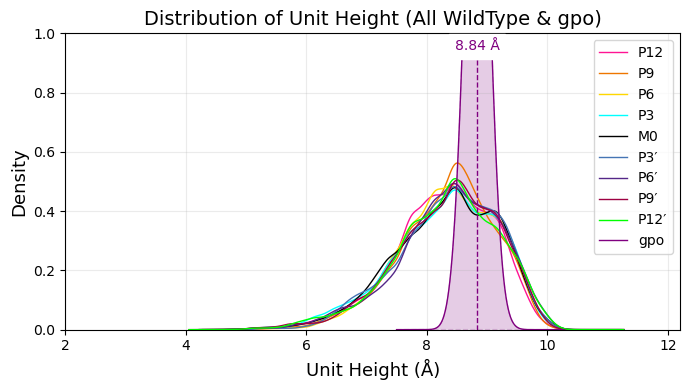

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# -------------------------------------------------
# 1️⃣ 定義要畫的那些位置
positions_to_plot = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]
pos_labels_all    = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]
idx_map           = {lbl: i for i, lbl in enumerate(pos_labels_all)}
idx_to_plot       = [idx_map[lbl] for lbl in positions_to_plot]

# ✅ 指向你的資料：可放 (N,9) 或 (N,100,9)
# 例如：
# data_any = unit_hei_avg        # (587, 9)
# 或
# data_any = unit_hei_wt        # (587, 100, 9)
data_any = unit_hei_wt

# 2️⃣ 攤平成 (N*frames, 9)（若本來是 2D 就保持不變）
if data_any.ndim == 3:
    N, T, P = data_any.shape
    assert P == 9, f"最後一維應為 9，取得 {P}"
    data2d = data_any.reshape(N * T, P)
elif data_any.ndim == 2:
    data2d = data_any
else:
    raise ValueError("資料形狀需為 (N,9) 或 (N,100,9)")

# 把 9 個位置的資料放進 dict
samples_dict = {
    lbl: data2d[:, idx]
    for lbl, idx in zip(positions_to_plot, idx_to_plot)
}

# 3️⃣ 準備合併 triplets 2–9 的 gpo（保持你的作法）
combined_vals = gpo_unit_hei_traj[:, 1:].ravel()  # 取出索引 1–8 (即 triplet 2–9)

# 4️⃣ 開圖
fig, ax = plt.subplots(figsize=(7, 4))

# 5️⃣ 畫各 position 的 KDE
colors = ["#ff1493", "#ee7600", "#ffd700", "#00ffff",
          "#000000", "#4575b4", "#542788", "#9e0142", "#00ff00"]

for lbl, color in zip(positions_to_plot, colors):
    vals = samples_dict[lbl]
    if vals.size == 0:
        continue
    kde = gaussian_kde(vals)  # 沿用預設（Scott’s Rule）；想固定可改 bw_method=0.45
    # 這裡維持你原本每條各自的 x 範圍計算
    xs  = np.linspace(vals.min() * 0.9, vals.max() * 1.1, 300)
    ys  = kde(xs)
    ax.plot(xs, ys, color=color, lw=1, label=lbl)

# 疊上 combined triplet 2–9 的 KDE
kde_c = gaussian_kde(combined_vals, bw_method=0.7)
# 這裡也維持你的作法，用 gpo 自己的範圍
xs_c  = np.linspace(combined_vals.min() * 0.9,
                    combined_vals.max() * 1.1, 300)
ys_c  = kde_c(xs_c)
ax.plot(xs_c, ys_c, color="purple", lw=1, label="gpo")
ax.fill_between(xs_c, ys_c, linestyle='--', color="purple", alpha=0.2)

# 峰值位置與標線
peak_x = xs_c[np.argmax(ys_c)]
ax.axvline(peak_x, color="purple", linestyle="--", linewidth=1)
ax.text(peak_x, 0.932, f"{peak_x:.2f} Å",
        color="purple", ha="center", va="bottom",
        fontsize=10, backgroundcolor="white")

# 格式化
ax.set_xlabel("Unit Height (Å)", fontsize=13)  # 你的資料是 unit_hei_*，這裡幫你正名
ax.set_ylabel("Density",         fontsize=13)
ax.set_xlim(2, 12.2)             # 仍保留你手動設定的 X 範圍
ax.set_ylim(0, 1)                # 仍保留你手動設定的 Y 範圍
ax.set_title("Distribution of Unit Height (All WildType & gpo)", fontsize=14)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=10, ncol=1, loc="upper right")

plt.tight_layout()
plt.show()


### all mut 分布圖

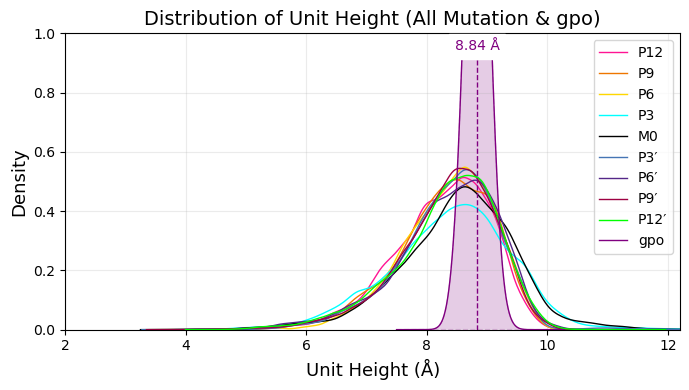

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# -------------------------------------------------
# 1️⃣ 定義要畫的那些位置
positions_to_plot = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]
pos_labels_all    = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]
idx_map           = {lbl: i for i, lbl in enumerate(pos_labels_all)}
idx_to_plot       = [idx_map[lbl] for lbl in positions_to_plot]

# ✅ 指向你的資料：可放 (N,9) 或 (N,100,9)
# 例如：
# data_any = unit_hei_avg        # (587, 9)
# 或
# data_any = unit_hei_all        # (587, 100, 9)
data_any = unit_hei_all

# 2️⃣ 攤平成 (N*frames, 9)（若本來是 2D 就保持不變）
if data_any.ndim == 3:
    N, T, P = data_any.shape
    assert P == 9, f"最後一維應為 9，取得 {P}"
    data2d = data_any.reshape(N * T, P)
elif data_any.ndim == 2:
    data2d = data_any
else:
    raise ValueError("資料形狀需為 (N,9) 或 (N,100,9)")

# 把 9 個位置的資料放進 dict
samples_dict = {
    lbl: data2d[:, idx]
    for lbl, idx in zip(positions_to_plot, idx_to_plot)
}

# 3️⃣ 準備合併 triplets 2–9 的 gpo（保持你的作法）
combined_vals = gpo_unit_hei_traj[:, 1:].ravel()  # 取出索引 1–8 (即 triplet 2–9)

# 4️⃣ 開圖
fig, ax = plt.subplots(figsize=(7, 4))

# 5️⃣ 畫各 position 的 KDE
colors = ["#ff1493", "#ee7600", "#ffd700", "#00ffff",
          "#000000", "#4575b4", "#542788", "#9e0142", "#00ff00"]

for lbl, color in zip(positions_to_plot, colors):
    vals = samples_dict[lbl]
    if vals.size == 0:
        continue
    kde = gaussian_kde(vals)  # 沿用預設（Scott’s Rule）；想固定可改 bw_method=0.45
    # 這裡維持你原本每條各自的 x 範圍計算
    xs  = np.linspace(vals.min() * 0.9, vals.max() * 1.1, 300)
    ys  = kde(xs)
    ax.plot(xs, ys, color=color, lw=1, label=lbl)

# 疊上 combined triplet 2–9 的 KDE
kde_c = gaussian_kde(combined_vals, bw_method=0.7)
# 這裡也維持你的作法，用 gpo 自己的範圍
xs_c  = np.linspace(combined_vals.min() * 0.9,
                    combined_vals.max() * 1.1, 300)
ys_c  = kde_c(xs_c)
ax.plot(xs_c, ys_c, color="purple", lw=1, label="gpo")
ax.fill_between(xs_c, ys_c, linestyle='--', color="purple", alpha=0.2)

# 峰值位置與標線
peak_x = xs_c[np.argmax(ys_c)]
ax.axvline(peak_x, color="purple", linestyle="--", linewidth=1)
ax.text(peak_x, 0.932, f"{peak_x:.2f} Å",
        color="purple", ha="center", va="bottom",
        fontsize=10, backgroundcolor="white")

# 格式化
ax.set_xlabel("Unit Height (Å)", fontsize=13)  # 你的資料是 unit_hei_*，這裡幫你正名
ax.set_ylabel("Density",         fontsize=13)
ax.set_xlim(2, 12.2)             # 仍保留你手動設定的 X 範圍
ax.set_ylim(0, 1)                # 仍保留你手動設定的 Y 範圍
ax.set_title("Distribution of Unit Height (All Mutation & gpo)", fontsize=14)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=10, ncol=1, loc="upper right")

plt.tight_layout()
plt.show()


### 星星點狀圖

#### 587張

In [ ]:
import os
import numpy as np
import matplotlib
matplotlib.use("Agg")        # 使用非互動式後端，避免顯示視窗
import matplotlib.pyplot as plt

def save_all_radius_plots(radius_all,
                          triplet_number_arr,
                          mutation_name_arr,
                          alpha12_arr,
                          out_dir,
                          ymin=2.0,
                          ymax=12.4,
                          dpi=300):
    """
    針對所有樣本（每筆突變）輸出一張 9 位置的半徑圖，背景透明、直接存檔，不顯示。
    參數：
        radius_all: 形狀 (N, F, 9)，N=樣本數、F=frame 數；單位應為 Å
        triplet_number_arr: 形狀 (N,)
        mutation_name_arr:  形狀 (N,)
        alpha12_arr:        形狀 (N,)，值為 1 或 2（α1 / α2）
        out_dir: 輸出資料夾路徑
        ymin, ymax: y 軸範圍
        dpi: 圖片解析度
    輸出：
        於 out_dir 生成 {triplet}_{mutation}_{alpha}.png
    """
    os.makedirs(out_dir, exist_ok=True)
    plt.ioff()  # 關閉互動模式，避免顯示

    labels = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]
    pos = np.arange(9) + 1

    N = radius_all.shape[0]
    for i in range(N):
        rad_block = radius_all[i]              # (F, 9)
        if rad_block.ndim != 2 or rad_block.shape[1] != 9:
            # 跳過格式不符的資料
            continue
        rad_avg = rad_block.mean(axis=0)       # (9,)

        triplet = int(triplet_number_arr[i])
        mut     = str(mutation_name_arr[i])
        a12     = int(alpha12_arr[i])
        mut_id  = f"{triplet}_{mut}_{a12}"     # 例如 105_CYS_1

        fig, ax = plt.subplots(figsize=(5, 7))

        # 背景透明
        fig.patch.set_alpha(0.0)
        ax.patch.set_alpha(0.0)

        # 逐 frame 的散點
        for f in range(rad_block.shape[0]):
            ax.scatter(pos,
                       rad_block[f],
                       color='honeydew',
                       edgecolor='black',
                       s=40, alpha=0.4, zorder=2)

        # 平均值星號
        ax.scatter(pos, rad_avg,
                   marker='*', color='lightgreen',
                   edgecolor='black', s=300, zorder=4,
                   label='Mean of frames')

        # 美化
        ax.set_xticks(pos)
        ax.set_xticklabels(labels, fontsize=12)
        ax.tick_params(axis='y', labelsize=12)
        ax.set_ylabel("Radius (Å)", fontsize=14)
        ax.set_xlabel("Unit", fontsize=13)
        ax.set_ylim(ymin, ymax)
        ax.set_title(f"{mut_id} — Radius over frames", fontsize=14)  # 使用全形破折號

        ax.grid(axis='y', linestyle='--', lw=0.5, alpha=.5)
        ax.legend(frameon=False, markerscale=0.6, fontsize=11)
        plt.tight_layout()

        # 存檔（透明背景）
        out_path = os.path.join(out_dir, f"{mut_id}.png")
        plt.savefig(out_path, transparent=True, dpi=dpi)
        plt.close(fig)  # 釋放記憶體

        # 如需進度可取消下行註解
        print(f"Saved: {out_path}")

# === 使用範例 ===
save_all_radius_plots(radius_all, triplet_number_arr, mutation_name_arr, alpha12_arr,
                      out_dir=r"D:\collagen\figures\radius_all", ymin=2, ymax=12.4, dpi=300)


Saved: D:\collagen\figures\radius_all\5_ALA_1.png
Saved: D:\collagen\figures\radius_all\5_ASP_1.png
Saved: D:\collagen\figures\radius_all\7_CYS_1.png
Saved: D:\collagen\figures\radius_all\7_SER_1.png
Saved: D:\collagen\figures\radius_all\7_ASP_1.png
Saved: D:\collagen\figures\radius_all\9_ARG_1.png
Saved: D:\collagen\figures\radius_all\9_VAL_1.png
Saved: D:\collagen\figures\radius_all\12_ARG_1.png
Saved: D:\collagen\figures\radius_all\15_CYS_1.png
Saved: D:\collagen\figures\radius_all\16_CYS_1.png
Saved: D:\collagen\figures\radius_all\21_ASP_1.png
Saved: D:\collagen\figures\radius_all\24_ARG_1.png
Saved: D:\collagen\figures\radius_all\25_CYS_1.png
Saved: D:\collagen\figures\radius_all\26_ARG_1.png
Saved: D:\collagen\figures\radius_all\26_GLU_1.png
Saved: D:\collagen\figures\radius_all\27_ARG_1.png
Saved: D:\collagen\figures\radius_all\29_ARG_1.png
Saved: D:\collagen\figures\radius_all\29_VAL_1.png
Saved: D:\collagen\figures\radius_all\30_GLU_1.png
Saved: D:\collagen\figures\radius_all\

In [95]:
import os
import numpy as np
import matplotlib
matplotlib.use("Agg")        # 使用非互動式後端，避免顯示視窗
import matplotlib.pyplot as plt

def save_all_unit_hei_plots(unit_hei_all,
                          triplet_number_arr,
                          mutation_name_arr,
                          alpha12_arr,
                          out_dir,
                          ymin=2.0,
                          ymax=12.4,
                          dpi=300):
    """
    針對所有樣本（每筆突變）輸出一張 9 位置的單位高度圖，背景透明、直接存檔，不顯示。
    參數：
        unit_hei_all: 形狀 (N, F, 9)，N=樣本數、F=frame 數；單位應為 Å
        triplet_number_arr: 形狀 (N,)
        mutation_name_arr:  形狀 (N,)
        alpha12_arr:        形狀 (N,)，值為 1 或 2（α1 / α2）
        out_dir: 輸出資料夾路徑
        ymin, ymax: y 軸範圍
        dpi: 圖片解析度
    輸出：
        於 out_dir 生成 {triplet}_{mutation}_{alpha}.png
    """
    os.makedirs(out_dir, exist_ok=True)
    plt.ioff()  # 關閉互動模式，避免顯示

    labels = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]
    pos = np.arange(9) + 1

    N = unit_hei_all.shape[0]
    for i in range(N):
        rad_block = unit_hei_all[i]              # (F, 9)
        if rad_block.ndim != 2 or rad_block.shape[1] != 9:
            # 跳過格式不符的資料
            continue
        rad_avg = rad_block.mean(axis=0)       # (9,)

        triplet = int(triplet_number_arr[i])
        mut     = str(mutation_name_arr[i])
        a12     = int(alpha12_arr[i])
        mut_id  = f"{triplet}_{mut}_{a12}"     # 例如 105_CYS_1

        fig, ax = plt.subplots(figsize=(5, 7))

        # 背景透明
        fig.patch.set_alpha(0.0)
        ax.patch.set_alpha(0.0)

        # 逐 frame 的散點
        for f in range(rad_block.shape[0]):
            ax.scatter(pos,
                       rad_block[f],
                       color='honeydew',
                       edgecolor='black',
                       s=40, alpha=0.4, zorder=2)

        # 平均值星號
        ax.scatter(pos, rad_avg,
                   marker='*', color='lightgreen',
                   edgecolor='black', s=300, zorder=4,
                   label='Mean of frames')

        # 美化
        ax.set_xticks(pos)
        ax.set_xticklabels(labels, fontsize=12)
        ax.tick_params(axis='y', labelsize=12)
        ax.set_ylabel("Unit Height (Å)", fontsize=14)
        ax.set_xlabel("Unit", fontsize=13)
        ax.set_ylim(ymin, ymax)
        ax.set_title(f"{mut_id} — Unit Height over frames", fontsize=14)  # 使用全形破折號

        ax.grid(axis='y', linestyle='--', lw=0.5, alpha=.5)
        ax.legend(frameon=False, markerscale=0.6, fontsize=11)
        plt.tight_layout()

        # 存檔（透明背景）
        out_path = os.path.join(out_dir, f"{mut_id}.png")
        plt.savefig(out_path, transparent=True, dpi=dpi)
        plt.close(fig)  # 釋放記憶體

        # 如需進度可取消下行註解
        print(f"Saved: {out_path}")

# === 使用範例 ===
save_all_unit_hei_plots(unit_hei_all, triplet_number_arr, mutation_name_arr, alpha12_arr,
                      out_dir=r"D:\collagen\figures\unit_hei_all", ymin=2, ymax=12.4, dpi=300)


Saved: D:\collagen\figures\unit_hei_all\5_ALA_1.png
Saved: D:\collagen\figures\unit_hei_all\5_ASP_1.png
Saved: D:\collagen\figures\unit_hei_all\7_CYS_1.png
Saved: D:\collagen\figures\unit_hei_all\7_SER_1.png
Saved: D:\collagen\figures\unit_hei_all\7_ASP_1.png
Saved: D:\collagen\figures\unit_hei_all\9_ARG_1.png
Saved: D:\collagen\figures\unit_hei_all\9_VAL_1.png
Saved: D:\collagen\figures\unit_hei_all\12_ARG_1.png
Saved: D:\collagen\figures\unit_hei_all\15_CYS_1.png
Saved: D:\collagen\figures\unit_hei_all\16_CYS_1.png
Saved: D:\collagen\figures\unit_hei_all\21_ASP_1.png
Saved: D:\collagen\figures\unit_hei_all\24_ARG_1.png
Saved: D:\collagen\figures\unit_hei_all\25_CYS_1.png
Saved: D:\collagen\figures\unit_hei_all\26_ARG_1.png
Saved: D:\collagen\figures\unit_hei_all\26_GLU_1.png
Saved: D:\collagen\figures\unit_hei_all\27_ARG_1.png
Saved: D:\collagen\figures\unit_hei_all\29_ARG_1.png
Saved: D:\collagen\figures\unit_hei_all\29_VAL_1.png
Saved: D:\collagen\figures\unit_hei_all\30_GLU_1.png


#### 1張範例

In [97]:
%matplotlib inline

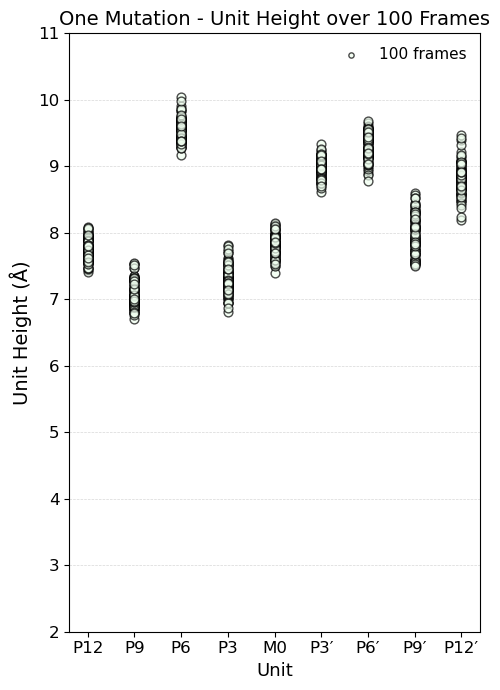

In [ ]:
# ---------- 0. 找出 105_CYS_1 的索引 ----------
mask = (
    (triplet_number_arr == 105) &          # triplet 105
    (mutation_name_arr.astype(str) == "CYS") &
    (alpha12_arr == 1)                     # α1
)
idx_list = np.where(mask)[0]
if idx_list.size == 0:
    raise ValueError("找不到 105_CYS_1 這筆資料")
idx = idx_list[0]                          # 取得唯一索引

# ---------- 1. 取出 Unit Height (100, 9) ----------
uh_block = unit_hei_all[idx]                # shape (100, 9)
uh_avg   = uh_block.mean(axis=0)         # (9,) 每位置平均
uh_std   = uh_block.std(axis=0)          # (9,) 每位置標準差

# ---------- 2. 畫圖 ----------
pos = np.arange(9) + 1
labels = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]

fig, ax = plt.subplots(figsize=(5, 7))

# 設定背景透明
fig.patch.set_alpha(0.0)   # 整個圖的背景透明
ax.patch.set_alpha(0.0)    # 座標區背景透明

# 2-1 100 個 frame 點
for frame in range(uh_block.shape[0]):
    if frame == 0:  # 只在第一個點加圖例 label
        ax.scatter(pos,
                   uh_block[frame],          
                   color='honeydew',
                   edgecolor='black',
                   s=40, alpha=0.7, zorder=2,
                   label='100 frames')
    else:
        ax.scatter(pos,
                   uh_block[frame],          
                   color='honeydew',
                   edgecolor='black',
                   s=40, alpha=0.7, zorder=2)

# 2-2 位置平均值（藍色星星）
# ax.scatter(pos, uh_avg,
#            marker='*', color='lightgreen',
#            edgecolor='black', s=300, zorder=4,
#            label='avg of frames')

# ax.scatter(pos, uh_std,
#            marker='*', color='gold',
#            edgecolor='black', s=300, zorder=2,
#            label='Std of frames')
#各個數據點與平均值之間的分散程度。 它反映了數據點的離散程度，標準差越大，數據的離散程度越大。
#這邊不是和放在同一張圖上，會看不出來(在下面)
# ---------- 3. 美化 ----------
ax.set_xticks(pos)
ax.set_xticklabels(labels, fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylabel("Unit Height (Å)", fontsize=14)
ax.set_xlabel("Unit", fontsize=13)
# ax.set_ylim(2, 12.4)
ax.set_ylim(2, 11)

mut_id = f"{triplet_number_arr[idx]}_{mutation_name_arr[idx]}_{alpha12_arr[idx]}"  # 105_CYS_1

ax.set_title(f"One Mutation - Unit Height over 100 Frames", fontsize=14)
ax.grid(axis='y', linestyle='--', lw=0.5, alpha=.5)
ax.legend(frameon=False, markerscale=0.6, fontsize=11)
plt.tight_layout()

# 顯示透明背景
plt.show()

# 如果要存成檔案（背景透明）
# plt.savefig("105_CYS_1_Unit Height.png", transparent=True, dpi=300)


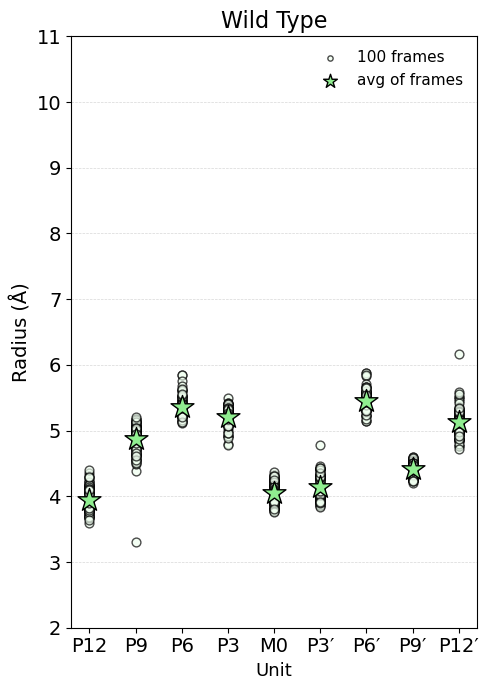

In [146]:
# ---------- 0. 找出 105_CYS_1 的索引 ----------
mask = (
    (triplet_number_arr == 105) &          # triplet 105
    (mutation_name_arr.astype(str) == "CYS") &
    (alpha12_arr == 1)                     # α1
)
idx_list = np.where(mask)[0]
if idx_list.size == 0:
    raise ValueError("找不到 105_CYS_1 這筆資料")
idx = idx_list[0]                          # 取得唯一索引

# ---------- 1. 取出 Radius (100, 9) ----------
rad_block = radius_wt[idx]                # shape (100, 9)
rad_avg   = rad_block.mean(axis=0)         # (9,) 每位置平均
rad_std   = rad_block.std(axis=0)          # (9,) 每位置標準差

# ---------- 2. 畫圖 ----------
pos = np.arange(9) + 1
labels = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]

fig, ax = plt.subplots(figsize=(5, 7))

# 設定背景透明
fig.patch.set_alpha(0.0)   # 整個圖的背景透明
ax.patch.set_alpha(0.0)    # 座標區背景透明

# 2-1 100 個 frame 點
for frame in range(rad_block.shape[0]):
    if frame == 0:  # 只在第一個點加圖例 label
        ax.scatter(pos,
                   rad_block[frame],          
                   color='honeydew',
                   edgecolor='black',
                   s=40, alpha=0.7, zorder=2,
                   label='100 frames')
    else:
        ax.scatter(pos,
                   rad_block[frame],          
                   color='honeydew',
                   edgecolor='black',
                   s=40, alpha=0.7, zorder=2)

# 2-2 位置平均值（藍色星星）
ax.scatter(pos, rad_avg,
           marker='*', color='lightgreen',
           edgecolor='black', s=300, zorder=4,
           label='avg of frames')

# ax.scatter(pos, uh_std,
#            marker='*', color='gold',
#            edgecolor='black', s=300, zorder=2,
#            label='Std of frames')
#各個數據點與平均值之間的分散程度。 它反映了數據點的離散程度，標準差越大，數據的離散程度越大。
#這邊不是和放在同一張圖上，會看不出來(在下面)
# ---------- 3. 美化 ----------
ax.set_xticks(pos)
ax.set_xticklabels(labels, fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_ylabel("Radius (Å)", fontsize=14)
ax.set_xlabel("Unit", fontsize=13)
# ax.set_ylim(2, 12.4)
ax.set_ylim(2, 11)

mut_id = f"{triplet_number_arr[idx]}_{mutation_name_arr[idx]}_{alpha12_arr[idx]}"  # 105_CYS_1
ax.set_title(f"Wild Type", fontsize=16)
# ax.set_title(f"WildType - Radius over 100 Frames", fontsize=14)
ax.grid(axis='y', linestyle='--', lw=0.5, alpha=.5)
ax.legend(frameon=False, markerscale=0.6, fontsize=11)
plt.tight_layout()

# 顯示透明背景
plt.show()

# 如果要存成檔案（背景透明）
# plt.savefig("105_CYS_1_Radius.png", transparent=True, dpi=300)


### 587合併

In [ ]:
import os
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

def plot_all_mutations_uh_overlay(
    unit_hei_all,                 # shape = (N, F, 9)
    out_path,                   # e.g. r"D:\collagen\figures\radius_overlay_all.png"
    ymin=2.0, ymax=12.4,
    dpi=300,
    pos_labels=("P4","P3","P2","P1","M0","P1′","P2′","P3′","P4′"),
    jitter=None,                # x 軸輕微抖動
    point_size=100,              # frame 點大小
    point_alpha=0.15,           # frame 點透明度
    mean_size=220,              # 平均值星號大小
    mean_alpha=0.8,             # 平均值透明度
    downsample=None             # 若指定整數，最多只畫這麼多個 frame 點
):
    """
    將所有突變的所有 frames 在一張圖疊加顯示（每個位置各一列散點雲），
    再把每個突變的 9 位置平均以星號標出。
    - unit_hei_all: (N, F, 9)，單位 Å
    - downsample: 最大繪製的 frame 點數（可選）
    """
    assert unit_hei_all.ndim == 3 and unit_hei_all.shape[2] == 9, "unit_hei_all 形狀需為 (N, F, 9)"
    N, F, P = unit_hei_all.shape
    pos = np.arange(P) + 1

    # 攤平成 (N*F, 9)
    all_frames = unit_hei_all.reshape(N * F, P)

    # 下採樣
    if (downsample is not None) and (all_frames.shape[0] > downsample):
        idx = np.random.choice(all_frames.shape[0], size=downsample, replace=False)
        all_frames_plot = all_frames[idx]
    else:
        all_frames_plot = all_frames

    # 每個突變的 9 位置平均
    means = unit_hei_all.mean(axis=1)

    # 開圖
    fig, ax = plt.subplots(figsize=(5, 7))
    # fig.patch.set_alpha(0.0)
    # ax.patch.set_alpha(0.0)

    # 畫所有 frame 點（圓圈半透明）
    first_label_done = False
    for i in range(P):
        x = np.full(all_frames_plot.shape[0], pos[i], dtype=float)
        if jitter and jitter > 0:
            x += np.random.uniform(-jitter, jitter, size=x.shape[0])

        ax.scatter(x, all_frames_plot[:, i],
                   s=point_size, alpha=0.4,
                   edgecolor='black',
                   facecolor='lightgreen',
                   marker='o',
                   label='100 frames' if not first_label_done else None,
                   zorder=1)
        first_label_done = True

    # 畫平均值星號（半透明）
    # for i in range(P):
    #     x_mean = np.full(N, pos[i], dtype=float)
    #     if jitter and jitter > 0:
    #         x_mean += np.random.uniform(-jitter, jitter, size=N)
    #     ax.scatter(x_mean, means[:, i],
    #                marker='*', s=300, alpha=0.4,
    #                edgecolor='black',
    #                facecolor='lightgreen',
    #                label='Mean of frames' if i == 0 else None,
    #                zorder=3)

    # 軸設定
    ax.set_xticks(pos)
    ax.set_xticklabels(pos_labels, fontsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_xlabel("Unit", fontsize=13)
    ax.set_ylabel("Unit Height (Å)", fontsize=14)
    ax.set_ylim(ymin, ymax)
    ax.grid(axis='y', linestyle='--', lw=0.5, alpha=.5)

    ax.set_title("All Mutations — Unit Height over 100 frames", fontsize=14)

    # 圖例
    ax.legend(frameon=False, fontsize=11, markerscale=0.9, loc='upper left')

    plt.tight_layout()
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, transparent=False, dpi=dpi)
    plt.close(fig)
    print(f"Saved overlay figure: {out_path}")
plot_all_mutations_uh_overlay(
    unit_hei_all,
    out_path=r"D:\collagen\figures\radius_overlay_all.png"
)

Saved overlay figure: D:\collagen\figures\radius_overlay_all.png


In [266]:
%matplotlib inline

#### 全突變-CYS變色

In [267]:
import os
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_all_mutations_radius_overlay(
    radius_all,                 # shape = (N, F, 9)
    mutation_name_arr,          # shape = (N,)
    alpha12_arr,                # shape = (N,) 1=α1, 2=α2
    target_mut="CYS",           # 指定突變名稱
    target_alpha=1,             # 指定 α 鏈 (1 or 2)
    out_path="radius_overlay.png",
    ymin=2.0, ymax=12.4,
    dpi=300,
    pos_labels=("P4","P3","P2","P1","M0","P1′","P2′","P3′","P4′"),
    point_size=100,
    point_alpha=0.2,
    mean_size=220,
    mean_alpha=0.8
):
    """
    疊加所有突變的 frames + 平均：
      - 指定的 (mutation name, α1/α2) → 橘色 (最後畫，置於最上層)
      - 其他樣本 → 綠色
    """
    assert radius_all.ndim == 3 and radius_all.shape[2] == 9, "radius_all 必須是 (N, F, 9)"
    N, F, P = radius_all.shape
    assert len(mutation_name_arr) == N
    assert len(alpha12_arr) == N

    pos = np.arange(P) + 1
    means = radius_all.mean(axis=1)  # (N, 9)

    fig, ax = plt.subplots(figsize=(5, 7))
    # fig.patch.set_alpha(0.0)
    # ax.patch.set_alpha(0.0)

    # ── 先畫其他樣本 (綠色) ──────────────────────────
    for i in range(N):
        if (str(mutation_name_arr[i]) == target_mut) and (alpha12_arr[i] == target_alpha):
            continue  # 跳過指定突變，等下再畫

        # frames
        ax.scatter(np.tile(pos, F),
                   radius_all[i].reshape(-1),
                   s=point_size, alpha=point_alpha,
                   edgecolor="black", facecolor="lightgreen",
                   marker="o", zorder=1)

        # mean
        # ax.scatter(pos, means[i],
        #            marker="*", s=mean_size, alpha=mean_alpha,
        #            edgecolor="black", facecolor="lightgreen",
        #            zorder=2)

    # ── 再畫指定突變 (橘色, 疊在最上層) ──────────────
    for i in range(N):
        if (str(mutation_name_arr[i]) == target_mut) and (alpha12_arr[i] == target_alpha):
            # frames
            ax.scatter(np.tile(pos, F),
                       radius_all[i].reshape(-1),
                       s=point_size, alpha=point_alpha,
                       edgecolor="black", facecolor="orange",
                       marker="o", zorder=3)

            # mean
            # ax.scatter(pos, means[i],
            #            marker="*", s=mean_size, alpha=mean_alpha,
            #            edgecolor="black", facecolor="orange",
            #            zorder=4)

    # 軸設定
    ax.set_xticks(pos)
    ax.set_xticklabels(pos_labels, fontsize=12)
    ax.tick_params(axis="y", labelsize=12)
    ax.set_xlabel("Unit", fontsize=13)
    ax.set_ylabel("Radius (Å)", fontsize=14)
    ax.set_ylim(ymin, ymax)
    ax.grid(axis="y", linestyle="--", lw=0.5, alpha=.5)

    ax.set_title("All Mutations — Highlight specific mutation", fontsize=14)

    # 圖例
    h_target = Line2D([], [], marker="*", linestyle="None",
                      markerfacecolor="orange", markeredgecolor="black",
                      markersize=12, label=f"{target_mut} (α{target_alpha})")
    h_other = Line2D([], [], marker="*", linestyle="None",
                     markerfacecolor="lightgreen", markeredgecolor="black",
                     markersize=12, label="Other mutations")
    ax.legend(handles=[h_target, h_other], frameon=False,
              fontsize=11, loc="upper right")

    plt.tight_layout()
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, transparent=False, dpi=dpi)
    plt.close(fig)
    print(f"Saved overlay figure: {out_path}")
plot_all_mutations_radius_overlay(
    radius_all=radius_all,
    mutation_name_arr=mutation_name_arr,
    alpha12_arr=alpha12_arr,
    target_mut="CYS",       # 指定突變
    target_alpha=1,         # 指定 α1
    out_path=r"D:\collagen\figures\radius_overlay_highlight.png"
)


Saved overlay figure: D:\collagen\figures\radius_overlay_highlight.png


#### 只顯示我分的突變

In [268]:
import os
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

def plot_selected_mutation(
    radius_all,                 
    mutation_name_arr,          
    alpha12_arr,                
    target_mut="CYS",           
    target_alpha=1,             
    out_path="selected_mutation.png",
    ymin=2.0, ymax=12.4,
    dpi=300,
    pos_labels=("P4","P3","P2","P1","M0","P1′","P2′","P3′","P4′"),
    point_size=100,
    point_alpha=0.2,
    mean_size=220,
    mean_alpha=0.8
):
    """
    只顯示指定的突變 (mutation name, α1/α2) 的 frames 與平均。
    """
    assert radius_all.ndim == 3 and radius_all.shape[2] == 9, "radius_all 必須是 (N, F, 9)"
    N, F, P = radius_all.shape
    assert len(mutation_name_arr) == N
    assert len(alpha12_arr) == N

    pos = np.arange(P) + 1
    means = radius_all.mean(axis=1)  # (N, 9)

    fig, ax = plt.subplots(figsize=(5, 7))
    # fig.patch.set_alpha(0.0)
    # ax.patch.set_alpha(0.0)

    found = False
    frame_label_done = False
    mean_label_done = False

    for i in range(N):
        if (str(mutation_name_arr[i]) == target_mut) and (alpha12_arr[i] == target_alpha):
            found = True
            # frames → 圓圈 (橘色)，只加一次 label
            ax.scatter(np.tile(pos, F),
                       radius_all[i].reshape(-1),
                       s=point_size, alpha=point_alpha,
                       edgecolor="black", facecolor="orange",
                       marker="o", zorder=1,
                       label="Frames" if not frame_label_done else None)
            frame_label_done = True

            # mean → 星號 (橘色)，只加一次 label
            # ax.scatter(pos, means[i],
            #            marker="*", s=mean_size, alpha=mean_alpha,
            #            edgecolor="black", facecolor="orange",
            #            zorder=2,
            #            label="Mean" if not mean_label_done else None)
            # mean_label_done = True

    if not found:
        print(f"⚠ 沒找到 {target_mut} (α{target_alpha}) 的突變")
        return

    # 軸設定
    ax.set_xticks(pos)
    ax.set_xticklabels(pos_labels, fontsize=12)
    ax.tick_params(axis="y", labelsize=12)
    ax.set_xlabel("Unit", fontsize=13)
    ax.set_ylabel("Radius (Å)", fontsize=14)
    ax.set_ylim(ymin, ymax)
    ax.grid(axis="y", linestyle="--", lw=0.5, alpha=.5)

    ax.set_title(f"Selected mutation – {target_mut} (α{target_alpha})", fontsize=14)

    ax.legend(frameon=False, fontsize=11, loc="upper right")

    plt.tight_layout()
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, transparent=False, dpi=dpi)
    plt.close(fig)
    print(f"Saved selected mutation figure: {out_path}")
plot_selected_mutation(
    radius_all=radius_all,
    mutation_name_arr=mutation_name_arr,
    alpha12_arr=alpha12_arr,
    target_mut="CYS",
    target_alpha=1,
    out_path=r"D:\collagen\figures\selected_mut_CYS_a1.png"
)


Saved selected mutation figure: D:\collagen\figures\selected_mut_CYS_a1.png


In [269]:
def plot_selected_mutation(
    radius_wt,
    mutation_name_arr,
    alpha12_arr,
    lethal_arr,                 # 0=Lethal, 1=Non-lethal
    target_mut="CYS",
    target_alpha=1,
    out_path="selected_mutation.png",
    ymin=2.0, ymax=12.4,
    dpi=300,
    pos_labels=("P4","P3","P2","P1","M0","P1′","P2′","P3′","P4′"),
    point_size=100,
    point_alpha=0.2,
    mean_size=220,
    mean_alpha=0.8
):
    assert radius_wt.ndim == 3 and radius_wt.shape[2] == 9, "radius_all 必須是 (N, F, 9)"
    N, F, P = radius_wt.shape
    assert len(mutation_name_arr) == N and len(alpha12_arr) == N and len(lethal_arr) == N

    pos   = np.arange(P) + 1
    means = radius_wt.mean(axis=1)  # (N, 9)

    fig, ax = plt.subplots(figsize=(5, 7))

    found = False
    for i in range(N):
        if (str(mutation_name_arr[i]) == target_mut) and (alpha12_arr[i] == target_alpha):
            found = True
            col = "firebrick" if lethal_arr[i] == 0 else "royalblue"

            # frames → 圓圈（無 label，避免重複）
            ax.scatter(np.tile(pos, F),
                       radius_wt[i].reshape(-1),
                       s=point_size, alpha=point_alpha,
                       edgecolor="black", facecolor=col,
                       marker="o", zorder=1)

            # # mean → 星號（無 label，避免重複）
            # ax.scatter(pos, means[i],
            #            marker="*", s=mean_size, alpha=mean_alpha,
            #            edgecolor="black", facecolor=col,
            #            zorder=2)

    if not found:
        print(f"⚠ 沒找到 {target_mut} (α{target_alpha}) 的突變")
        return

    # 軸設定
    ax.set_xticks(pos)
    ax.set_xticklabels(pos_labels, fontsize=12)
    ax.tick_params(axis="y", labelsize=12)
    ax.set_xlabel("Unit", fontsize=13)
    ax.set_ylabel("Radius (Å)", fontsize=14)
    ax.set_ylim(ymin, ymax)
    ax.grid(axis="y", linestyle="--", lw=0.5, alpha=.5)
    ax.set_title(f"Selected WildType – {target_mut} (α{target_alpha})", fontsize=14)

    # Legend：用 proxy handles，標示致死/非致死 × Frames/Mean
    h_L_frames = Line2D([], [], marker='o', linestyle='None',
                        markerfacecolor='firebrick', markeredgecolor='black',
                        markersize=8, label='Lethal Frames')
    # h_L_mean   = Line2D([], [], marker='*', linestyle='None',
    #                     markerfacecolor='firebrick', markeredgecolor='black',
    #                     markersize=12, label='Lethal Mean')
    h_N_frames = Line2D([], [], marker='o', linestyle='None',
                        markerfacecolor='royalblue', markeredgecolor='black',
                        markersize=8, label='Non-lethal Frames')
    # h_N_mean   = Line2D([], [], marker='*', linestyle='None',
    #                     markerfacecolor='royalblue', markeredgecolor='black',
    #                     markersize=12, label='Non-lethal Mean')

    ax.legend(handles=[h_L_frames, h_N_frames],
              frameon=False, fontsize=10, ncol=2, loc="upper right")

    plt.tight_layout()
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, transparent=False, dpi=dpi)
    plt.close(fig)
    print(f"Saved selected mutation figure: {out_path}")

plot_selected_mutation(
    radius_wt=radius_wt,
    mutation_name_arr=mutation_name_arr,
    alpha12_arr=alpha12_arr,
    lethal_arr=lethal_arr,               # 0=致死, 1=非致死
    target_mut="CYS",
    target_alpha=1,
    out_path=r"D:\collagen\figures\selected_wt_LN_CYS_a1.png"
)



Saved selected mutation figure: D:\collagen\figures\selected_wt_LN_CYS_a1.png


✔ CYS (α1, Lethal) 共畫出 18000 個點


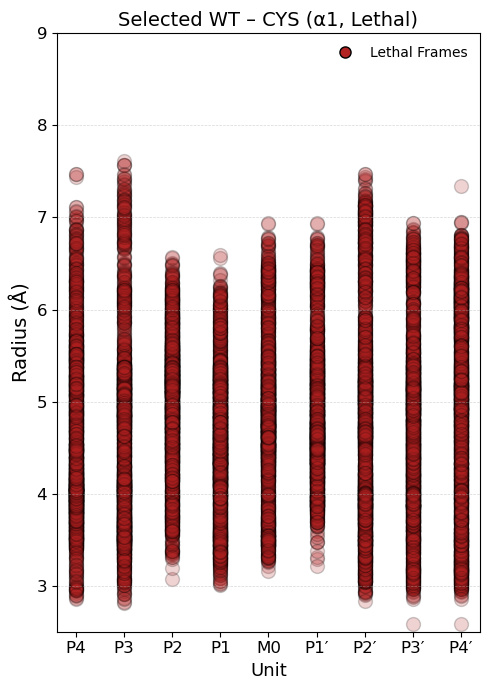

✔ CYS (α1, Non-lethal) 共畫出 27900 個點


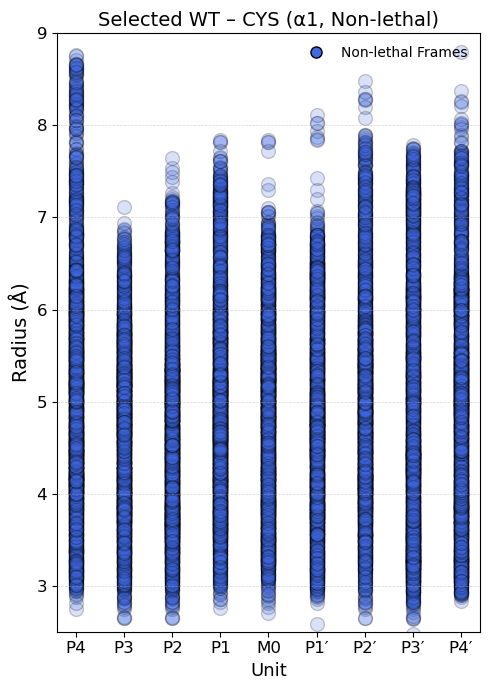

In [50]:
def plot_selected_mutation_split(
    radius_wt,
    mutation_name_arr,
    alpha12_arr,
    lethal_arr,
    target_mut="CYS",
    target_alpha=1,
    ymin=2.5, ymax=9,
    pos_labels=("P4","P3","P2","P1","M0","P1′","P2′","P3′","P4′"),
    point_size=100,
    point_alpha=0.2
):
    assert radius_wt.ndim == 3 and radius_wt.shape[2] == 9, "radius_wt 必須是 (N, F, 9)"
    N, F, P = radius_wt.shape
    pos   = np.arange(P) + 1

    for label_val, label_name, col in [(0, "Lethal", "firebrick"),
                                       (1, "Non-lethal", "royalblue")]:
        fig, ax = plt.subplots(figsize=(5, 7))
        found = False
        count_points = 0  # 計數器

        for i in range(N):
            if (str(mutation_name_arr[i]) == target_mut) and (alpha12_arr[i] == target_alpha) and (lethal_arr[i] == label_val):
                found = True
                # 計算這筆要畫幾個點
                count_points += F * P
                ax.scatter(np.tile(pos, F),
                           radius_wt[i].reshape(-1),
                           s=point_size, alpha=point_alpha,
                           edgecolor="black", facecolor=col,
                           marker="o", zorder=1)

        if not found:
            print(f"⚠ 沒找到 {target_mut} (α{target_alpha}, {label_name}) 的突變")
        else:
            print(f"✔ {target_mut} (α{target_alpha}, {label_name}) 共畫出 {count_points} 個點")

            ax.set_xticks(pos)
            ax.set_xticklabels(pos_labels, fontsize=12)
            ax.tick_params(axis="y", labelsize=12)
            ax.set_xlabel("Unit", fontsize=13)
            ax.set_ylabel("Radius (Å)", fontsize=14)
            ax.set_ylim(ymin, ymax)
            ax.grid(axis="y", linestyle="--", lw=0.5, alpha=.5)
            ax.set_title(f"Selected WT – {target_mut} (α{target_alpha}, {label_name})", fontsize=14)

            h_frames = Line2D([], [], marker='o', linestyle='None',
                              markerfacecolor=col, markeredgecolor='black',
                              markersize=8, label=f'{label_name} Frames')
            ax.legend(handles=[h_frames], frameon=False, fontsize=10, loc="upper right")

            plt.tight_layout()
            plt.show()
            
plot_selected_mutation_split(
    radius_wt=radius_wt,
    mutation_name_arr=mutation_name_arr,
    alpha12_arr=alpha12_arr,
    lethal_arr=lethal_arr,
    target_mut="CYS",
    target_alpha=1
)


✔ CYS (α1, Lethal) 共畫出 18000 個點


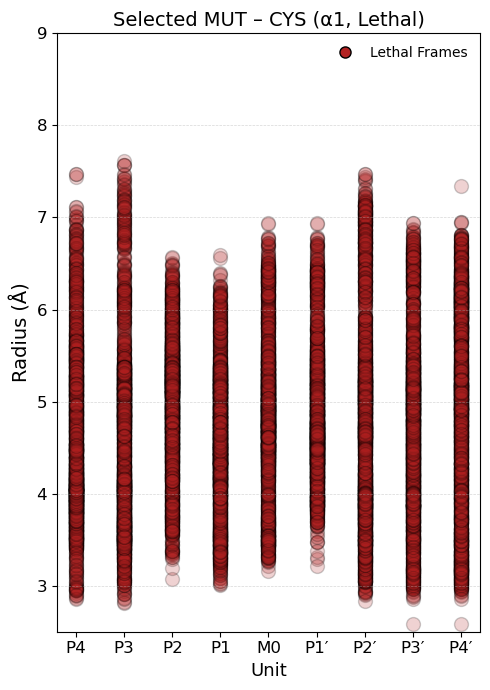

✔ CYS (α1, Non-lethal) 共畫出 27900 個點


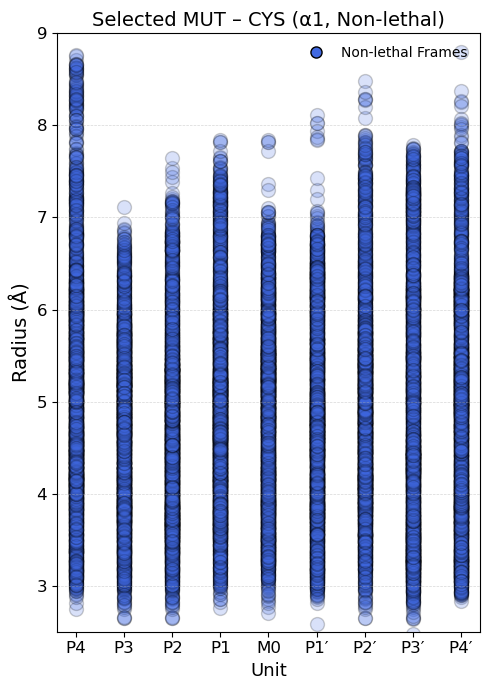

In [52]:
def plot_selected_mutation_split(
    radius_all,
    mutation_name_arr,
    alpha12_arr,
    lethal_arr,
    target_mut="CYS",
    target_alpha=1,
    ymin=2.5, ymax=9,
    pos_labels=("P4","P3","P2","P1","M0","P1′","P2′","P3′","P4′"),
    point_size=100,
    point_alpha=0.2
):
    assert radius_all.ndim == 3 and radius_all.shape[2] == 9, "radius_all 必須是 (N, F, 9)"
    N, F, P = radius_all.shape
    pos   = np.arange(P) + 1

    for label_val, label_name, col in [(0, "Lethal", "firebrick"),
                                       (1, "Non-lethal", "royalblue")]:
        fig, ax = plt.subplots(figsize=(5, 7))
        found = False
        count_points = 0  # 計數器

        for i in range(N):
            if (str(mutation_name_arr[i]) == target_mut) and (alpha12_arr[i] == target_alpha) and (lethal_arr[i] == label_val):
                found = True
                # 計算這筆要畫幾個點
                count_points += F * P
                ax.scatter(np.tile(pos, F),
                           radius_wt[i].reshape(-1),
                           s=point_size, alpha=point_alpha,
                           edgecolor="black", facecolor=col,
                           marker="o", zorder=1)

        if not found:
            print(f"⚠ 沒找到 {target_mut} (α{target_alpha}, {label_name}) 的突變")
        else:
            print(f"✔ {target_mut} (α{target_alpha}, {label_name}) 共畫出 {count_points} 個點")

            ax.set_xticks(pos)
            ax.set_xticklabels(pos_labels, fontsize=12)
            ax.tick_params(axis="y", labelsize=12)
            ax.set_xlabel("Unit", fontsize=13)
            ax.set_ylabel("Radius (Å)", fontsize=14)
            ax.set_ylim(ymin, ymax)
            ax.grid(axis="y", linestyle="--", lw=0.5, alpha=.5)
            ax.set_title(f"Selected MUT – {target_mut} (α{target_alpha}, {label_name})", fontsize=14)

            h_frames = Line2D([], [], marker='o', linestyle='None',
                              markerfacecolor=col, markeredgecolor='black',
                              markersize=8, label=f'{label_name} Frames')
            ax.legend(handles=[h_frames], frameon=False, fontsize=10, loc="upper right")

            plt.tight_layout()
            plt.show()
            
plot_selected_mutation_split(
    radius_all=radius_all,
    mutation_name_arr=mutation_name_arr,
    alpha12_arr=alpha12_arr,
    lethal_arr=lethal_arr,
    target_mut="CYS",
    target_alpha=1
)


### 全資料分布圖

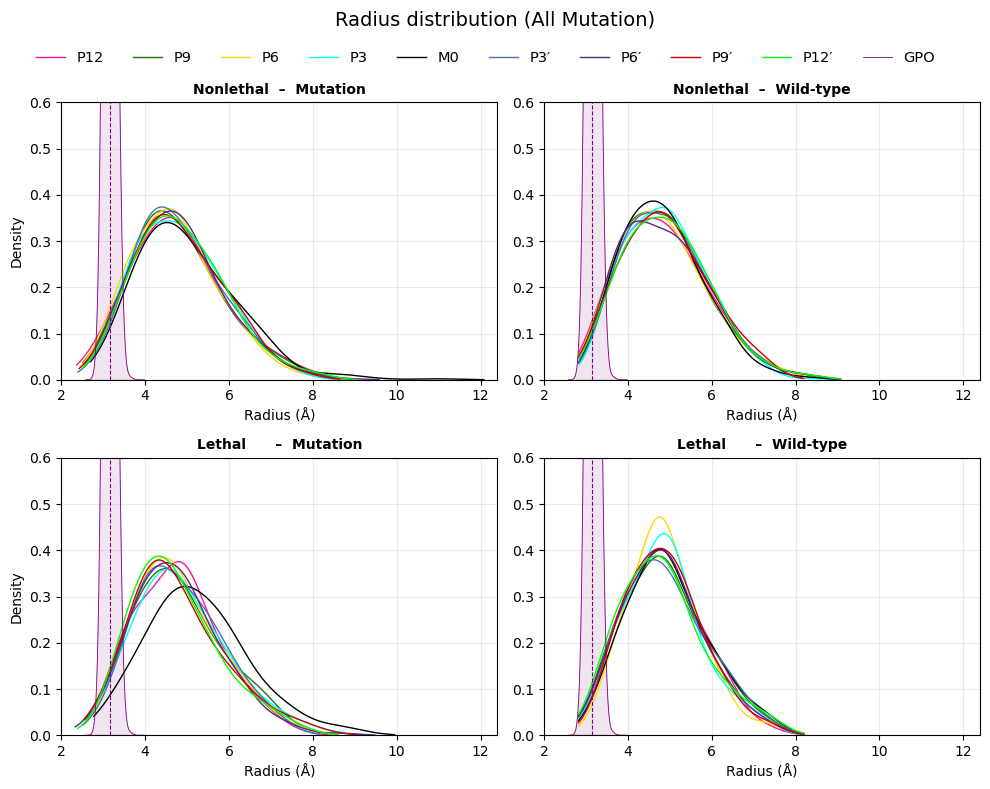

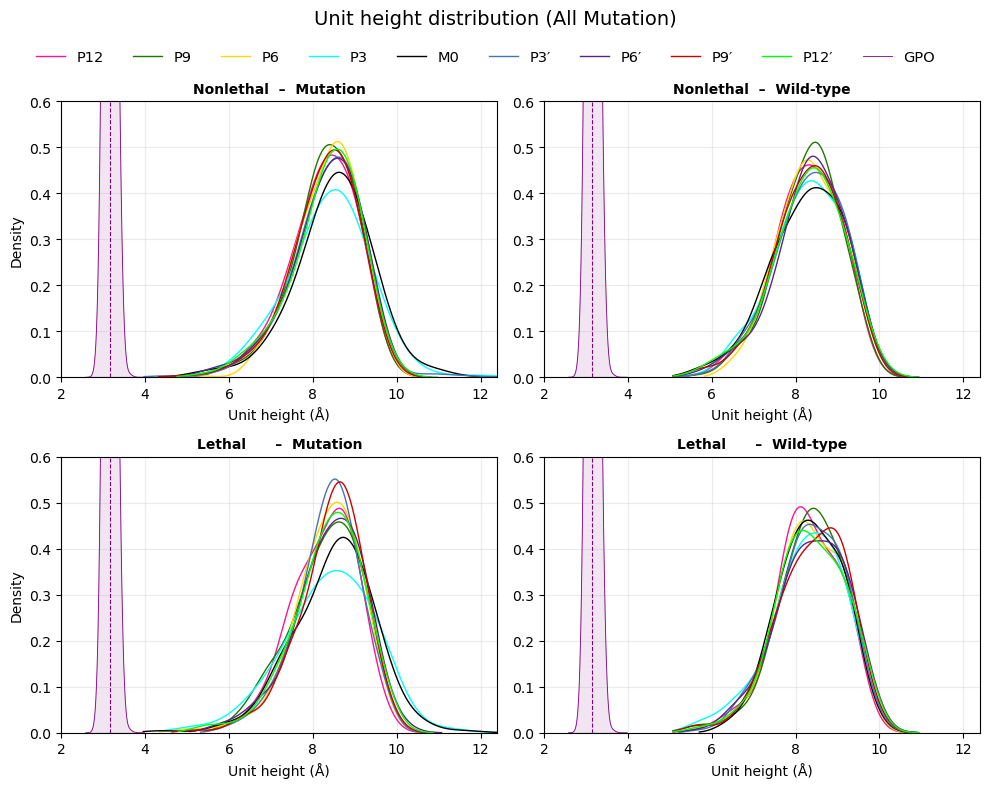

In [135]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ─── 共用設定 ────────────────────────────────────────────────
POS = ["P12","P9","P6","P3","M0","P3′","P6′","P9′","P12′"]
COL = ["#ff1493","#227700","#ffd700","#00ffff",
       "#000000","#4575b4","#542788","#cc0000","#00ff00"]

# GPO 參考曲線（triplet 2–9）
comb      = gpo_radius_traj[:,1:].ravel()
xs_gpo    = np.linspace(comb.min()*0.9, comb.max()*1.1, 300)
ys_gpo    = gaussian_kde(comb, bw_method=0.7)(xs_gpo)
peak_gpo  = xs_gpo[np.argmax(ys_gpo)]

def _ax_kde(ax, samples, subtitle, xlabel,
            xlim=(2,12.4), ylim=(0,0.6)):
    """單一子圖：9 條 KDE + GPO"""
    if samples.shape[0] == 0:
        ax.set_visible(False); return

    for i, lab in enumerate(POS):
        kde = gaussian_kde(samples[:, i], bw_method=0.45)
        xs  = np.linspace(samples[:, i].min()*0.9,
                          samples[:, i].max()*1.1, 300)
        ax.plot(xs, kde(xs), color=COL[i], lw=1, label=lab)

    ax.plot(xs_gpo, ys_gpo, color="purple", lw=.6, label="GPO")
    ax.fill_between(xs_gpo, ys_gpo, color="purple", alpha=.1)
    ax.axvline(peak_gpo, color="purple", ls="--", lw=.8)

    ax.set_title(subtitle, fontweight="bold", fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.grid(alpha=.25)

def plot_kde_mut_vs_wt(mut_avg, wt_avg, lethal_arr,
                       metric="Radius", unit="Å"):
    """四宮格：列＝致死性，行＝Mut / WT"""
    nl = lethal_arr == 1     # Non-lethal mask
    le = lethal_arr == 0     #   Lethal mask

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    (ax_mut_nl, ax_wt_nl), (ax_mut_le, ax_wt_le) = axes

    _ax_kde(ax_mut_nl, mut_avg[nl], "Nonlethal  –  Mutation",
            f"{metric} ({unit})")
    _ax_kde(ax_wt_nl , wt_avg [nl], "Nonlethal  –  Wild-type",
            f"{metric} ({unit})")
    _ax_kde(ax_mut_le, mut_avg[le], "Lethal      –  Mutation",
            f"{metric} ({unit})")
    _ax_kde(ax_wt_le , wt_avg [le], "Lethal      –  Wild-type",
            f"{metric} ({unit})")

    # y-label 置左列
    ax_mut_nl.set_ylabel("Density")
    ax_mut_le.set_ylabel("Density")

    # 共用圖例（取左上軸）
    h,l = ax_mut_nl.get_legend_handles_labels()
    fig.legend(h, l, ncol=10, loc=(0.03, 0.91),
               frameon=False, fontsize=10.5)

    fig.suptitle(f"{metric} distribution (All Mutation)",
                 fontsize=14)
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# ─── 呼叫：Radius ───────────────────────────────────────────
plot_kde_mut_vs_wt(radius_avg,       # 突變  (587,9)
                   radius_wt_avg,    # 野生型 (587,9)
                   lethal_arr,
                   metric="Radius")

# ─── 若要再畫 Unit height，只要換資料再呼叫一次 ───────────────
plot_kde_mut_vs_wt(unit_hei_avg,     # 突變
                   unit_wt_avg,      # 野生型
                   lethal_arr,
                   metric="Unit height")
